In [1]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
#datos de ingreso
dia_ivd = '20260401'
dia_fvd = '20260409'

In [3]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = 'Z:/01 base_datos/41 Informe Diario CCZ/Blogger/Datos diarios  dia vencido/Perdidos'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):

    if nombre_archivo.endswith('_bitacora perdidos.csv'):

        # Extraer la fecha del nombre del archivo (YYYYMMDD)
        fecha_archivo = nombre_archivo[:8]

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:

            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)

            # Leer el archivo
            df = pd.read_csv(ruta_archivo, encoding='latin')

            # Eliminar filas completamente vacías
            df = df.dropna(how='all')

            # Crear la columna Fecha a partir del nombre del archivo
            df['Fecha'] = pd.to_datetime(fecha_archivo, format='%Y%m%d')

            # Agregar a la lista
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    perdidos = pd.concat(dataframes, ignore_index=True)
else:
    print("No se encontraron archivos para consolidar.")

# Verificar resultado
perdidos.head()

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS PLANIFICADOS,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha
0,2026-04-01,BC29D0010,SE14,ORLANDO SUAREZ OBANDO,506196.0,7.967073e+07,06:34:00,09:22:00,Gestion de Mtto,Varado en Vía,...,"36,909","6,763","30,146",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 07:39:23,NO,Z50-7023,PATIO TINTAL 2,2026-04-01
1,2026-04-01,BC29D0010,SE14,JEINER DEL CARMEN GARCES PAEZ,508131.0,1.082995e+09,12:06:30,14:50:30,Gestion de Mtto,Falla Sirci en vía,...,"36,909","12,770","24,139",2.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 13:02:53,NO,Z50-7041,PATIO TINTAL 2,2026-04-01
2,2026-04-01,BC29D0024,SE14,JOSE OLIMPO GIRALDO VELEZ,502572.0,1.598864e+07,07:45:00,10:29:00,Gestion de Mtto,Varado en Vía,...,"36,909","5,233","31,676",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 08:26:26,NO,Z50-7119,PATIO TINTAL 2,2026-04-01
3,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,12:07:30,14:49:30,Gestion del Operador,Operador no se presenta,...,"36,341",0,"36,341",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01
4,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,14:52:30,17:42:30,Gestion del Operador,Operador no se presenta,...,"36,909",0,"36,909",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01


In [4]:
# Horas extendidas (24–27, '1 day, 0:27:57', etc.) ----
_pat = re.compile(r'^(?:(\d+)\s*day[s]?,\s*)?(\d{1,3}):([0-5]?\d)(?::([0-5]?\d))?$')

def parse_hms_extended(s):
    """
    Acepta: '23:45:10' | '25:03:00' | '1 day, 0:27:57' | '2 days, 01:02:03'
    Devuelve (horas_ext, minutos, segundos) como enteros, o (np.nan, np.nan, np.nan) si no se puede.
    """
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return (np.nan, np.nan, np.nan)
    s = str(s).strip()
    m = _pat.match(s)
    if not m:
        return (np.nan, np.nan, np.nan)
    days = int(m.group(1)) if m.group(1) is not None else 0
    hh   = int(m.group(2))
    mm   = int(m.group(3))
    ss   = int(m.group(4)) if m.group(4) is not None else 0
    horas_ext = hh + 24 * days
    return (horas_ext, mm, ss)

def hora_a_minutos_ext(s):
    h, m, sec = parse_hms_extended(s)
    if pd.isna(h):
        return np.nan
    return round(h*60 + m + sec/60.0, 2)

def hora_a_franja_ext(s):
    h, _, _ = parse_hms_extended(s)
    return h 


perdidos.head()

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS PLANIFICADOS,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha
0,2026-04-01,BC29D0010,SE14,ORLANDO SUAREZ OBANDO,506196.0,7.967073e+07,06:34:00,09:22:00,Gestion de Mtto,Varado en Vía,...,"36,909","6,763","30,146",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 07:39:23,NO,Z50-7023,PATIO TINTAL 2,2026-04-01
1,2026-04-01,BC29D0010,SE14,JEINER DEL CARMEN GARCES PAEZ,508131.0,1.082995e+09,12:06:30,14:50:30,Gestion de Mtto,Falla Sirci en vía,...,"36,909","12,770","24,139",2.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 13:02:53,NO,Z50-7041,PATIO TINTAL 2,2026-04-01
2,2026-04-01,BC29D0024,SE14,JOSE OLIMPO GIRALDO VELEZ,502572.0,1.598864e+07,07:45:00,10:29:00,Gestion de Mtto,Varado en Vía,...,"36,909","5,233","31,676",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 08:26:26,NO,Z50-7119,PATIO TINTAL 2,2026-04-01
3,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,12:07:30,14:49:30,Gestion del Operador,Operador no se presenta,...,"36,341",0,"36,341",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01
4,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,14:52:30,17:42:30,Gestion del Operador,Operador no se presenta,...,"36,909",0,"36,909",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01


In [5]:
# Creación Clumna Franja con 24, 25, 26, 27 a partir de HoraTeorica
if "HORA INICIO" in perdidos.columns:
    perdidos["Franja"] = perdidos["HORA INICIO"].apply(hora_a_franja_ext)
    
perdidos.head()

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha,Franja
0,2026-04-01,BC29D0010,SE14,ORLANDO SUAREZ OBANDO,506196.0,7.967073e+07,06:34:00,09:22:00,Gestion de Mtto,Varado en Vía,...,"6,763","30,146",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 07:39:23,NO,Z50-7023,PATIO TINTAL 2,2026-04-01,6
1,2026-04-01,BC29D0010,SE14,JEINER DEL CARMEN GARCES PAEZ,508131.0,1.082995e+09,12:06:30,14:50:30,Gestion de Mtto,Falla Sirci en vía,...,"12,770","24,139",2.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 13:02:53,NO,Z50-7041,PATIO TINTAL 2,2026-04-01,12
2,2026-04-01,BC29D0024,SE14,JOSE OLIMPO GIRALDO VELEZ,502572.0,1.598864e+07,07:45:00,10:29:00,Gestion de Mtto,Varado en Vía,...,"5,233","31,676",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 08:26:26,NO,Z50-7119,PATIO TINTAL 2,2026-04-01,7
3,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,12:07:30,14:49:30,Gestion del Operador,Operador no se presenta,...,0,"36,341",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01,12
4,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,14:52:30,17:42:30,Gestion del Operador,Operador no se presenta,...,0,"36,909",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01,14


In [6]:
# Eliminar filas donde 'Franja' está vacía o nula
perdidos = perdidos[perdidos['Franja'].notna() & (perdidos['Franja'].astype(str).str.strip() != '')]

# Convertir a entero
perdidos['Franja'] = perdidos['Franja'].astype(int)

perdidos.head()

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha,Franja
0,2026-04-01,BC29D0010,SE14,ORLANDO SUAREZ OBANDO,506196.0,7.967073e+07,06:34:00,09:22:00,Gestion de Mtto,Varado en Vía,...,"6,763","30,146",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 07:39:23,NO,Z50-7023,PATIO TINTAL 2,2026-04-01,6
1,2026-04-01,BC29D0010,SE14,JEINER DEL CARMEN GARCES PAEZ,508131.0,1.082995e+09,12:06:30,14:50:30,Gestion de Mtto,Falla Sirci en vía,...,"12,770","24,139",2.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 13:02:53,NO,Z50-7041,PATIO TINTAL 2,2026-04-01,12
2,2026-04-01,BC29D0024,SE14,JOSE OLIMPO GIRALDO VELEZ,502572.0,1.598864e+07,07:45:00,10:29:00,Gestion de Mtto,Varado en Vía,...,"5,233","31,676",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 08:26:26,NO,Z50-7119,PATIO TINTAL 2,2026-04-01,7
3,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,12:07:30,14:49:30,Gestion del Operador,Operador no se presenta,...,0,"36,341",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01,12
4,2026-04-01,BC29D0035,SE14,GREGORIO HERNANDEZ BELTRAN,503915.0,8.012810e+07,14:52:30,17:42:30,Gestion del Operador,Operador no se presenta,...,0,"36,909",1.0,ADRIANA PATRICIA TELLEZ VARELA,2026-04-01 12:13:46,NO,Z50-7102,PATIO TINTAL 2,2026-04-01,14


In [7]:
villa_4dias = perdidos[
    (perdidos["RUTA"] == "16-5")
]

villa_4dias.head(3)

,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha,Franja
86,2026-04-01,CE1AA0005,16-5,ALFONSO LIZARAZO BURGOS,507825.0,8.009728e+07,04:17:00,05:09:00,Gestion de Mtto,Falla Sirci en vía,...,0,"16,942",1.0,LAURA MARCELA VARGAS GUTIERREZ,2026-04-01 04:38:49,NO,Z50-7105,PATIO TINTAL 2,2026-04-01,4
87,2026-04-01,CE1AA0010,16-5,JOHAN DANILO AGUILAR LOPEZ,508565.0,1.026580e+09,12:47:15,14:03:15,Gestion del Operador,Operador no se presenta,...,0,"16,942",2.0,SONIA CONSTANZA CORREA RODRIGUEZ,2026-04-01 12:56:12,NO,Z50-7079,PATIO TINTAL 2,2026-04-01,12
187,2026-04-05,CE0D80001,16-5,CARLOS SAJONA ALMARIO,507912.0,1.027956e+09,06:38:00,07:33:30,Gestion del Operador,Operador no se presenta,...,0,"16,942",1.0,PAULA KATHERINE CANTOR SALAMANCA,2026-04-05 06:49:20,NO,Z50-7001,PATIO TINTAL 2,2026-04-05,6


In [8]:
villa_4dias["Franja"] = (
    villa_4dias["HORA INICIO"]
    .astype(str)              # asegurar que sea texto
    .str.split(":")           # dividir por :
    .str[0]                   # tomar la parte antes de :
    .str.zfill(2)             # asegurar 2 dígitos
)

villa_4dias.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_10856\175733074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  villa_4dias["Franja"] = (


,FECHA,SERVICIO VEHICULO,RUTA,OPERADOR,CODIGO,CEDULA,HORA INICIO,HORA FINAL,MOTIVO,CAUSA,...,KMS REALIZADOS,KMS PERDIDOS,PARTE DE TRABAJO,USUARIO REGISTRO,FECHA REGISTRO,REPORTADO A TRANSMILENIO,VEHICULO,PATIO,Fecha,Franja
86,2026-04-01,CE1AA0005,16-5,ALFONSO LIZARAZO BURGOS,507825.0,8.009728e+07,04:17:00,05:09:00,Gestion de Mtto,Falla Sirci en vía,...,0,"16,942",1.0,LAURA MARCELA VARGAS GUTIERREZ,2026-04-01 04:38:49,NO,Z50-7105,PATIO TINTAL 2,2026-04-01,04
87,2026-04-01,CE1AA0010,16-5,JOHAN DANILO AGUILAR LOPEZ,508565.0,1.026580e+09,12:47:15,14:03:15,Gestion del Operador,Operador no se presenta,...,0,"16,942",2.0,SONIA CONSTANZA CORREA RODRIGUEZ,2026-04-01 12:56:12,NO,Z50-7079,PATIO TINTAL 2,2026-04-01,12
187,2026-04-05,CE0D80001,16-5,CARLOS SAJONA ALMARIO,507912.0,1.027956e+09,06:38:00,07:33:30,Gestion del Operador,Operador no se presenta,...,0,"16,942",1.0,PAULA KATHERINE CANTOR SALAMANCA,2026-04-05 06:49:20,NO,Z50-7001,PATIO TINTAL 2,2026-04-05,06
188,2026-04-05,CE0D80006,16-5,MICHAEL STEVEN MACIAS ARIAS,507881.0,1.012447e+09,08:20:45,09:20:45,Gestion de Mtto,Varado en Vía,...,"8,057","8,885",1.0,PAULA KATHERINE CANTOR SALAMANCA,2026-04-05 09:01:35,NO,Z50-7067,PATIO TINTAL 2,2026-04-05,08
263,2026-04-06,CE0D60003,16-5,ANGELA JULIETH SALAZAR TAPIERO,509210.0,1.000729e+09,16:25:45,18:01:45,Gestion de Mtto,Movil no despachado,...,0,"16,942",1.0,SONIA CONSTANZA CORREA RODRIGUEZ,2026-04-06 16:37:56,NO,Z50-7009,PATIO TINTAL 2,2026-04-06,16


In [9]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = 'Z:/01 base_datos/41 Informe Diario CCZ/Blogger/Datos diarios  dia vencido/Bitacora/consolidado'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):

    if nombre_archivo.endswith('_consolidado.csv'):

        # Extraer la fecha del nombre del archivo (YYYYMMDD)
        fecha_archivo = nombre_archivo[:8]

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:

            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)

            # Leer el archivo
            df = pd.read_csv(ruta_archivo, encoding='latin', skiprows=1)

            # Eliminar filas completamente vacías
            df = df.dropna(how='all')

            # Crear la columna Fecha a partir del nombre del archivo
            df['Fecha'] = pd.to_datetime(fecha_archivo, format='%Y%m%d')

            # Agregar a la lista
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    bitacora = pd.concat(dataframes, ignore_index=True)
else:
    print("No se encontraron archivos para consolidar.")

# Verificar resultado
bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260401_la Y.csv,Fecha,20260402_la Y.csv,20260403_la Y.csv,20260404_la Y.csv,20260405_la Y.csv,20260406_la Y.csv,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv
0,509372,NELSON ROBERTO PELAEZ NIÃO,CE0CC0001,04:00:00,04:36:00,451A04_TM_UNIR_(ENGATIVA),493A05_TM_UNIR,DD204,DD204_HA_FMS,10.904,...,20260401_la Y.csv,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,508729,DANIEL ESTEBAN TORRES VALBUENA,CE1A60001,04:00:00,06:58:00,942V07_TM_Br. El Recodo,942V07_TM_Br. El Recodo,KL307,KL307_HA_FMS,51.064,...,20260401_la Y.csv,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,500855,LOZANO RUSINQUE HECTOR AUGUSTO,CE0C80001,04:00:00,05:32:00,377C05_TM_(Aeropuerto),377C05_TM_(Aeropuerto),P500,P500_HA_FMS,33.163,...,20260401_la Y.csv,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,510107,ALEJANDRO MUÃOZ MONROY,CE0C30001,04:00:00,08:18:30,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,KB309,KB309_HA_FMS,74.740,...,20260401_la Y.csv,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,509293,ROBERT MENDOZA PETE,CE19F0001,04:00:00,06:00:00,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,12,12_HA_FMS,42.906,...,20260401_la Y.csv,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
bitacora["estado_op"] = (
    bitacora["Conductor"]
    .str.contains("NO ASIGNADO", case=False, na=False)
    .astype(int)
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,Fecha,20260402_la Y.csv,20260403_la Y.csv,20260404_la Y.csv,20260405_la Y.csv,20260406_la Y.csv,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv,estado_op
0,509372,NELSON ROBERTO PELAEZ NIÃO,CE0CC0001,04:00:00,04:36:00,451A04_TM_UNIR_(ENGATIVA),493A05_TM_UNIR,DD204,DD204_HA_FMS,10.904,...,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,508729,DANIEL ESTEBAN TORRES VALBUENA,CE1A60001,04:00:00,06:58:00,942V07_TM_Br. El Recodo,942V07_TM_Br. El Recodo,KL307,KL307_HA_FMS,51.064,...,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,500855,LOZANO RUSINQUE HECTOR AUGUSTO,CE0C80001,04:00:00,05:32:00,377C05_TM_(Aeropuerto),377C05_TM_(Aeropuerto),P500,P500_HA_FMS,33.163,...,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,510107,ALEJANDRO MUÃOZ MONROY,CE0C30001,04:00:00,08:18:30,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,KB309,KB309_HA_FMS,74.740,...,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,509293,ROBERT MENDOZA PETE,CE19F0001,04:00:00,06:00:00,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,12,12_HA_FMS,42.906,...,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [11]:
# Función para separar el texto y los códigos
def separar_novedad(texto):
    if pd.isna(texto):
        return pd.Series([None, None, None])

    # Limpiar espacios
    texto = texto.strip()

    # Buscar todos los números en la cadena
    numeros = re.findall(r'\d+', texto)

    # Extraer el texto antes del primer número (estado_novedad)
    estado = re.split(r'\d+', texto, maxsplit=1)[0].strip()

    # Retornar con estructura: [estado, operador_cambio, operador_faltante]
    operador_cambio = numeros[0] if len(numeros) > 0 else None
    operador_faltante = numeros[1] if len(numeros) > 1 else None

    return pd.Series([estado, operador_cambio, operador_faltante])

# Aplicar función
bitacora[['estado_novedad', 'operador_cambio', 'operador_faltante']] = bitacora['CÃ³digo conductor'].apply(separar_novedad)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260404_la Y.csv,20260405_la Y.csv,20260406_la Y.csv,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante
0,509372,NELSON ROBERTO PELAEZ NIÃO,CE0CC0001,04:00:00,04:36:00,451A04_TM_UNIR_(ENGATIVA),493A05_TM_UNIR,DD204,DD204_HA_FMS,10.904,...,NaN,NaN,NaN,NaN,NaN,NaN,0,,509372,None
1,508729,DANIEL ESTEBAN TORRES VALBUENA,CE1A60001,04:00:00,06:58:00,942V07_TM_Br. El Recodo,942V07_TM_Br. El Recodo,KL307,KL307_HA_FMS,51.064,...,NaN,NaN,NaN,NaN,NaN,NaN,0,,508729,None
2,500855,LOZANO RUSINQUE HECTOR AUGUSTO,CE0C80001,04:00:00,05:32:00,377C05_TM_(Aeropuerto),377C05_TM_(Aeropuerto),P500,P500_HA_FMS,33.163,...,NaN,NaN,NaN,NaN,NaN,NaN,0,,500855,None
3,510107,ALEJANDRO MUÃOZ MONROY,CE0C30001,04:00:00,08:18:30,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,KB309,KB309_HA_FMS,74.740,...,NaN,NaN,NaN,NaN,NaN,NaN,0,,510107,None
4,509293,ROBERT MENDOZA PETE,CE19F0001,04:00:00,06:00:00,966V06_TM_Urb.Fuengirola,966V06_TM_Urb.Fuengirola,12,12_HA_FMS,42.906,...,NaN,NaN,NaN,NaN,NaN,NaN,0,,509293,None


In [12]:
# Ordenar los datos como corresponde
bitacora = bitacora.sort_values(
    by=['Conductor', 'Servicio', 'Hora Inicio', 'Ruta'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# Crear la columna 'parte' numerando consecutivamente
# cada grupo de (Conductor, Servicio)
bitacora['parte'] = (
    bitacora.groupby(['Conductor', 'Servicio'])
    .cumcount() + 1
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260405_la Y.csv,20260406_la Y.csv,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante,parte
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,NaN,NaN,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,1
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,NaN,NaN,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,2
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,NaN,NaN,NaN,NaN,NaN,0,,507680,None,1
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,NaN,NaN,NaN,NaN,NaN,0,,507680,None,2
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,NaN,NaN,NaN,NaN,NaN,0,,507680,None,1


In [13]:
perdidos["FECHA"] = pd.to_datetime(perdidos["FECHA"])

In [14]:
perdidos["FECHA"].dtype
bitacora["Fecha"].dtype

dtype('<M8[ns]')

In [15]:
# Llevar servicio original de retomas a la actividad de bus

def calcular_posicion(servbus, hora, fecha):
    
    filtro = (
        (perdidos['SERVICIO VEHICULO'] == servbus)&
        (perdidos['HORA INICIO'] == hora)&
        (perdidos['FECHA'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not perdidos.loc[filtro].empty:
        # Obtener el primer valor
        tipo = perdidos.loc[filtro, 'MOTIVO'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
bitacora['Motivo_perdida'] = bitacora.apply(
    lambda row: calcular_posicion(
        row['Servicio'],
        row['Hora Inicio'],
        row['Fecha']
    ),
    axis=1
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260406_la Y.csv,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,NaN,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,1,None
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,NaN,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,2,None
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,NaN,NaN,NaN,NaN,0,,507680,None,1,Gestion del Operador
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,NaN,NaN,NaN,NaN,0,,507680,None,2,Gestion del Operador
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,NaN,NaN,NaN,NaN,0,,507680,None,1,None


In [16]:
# Llevar servicio original de retomas a la actividad de bus

def calcular_posicion(servbus, hora, fecha):
    
    filtro = (
        (perdidos['SERVICIO VEHICULO'] == servbus)&
        (perdidos['HORA INICIO'] == hora)&
        (perdidos['FECHA'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not perdidos.loc[filtro].empty:
        # Obtener el primer valor
        tipo = perdidos.loc[filtro, 'CAUSA'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados


# Aplica la función a las columnas correspondientes
bitacora['Causa'] = bitacora.apply(
    lambda row: calcular_posicion(
        row['Servicio'],
        row['Hora Inicio'],
        row['Fecha']
    ),
    axis=1
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260407_la Y.csv,20260408_la Y.csv,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,1,None,None
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,NaN,NaN,20260409_tintal 2.csv,0,,507680,None,2,None,None
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,NaN,NaN,NaN,0,,507680,None,1,Gestion del Operador,Operador no se presenta
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,NaN,NaN,NaN,0,,507680,None,2,Gestion del Operador,Operador no se presenta
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,NaN,NaN,NaN,0,,507680,None,1,None,None


In [17]:
# Llevar servicio original de retomas a la actividad de bus

def calcular_posicion(servbus, hora, fecha):
    
    filtro = (
        (perdidos['SERVICIO VEHICULO'] == servbus)&
        (perdidos['HORA INICIO'] == hora)&
        (perdidos['FECHA'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not perdidos.loc[filtro].empty:
        # Obtener el primer valor
        tipo = perdidos.loc[filtro, 'PARTE DE TRABAJO'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
bitacora['Parte de trabajo'] = bitacora.apply(
    lambda row: calcular_posicion(
        row['Servicio'],
        row['Hora Inicio'],
        row['Fecha']
    ),
    axis=1
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260408_la Y.csv,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,NaN,20260409_tintal 2.csv,0,,507680,None,1,None,None,NaN
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,NaN,20260409_tintal 2.csv,0,,507680,None,2,None,None,NaN
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,NaN,NaN,0,,507680,None,1,Gestion del Operador,Operador no se presenta,2.0
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,NaN,NaN,0,,507680,None,2,Gestion del Operador,Operador no se presenta,2.0
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,NaN,NaN,0,,507680,None,1,None,None,NaN


In [18]:
bitacora["estado_perdido"] = (
    bitacora["Km. Perdidos"]
    .notna()
    .astype(int)
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,20260409_la Y.csv,estado_op,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,20260409_tintal 2.csv,0,,507680,None,1,None,None,NaN,0
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,20260409_tintal 2.csv,0,,507680,None,2,None,None,NaN,0
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,NaN,0,,507680,None,1,Gestion del Operador,Operador no se presenta,2.0,1
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,NaN,0,,507680,None,2,Gestion del Operador,Operador no se presenta,2.0,1
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,NaN,0,,507680,None,1,None,None,NaN,0


In [19]:
bitacora["servicio_cubierto_faltante"] = (
    bitacora["operador_cambio"].notna() &
    bitacora["operador_faltante"].notna() &
    (bitacora["estado_perdido"] == 1)
).astype(int)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,estado_op,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,0,,507680,None,1,None,None,NaN,0,0
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,0,,507680,None,2,None,None,NaN,0,0
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,0,,507680,None,1,Gestion del Operador,Operador no se presenta,2.0,1,0
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,0,,507680,None,2,Gestion del Operador,Operador no se presenta,2.0,1,0
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,0,,507680,None,1,None,None,NaN,0,0


In [20]:
bitacora["servicio_cubierto"] = np.where(
    bitacora["operador_cambio"].notna() &
    bitacora["operador_faltante"].notna(),
    "cubierto ",
    "No cubierto"
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,estado_novedad,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante,servicio_cubierto
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,,507680,None,1,None,None,NaN,0,0,No cubierto
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,,507680,None,2,None,None,NaN,0,0,No cubierto
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,,507680,None,1,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,,507680,None,2,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,,507680,None,1,None,None,NaN,0,0,No cubierto


In [21]:
analisis_base = (
    bitacora
    .groupby(["Fecha", "Ruta"])
    .agg(
        total_servicios=("estado_op", "count"),
        no_asignados=("estado_op", lambda x: (x == 1).sum()),
        normales=("estado_op", lambda x: (x == 0).sum()),
        cubiertos=("servicio_cubierto", "sum"),
        perdidos=("estado_perdido", "sum"),
        cubierto_faltante=("servicio_cubierto_faltante", "sum")
    )
    .reset_index()
)

analisis_base.head()

,Fecha,Ruta,total_servicios,no_asignados,normales,cubiertos,perdidos,cubierto_faltante
0,2026-04-01,1-1 ALAMOS,79,0,79,No cubiertoNo cubiertoNo cubiertoNo cubiertoNo...,0,0
1,2026-04-01,1-9 V. DOR,86,0,86,No cubiertoNo cubiertoNo cubiertoNo cubiertoNo...,1,1
2,2026-04-01,12,56,0,56,No cubiertoNo cubiertoNo cubiertoNo cubiertoNo...,0,0
3,2026-04-01,142,60,0,60,No cubiertoNo cubiertoNo cubiertoNo cubiertoNo...,0,0
4,2026-04-01,16-1 TIERRA,106,0,106,No cubiertoNo cubiertoNo cubiertoNo cubiertoNo...,0,0


In [22]:
bitacora["cubierto_bin"] = (
    bitacora["servicio_cubierto"]
    .str.strip()
    .str.lower()
    .eq("cubierto")
    .astype(int)
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante,servicio_cubierto,cubierto_bin
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,507680,None,1,None,None,NaN,0,0,No cubierto,0
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,507680,None,2,None,None,NaN,0,0,No cubierto,0
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,507680,None,1,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto,0
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,507680,None,2,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto,0
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,507680,None,1,None,None,NaN,0,0,No cubierto,0


In [23]:
analisis_base = (
    bitacora
    .groupby(["Fecha", "Ruta"])
    .agg(
        total_servicios=("estado_op", "count"),
        no_asignados=("estado_op", lambda x: (x == 1).sum()),
        normales=("estado_op", lambda x: (x == 0).sum()),
        cubiertos=("cubierto_bin", "sum"),
        perdidos=("estado_perdido", "sum"),
        cubierto_faltante=("servicio_cubierto_faltante", "sum")
    )
    .reset_index()
)

analisis_base.head()

,Fecha,Ruta,total_servicios,no_asignados,normales,cubiertos,perdidos,cubierto_faltante
0,2026-04-01,1-1 ALAMOS,79,0,79,0,0,0
1,2026-04-01,1-9 V. DOR,86,0,86,13,1,1
2,2026-04-01,12,56,0,56,6,0,0
3,2026-04-01,142,60,0,60,1,0,0
4,2026-04-01,16-1 TIERRA,106,0,106,9,0,0


In [24]:
analisis_base["%_no_asignados"] = (
    analisis_base["no_asignados"] / analisis_base["total_servicios"]
) * 100

analisis_base["%_cubiertos"] = (
    analisis_base["cubiertos"] / analisis_base["total_servicios"]
) * 100

analisis_base["%_perdidos"] = (
    analisis_base["perdidos"] / analisis_base["total_servicios"]
) * 100

analisis_base["%_cubierto_faltante"] = (
    analisis_base["cubierto_faltante"] / analisis_base["total_servicios"]
) * 100

analisis_base

,Fecha,Ruta,total_servicios,no_asignados,normales,cubiertos,perdidos,cubierto_faltante,%_no_asignados,%_cubiertos,%_perdidos,%_cubierto_faltante
0,2026-04-01,1-1 ALAMOS,79,0,79,0,0,0,0.000000,0.000000,0.000000,0.000000
1,2026-04-01,1-9 V. DOR,86,0,86,13,1,1,0.000000,15.116279,1.162791,1.162791
2,2026-04-01,12,56,0,56,6,0,0,0.000000,10.714286,0.000000,0.000000
3,2026-04-01,142,60,0,60,1,0,0,0.000000,1.666667,0.000000,0.000000
4,2026-04-01,16-1 TIERRA,106,0,106,9,0,0,0.000000,8.490566,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
334,2026-04-09,KL307,98,1,97,10,6,0,1.020408,10.204082,6.122449,0.000000
335,2026-04-09,P500,57,0,57,3,4,0,0.000000,5.263158,7.017544,0.000000
336,2026-04-09,Ruta,3,0,3,0,3,0,0.000000,0.000000,100.000000,0.000000
337,2026-04-09,SE10,102,0,102,11,7,1,0.000000,10.784314,6.862745,0.980392


In [25]:
analisis_base = analisis_base.sort_values(["Ruta", "Fecha"])

analisis_base.head()

,Fecha,Ruta,total_servicios,no_asignados,normales,cubiertos,perdidos,cubierto_faltante,%_no_asignados,%_cubiertos,%_perdidos,%_cubierto_faltante
0,2026-04-01,1-1 ALAMOS,79,0,79,0,0,0,0.0,0.000000,0.000000,0.0
38,2026-04-02,1-1 ALAMOS,72,0,72,0,0,0,0.0,0.000000,0.000000,0.0
75,2026-04-03,1-1 ALAMOS,72,0,72,0,2,0,0.0,0.000000,2.777778,0.0
112,2026-04-04,1-1 ALAMOS,84,0,84,6,0,0,0.0,7.142857,0.000000,0.0
150,2026-04-05,1-1 ALAMOS,72,0,72,0,0,0,0.0,0.000000,0.000000,0.0


In [26]:
analisis_base["eficiencia_cobertura"] = (
    analisis_base["cubiertos"] /
    analisis_base["no_asignados"]
) * 100

analisis_base.head()

,Fecha,Ruta,total_servicios,no_asignados,normales,cubiertos,perdidos,cubierto_faltante,%_no_asignados,%_cubiertos,%_perdidos,%_cubierto_faltante,eficiencia_cobertura
0,2026-04-01,1-1 ALAMOS,79,0,79,0,0,0,0.0,0.000000,0.000000,0.0,NaN
38,2026-04-02,1-1 ALAMOS,72,0,72,0,0,0,0.0,0.000000,0.000000,0.0,NaN
75,2026-04-03,1-1 ALAMOS,72,0,72,0,2,0,0.0,0.000000,2.777778,0.0,NaN
112,2026-04-04,1-1 ALAMOS,84,0,84,6,0,0,0.0,7.142857,0.000000,0.0,inf
150,2026-04-05,1-1 ALAMOS,72,0,72,0,0,0,0.0,0.000000,0.000000,0.0,NaN


In [27]:
perdidos_normales = bitacora[bitacora["estado_op"] == 0]

In [28]:
bitacora["cubierto_bin"] = (
    bitacora["servicio_cubierto"]
    .str.strip()
    .str.lower()
    .eq("cubierto")
    .astype(int)
)

bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,operador_cambio,operador_faltante,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante,servicio_cubierto,cubierto_bin
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,507680,None,1,None,None,NaN,0,0,No cubierto,0
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,507680,None,2,None,None,NaN,0,0,No cubierto,0
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,507680,None,1,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto,0
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,507680,None,2,Gestion del Operador,Operador no se presenta,2.0,1,0,No cubierto,0
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,507680,None,1,None,None,NaN,0,0,No cubierto,0


In [29]:
eficiencia_normales = (
    perdidos_normales
    .groupby(["Fecha", "Ruta"])
    .agg(
        total_normales=("estado_op", "count"),
        cubiertos_normales=("cubierto_bin", "sum"),
        perdidos_normales=("estado_perdido", "sum")
    )
    .reset_index()
)

eficiencia_normales.head()

,Fecha,Ruta,total_normales,cubiertos_normales,perdidos_normales
0,2026-04-01,1-1 ALAMOS,79,0,0
1,2026-04-01,1-9 V. DOR,86,13,1
2,2026-04-01,12,56,6,0
3,2026-04-01,142,60,1,0
4,2026-04-01,16-1 TIERRA,106,9,0


In [30]:
eficiencia_normales["eficiencia_cobertura_normales"] = (
    eficiencia_normales["cubiertos_normales"] /
    eficiencia_normales["total_normales"]
) * 100

eficiencia_normales.head()

,Fecha,Ruta,total_normales,cubiertos_normales,perdidos_normales,eficiencia_cobertura_normales
0,2026-04-01,1-1 ALAMOS,79,0,0,0.000000
1,2026-04-01,1-9 V. DOR,86,13,1,15.116279
2,2026-04-01,12,56,6,0,10.714286
3,2026-04-01,142,60,1,0,1.666667
4,2026-04-01,16-1 TIERRA,106,9,0,8.490566


In [31]:
bitacora["cubierto_bin"] = (
    bitacora["servicio_cubierto"]
    .str.strip()
    .str.lower()
    .eq("cubierto")
    .astype(int)
)

bitacora["perdido_bin"] = bitacora["estado_perdido"].astype(int)

In [32]:
comparativo = (
    bitacora
    .groupby(["Fecha", "Ruta", "estado_op"])
    .agg(
        total_servicios=("estado_op", "count"),
        cubiertos=("cubierto_bin", "sum"),
        perdidos=("perdido_bin", "sum")
    )
    .reset_index()
)

comparativo.head()

,Fecha,Ruta,estado_op,total_servicios,cubiertos,perdidos
0,2026-04-01,1-1 ALAMOS,0,79,0,0
1,2026-04-01,1-9 V. DOR,0,86,13,1
2,2026-04-01,12,0,56,6,0
3,2026-04-01,142,0,60,1,0
4,2026-04-01,16-1 TIERRA,0,106,9,0


In [33]:
bitacora["cubierto_faltante_bin"] = (
    bitacora["servicio_cubierto_faltante"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("si")
    .astype(int)
)

In [34]:
comparativo = (
    bitacora
    .groupby(["Fecha", "Ruta", "estado_op"])
    .agg(
        total_servicios=("estado_op", "count"),
        cubiertos=("cubierto_bin", "sum"),
        perdidos=("perdido_bin", "sum")
    )
    .reset_index()
)

In [35]:
comparativo = (
    bitacora
    .groupby(["Fecha", "Ruta", "estado_op"])
    .agg(
        total_servicios=("estado_op", "count"),
        cubiertos=("cubierto_bin", "sum"),
        perdidos=("perdido_bin", "sum"),
        cubiertos_fallidos=("cubierto_faltante_bin", "sum")
    )
    .reset_index()
)

In [36]:
normales = comparativo[comparativo["estado_op"] == 0].copy()
no_asignados = comparativo[comparativo["estado_op"] == 1].copy()

normales = normales.rename(columns={
    "total_servicios": "total_normales",
    "cubiertos": "cubiertos_normales",
    "perdidos": "perdidos_normales",
    "cubiertos_fallidos": "cubiertos_fallidos_normales"
})

no_asignados = no_asignados.rename(columns={
    "total_servicios": "total_no_asignados",
    "cubiertos": "cubiertos_no_asignados",
    "perdidos": "perdidos_no_asignados",
    "cubiertos_fallidos": "cubiertos_fallidos_no_asignados"
})



In [37]:
analisis_final = normales.merge(
    no_asignados,
    on=["Fecha", "Ruta"],
    how="outer"
).fillna(0)

analisis_final.head()

,Fecha,Ruta,estado_op_x,total_normales,cubiertos_normales,perdidos_normales,cubiertos_fallidos_normales,estado_op_y,total_no_asignados,cubiertos_no_asignados,perdidos_no_asignados,cubiertos_fallidos_no_asignados
0,2026-04-01,1-1 ALAMOS,0,79,0,0,0,0.0,0.0,0.0,0.0,0.0
1,2026-04-01,1-9 V. DOR,0,86,13,1,0,0.0,0.0,0.0,0.0,0.0
2,2026-04-01,12,0,56,6,0,0,0.0,0.0,0.0,0.0,0.0
3,2026-04-01,142,0,60,1,0,0,0.0,0.0,0.0,0.0,0.0
4,2026-04-01,16-1 TIERRA,0,106,9,0,0,0.0,0.0,0.0,0.0,0.0


In [38]:
normales["%_cobertura_fallida"] = (
    normales["cubiertos_fallidos_normales"] /
    normales["total_normales"]
) * 100

normales.head()

,Fecha,Ruta,estado_op,total_normales,cubiertos_normales,perdidos_normales,cubiertos_fallidos_normales,%_cobertura_fallida
0,2026-04-01,1-1 ALAMOS,0,79,0,0,0,0.0
1,2026-04-01,1-9 V. DOR,0,86,13,1,0,0.0
2,2026-04-01,12,0,56,6,0,0,0.0
3,2026-04-01,142,0,60,1,0,0,0.0
4,2026-04-01,16-1 TIERRA,0,106,9,0,0,0.0


In [39]:
import matplotlib.pyplot as plt

df = (
    analisis_final
    .groupby("Ruta")[[
        "cubiertos_normales",
        "perdidos_normales",
        "cubiertos_fallidos_normales",
        "cubiertos_no_asignados",
        "perdidos_no_asignados",
        "cubiertos_fallidos_no_asignados"
    ]]
    .sum()
    .reset_index()
)

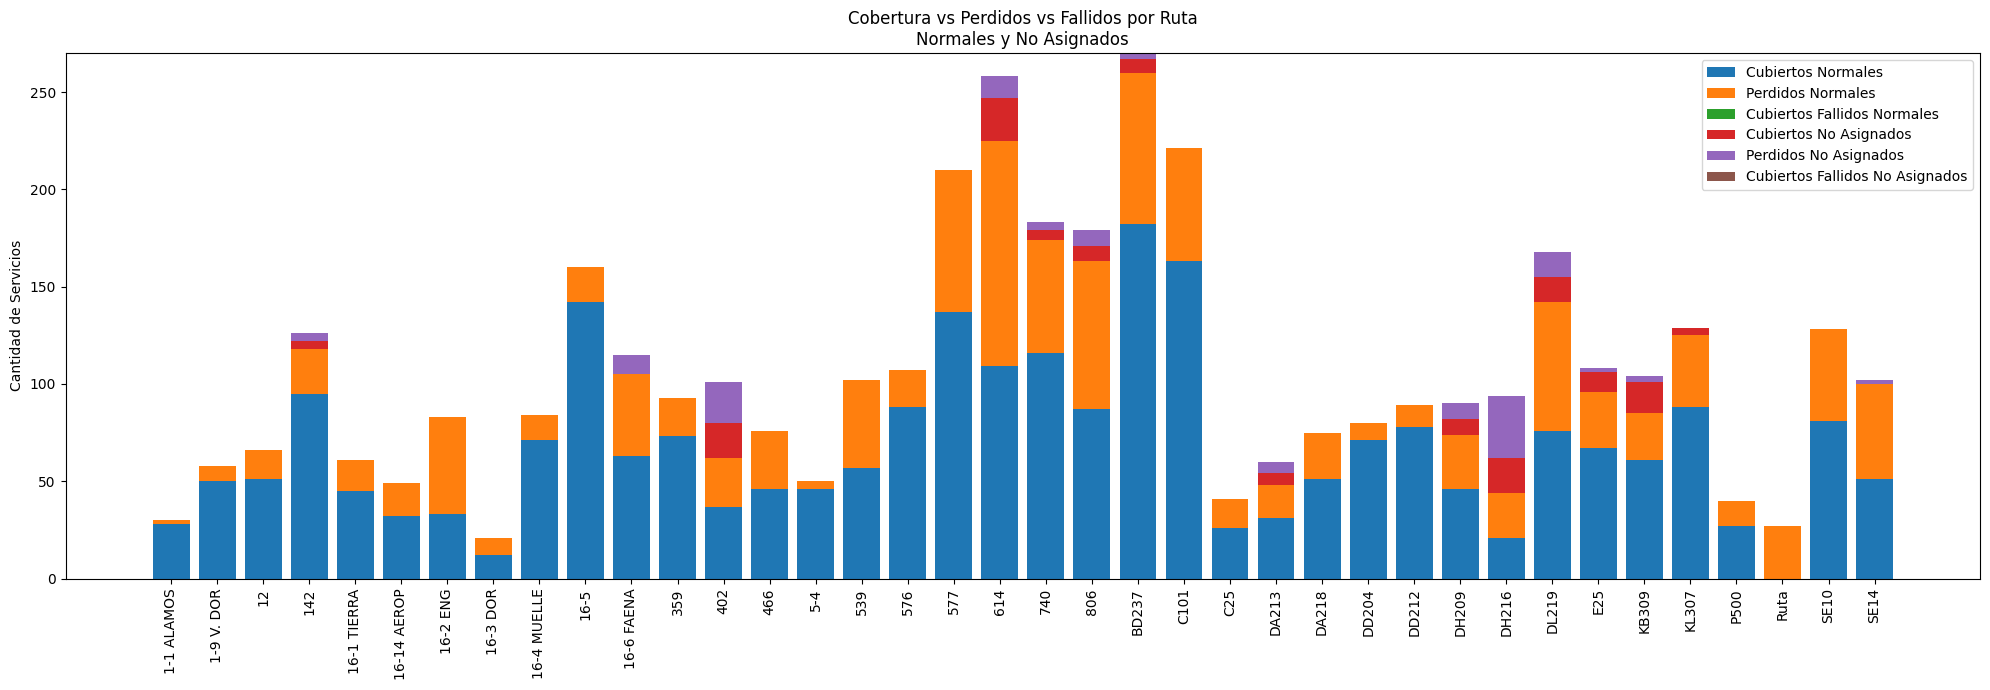

In [40]:
x = range(len(df))

plt.figure(figsize=(20,7))

# NORMALES
plt.bar(x, df["cubiertos_normales"], label="Cubiertos Normales")
plt.bar(
    x,
    df["perdidos_normales"],
    bottom=df["cubiertos_normales"],
    label="Perdidos Normales"
)
plt.bar(
    x,
    df["cubiertos_fallidos_normales"],
    bottom=df["cubiertos_normales"] + df["perdidos_normales"],
    label="Cubiertos Fallidos Normales"
)

# NO ASIGNADOS
plt.bar(
    x,
    df["cubiertos_no_asignados"],
    bottom=(
        df["cubiertos_normales"]
        + df["perdidos_normales"]
        + df["cubiertos_fallidos_normales"]
    ),
    label="Cubiertos No Asignados"
)

plt.bar(
    x,
    df["perdidos_no_asignados"],
    bottom=(
        df["cubiertos_normales"]
        + df["perdidos_normales"]
        + df["cubiertos_fallidos_normales"]
        + df["cubiertos_no_asignados"]
    ),
    label="Perdidos No Asignados"
)

plt.bar(
    x,
    df["cubiertos_fallidos_no_asignados"],
    bottom=(
        df["cubiertos_normales"]
        + df["perdidos_normales"]
        + df["cubiertos_fallidos_normales"]
        + df["cubiertos_no_asignados"]
        + df["perdidos_no_asignados"]
    ),
    label="Cubiertos Fallidos No Asignados"
)

plt.xticks(x, df["Ruta"], rotation=90)
plt.ylabel("Cantidad de Servicios")
plt.title("Cobertura vs Perdidos vs Fallidos por Ruta\nNormales y No Asignados")
plt.legend()
plt.tight_layout()
plt.show()

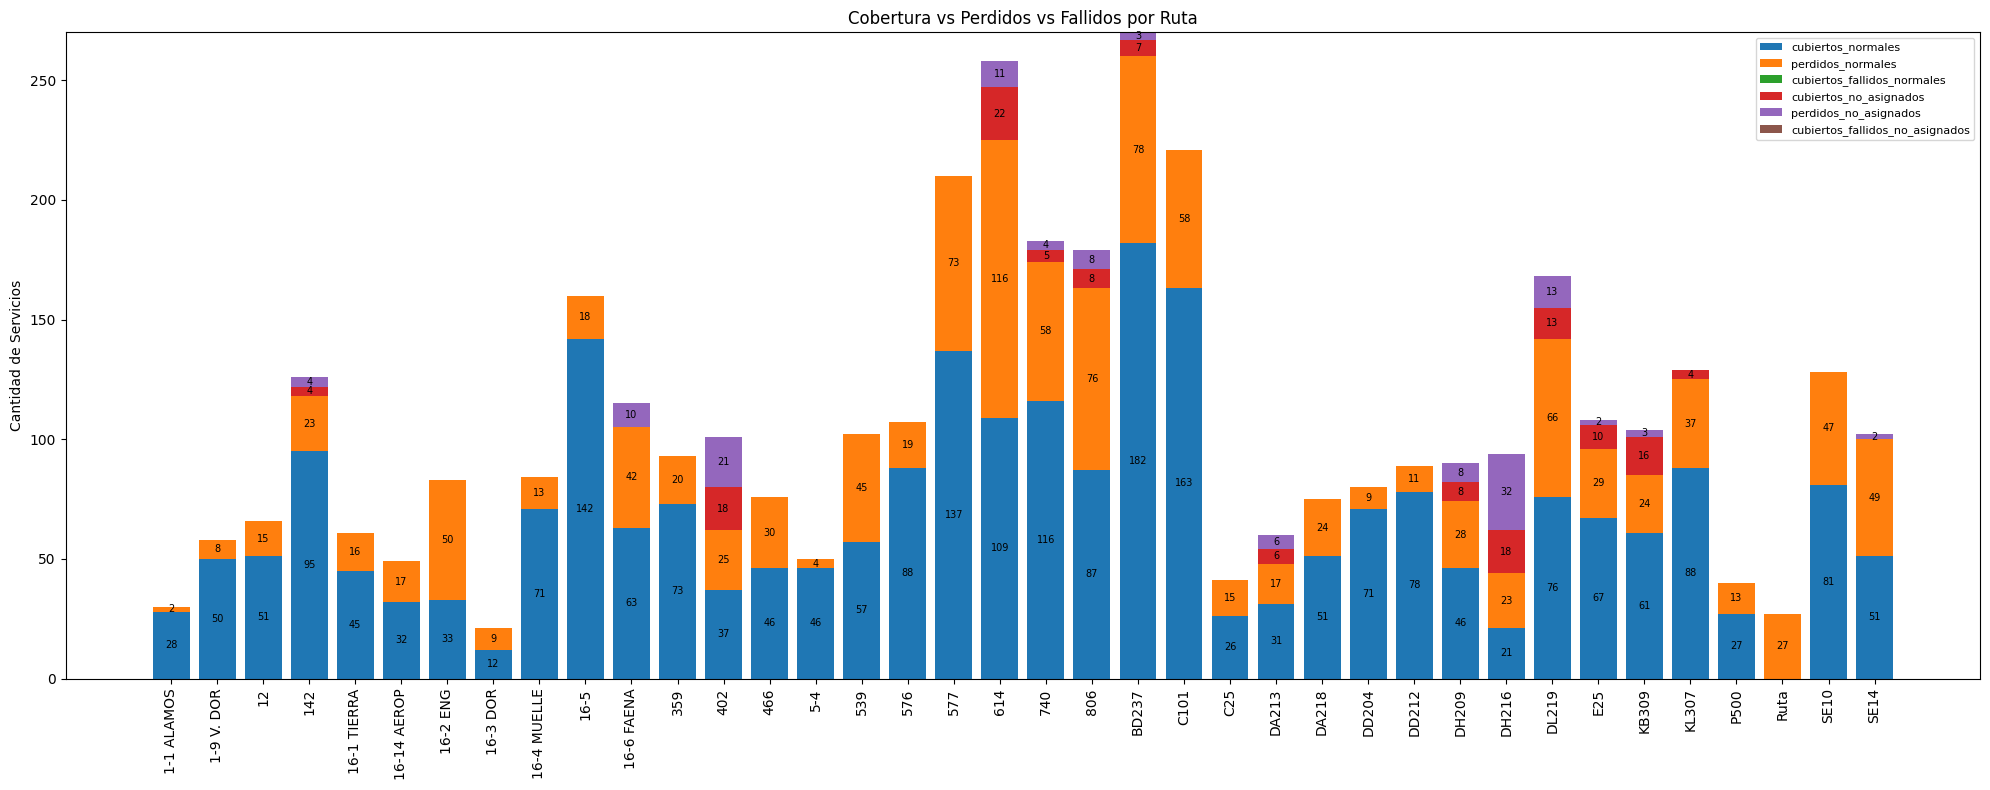

In [41]:
import matplotlib.pyplot as plt
import numpy as np

df = (
    analisis_final
    .groupby("Ruta")[[
        "cubiertos_normales",
        "perdidos_normales",
        "cubiertos_fallidos_normales",
        "cubiertos_no_asignados",
        "perdidos_no_asignados",
        "cubiertos_fallidos_no_asignados"
    ]]
    .sum()
    .reset_index()
)

x = np.arange(len(df))

plt.figure(figsize=(20,8))

# Variables para acumulado (bottom dinámico)
bottom = np.zeros(len(df))

columnas = [
    "cubiertos_normales",
    "perdidos_normales",
    "cubiertos_fallidos_normales",
    "cubiertos_no_asignados",
    "perdidos_no_asignados",
    "cubiertos_fallidos_no_asignados"
]

for col in columnas:
    valores = df[col].values
    bars = plt.bar(x, valores, bottom=bottom, label=col)

    # Agregar etiquetas pequeñas
    for i, (valor, btm) in enumerate(zip(valores, bottom)):
        if valor > 0:  # evitar mostrar ceros
            plt.text(
                i,
                btm + valor / 2,
                str(int(valor)),
                ha='center',
                va='center',
                fontsize=7
            )

    bottom += valores

plt.xticks(x, df["Ruta"], rotation=90)
plt.ylabel("Cantidad de Servicios")
plt.title("Cobertura vs Perdidos vs Fallidos por Ruta")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [42]:
casos_criticos = bitacora[
    (bitacora["cubierto_bin"] == 1) &
    (bitacora["perdido_bin"] == 1)
]

casos_criticos.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,parte,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante,servicio_cubierto,cubierto_bin,perdido_bin,cubierto_faltante_bin
767,Ausentismo 509874 ...,ALVARO ENRIQUE FUENTES MONTERO ...,CE13C0007,19:32:45,22:09:45,247A05_TM,247A05_TM,SE10,SE10_FMS_2,"39,578 Operador no se presenta",...,1,Gestion del Operador,Operador no se presenta,2.0,1,1,cubierto,1,1,0
1278,Ausentismo 510303 ...,ANDRES FABIAN TOVAR MORENO ...,CE1780025,12:29:00,15:47:15,247A05_TM,548A12_TM,577,577_VUELTA_FMS_2,"39,669 Operador no se presenta",...,1,Gestion del Operador,Operador no se presenta,1.0,1,1,cubierto,1,1,0
1279,Ausentismo 510303 ...,ANDRES FABIAN TOVAR MORENO ...,CE1780025,16:12:15,19:38:15,548A12_TM,247A05_TM,577,577_IDA_FMS_2,"37,292 Operador no se presenta",...,2,Gestion del Operador,Operador no se presenta,1.0,1,1,cubierto,1,1,0
1416,Ausentismo 508745 ...,ANDRES FELIPE MORENO QUINTERO ...,CE0A40002,13:08:00,14:04:00,PORTAL DORADO_16-6,PORTAL DORADO_16-6,16-6 FAENA,16-6 La Faena_Circular,"14,465 Operador no se presenta",...,1,Gestion del Operador,Operador no se presenta,1.0,1,1,cubierto,1,1,0
1780,508105 509808,ANGEL EFRAIN LOPEZ ORJUELA ...,CE1780004,07:19:00,10:35:00,247A05_TM,548A12_TM,577,577_VUELTA_FMS_2,"39,669 Movil llega tarde - IncorporaciÃ³n",...,1,Gestion de Mtto,Movil llega tarde - Incorporación,1.0,1,1,cubierto,1,1,0


In [44]:
import numpy as np

df_bitacora = bitacora.copy()

# Normalizar vacíos (None, NaN, string vacío)
df_bitacora["estado_novedad"] = df_bitacora["estado_novedad"].replace("", np.nan)

# Crear nueva columna clasificada
df_bitacora["novedad_clasificada"] = df_bitacora["estado_novedad"]

# Si está vacío y está cubierto → "Por identificar"
df_bitacora.loc[
    df_bitacora["estado_novedad"].isna() & (df_bitacora["cubierto_bin"] == 1),
    "novedad_clasificada"
] = "Por identificar"

df_bitacora.head(2)

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,Motivo_perdida,Causa,Parte de trabajo,estado_perdido,servicio_cubierto_faltante,servicio_cubierto,cubierto_bin,perdido_bin,cubierto_faltante_bin,novedad_clasificada
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,None,None,NaN,0,0,No cubierto,0,0,0,NaN
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,None,None,NaN,0,0,No cubierto,0,0,0,NaN


In [46]:
df_bitacora['tiene_novedad'] = np.where(
    df_bitacora['estado_novedad'].notna(),
    1,
    0
)

In [47]:
df_bitacora["cubiertos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["cubierto_bin"] == 1)
).astype(int)

df_bitacora["perdidos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["perdido_bin"] == 1)
).astype(int)

df_bitacora.head()

,CÃ³digo conductor,Conductor,Servicio,Hora Inicio,Hora Fin,Origen,Destino,Ruta,Tarea,Distancia Km,...,estado_perdido,servicio_cubierto_faltante,servicio_cubierto,cubierto_bin,perdido_bin,cubierto_faltante_bin,novedad_clasificada,tiene_novedad,cubiertos_con_novedad,perdidos_con_novedad
0,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,04:08:15,06:04:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,36.341,...,0,0,No cubierto,0,0,0,NaN,0,0,0
1,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0004,06:04:00,08:52:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,36.909,...,0,0,No cubierto,0,0,0,NaN,0,0,0
2,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,18:24:00,21:13:00,072A05_TM_(Engativa),554A12_TM,SE14,SE14_VUELTA_FMS_2,"36,341 Operador no se presenta",...,1,0,No cubierto,0,1,0,NaN,0,0,0
3,507680,ADAN ALBERTO ALVARADO PEREZ,BC29D0037,21:30:00,23:17:00,554A12_TM,072A05_TM_(Engativa),SE14,SE14_IDA_FMS_2,"36,909 Operador no se presenta",...,1,0,No cubierto,0,1,0,NaN,0,0,0
4,507680,ADAN ALBERTO ALVARADO PEREZ,CE0B10002,15:57:00,16:34:30,495A04_EstaciÃ³nLa Granja,495A04_EstaciÃ³nLa Granja,5-4,5-4_FMS,6.987,...,0,0,No cubierto,0,0,0,NaN,0,0,0


In [48]:
resumen_fecha = (
    df_bitacora
    .groupby("Fecha")
    .agg(
        total_servicios = ("Ruta", "count"),
        con_novedad = ("tiene_novedad", "sum"),
        cubiertos = ("cubierto_bin", "sum"),
        perdidos = ("perdido_bin", "sum"),
        cubiertos_con_novedad = ("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad = ("perdidos_con_novedad", "sum")
    )
    .reset_index()
)

resumen_fecha

,Fecha,total_servicios,con_novedad,cubiertos,perdidos,cubiertos_con_novedad,perdidos_con_novedad
0,2026-04-01,3739,238,301,94,197,27
1,2026-04-02,2226,148,180,33,144,8
2,2026-04-03,2226,151,204,24,148,4
3,2026-04-04,2879,301,380,44,284,12
4,2026-04-05,2226,216,280,34,204,12
5,2026-04-06,4006,298,317,284,204,89
6,2026-04-07,4006,339,355,278,260,78
7,2026-04-08,4006,279,324,303,217,69
8,2026-04-09,4006,308,336,267,237,66


In [49]:
resumen_ruta = (
    df_bitacora
    .groupby("Ruta")
    .agg(
        total_servicios = ("Ruta", "count"),
        con_novedad = ("tiene_novedad", "sum"),
        cubiertos = ("cubierto_bin", "sum"),
        perdidos = ("perdido_bin", "sum"),
        cubiertos_con_novedad = ("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad = ("perdidos_con_novedad", "sum")
    )
    .reset_index()
)

resumen_ruta

,Ruta,total_servicios,con_novedad,cubiertos,perdidos,cubiertos_con_novedad,perdidos_con_novedad
0,1-1 ALAMOS,695,22,28,2,22,0
1,1-9 V. DOR,733,30,50,8,30,0
2,12,482,37,51,15,33,3
3,142,524,71,99,27,68,6
4,16-1 TIERRA,813,36,45,16,36,2
5,16-14 AEROP,819,32,32,17,32,1
6,16-2 ENG,1258,33,33,50,33,2
7,16-3 DOR,843,11,12,9,7,0
8,16-4 MUELLE,961,65,71,13,65,0
9,16-5,1176,112,142,18,99,7


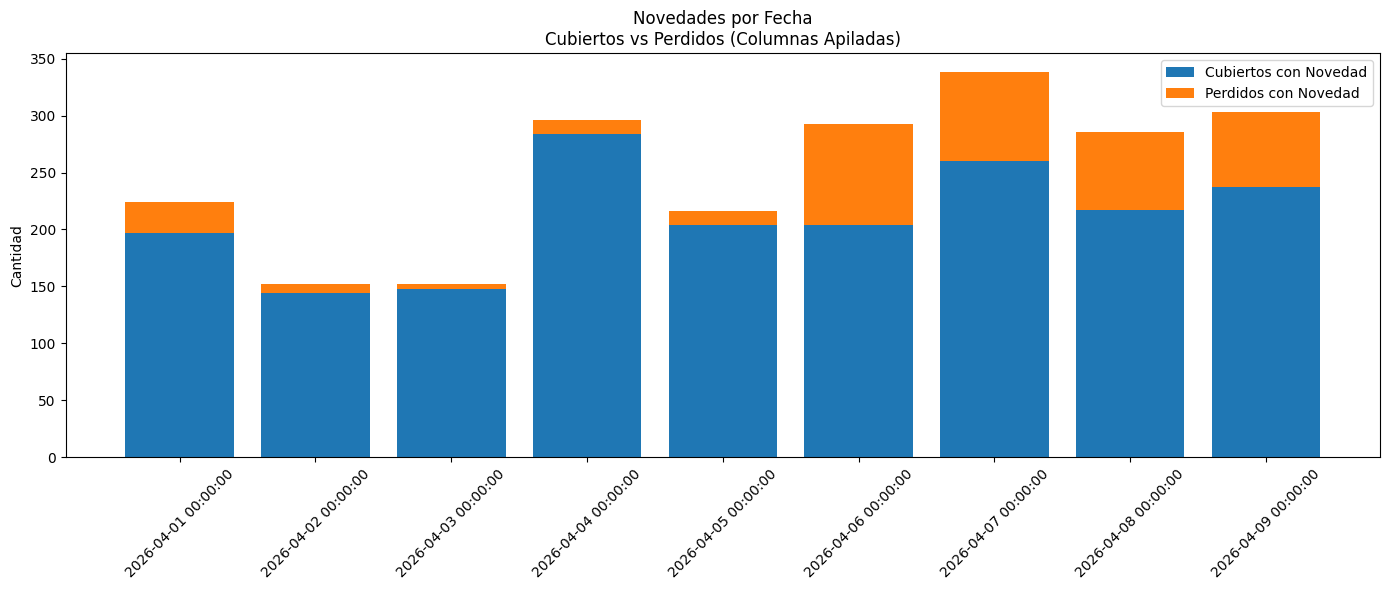

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Crear columnas auxiliares (por seguridad)
df_bitacora["cubiertos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["cubierto_bin"] == 1)
).astype(int)

df_bitacora["perdidos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["perdido_bin"] == 1)
).astype(int)

# Resumen por Fecha
resumen_fecha = (
    df_bitacora
    .groupby("Fecha")
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum")
    )
    .reset_index()
    .sort_values("Fecha")
)

# Preparar datos
x = np.arange(len(resumen_fecha))
cubiertos = resumen_fecha["cubiertos_con_novedad"].values
perdidos = resumen_fecha["perdidos_con_novedad"].values

# Crear gráfica
plt.figure(figsize=(14,6))

plt.bar(x, cubiertos, label="Cubiertos con Novedad")
plt.bar(x, perdidos, bottom=cubiertos, label="Perdidos con Novedad")

plt.xticks(x, resumen_fecha["Fecha"], rotation=45)
plt.ylabel("Cantidad")
plt.title("Novedades por Fecha\nCubiertos vs Perdidos (Columnas Apiladas)")
plt.legend()

plt.tight_layout()
plt.show()

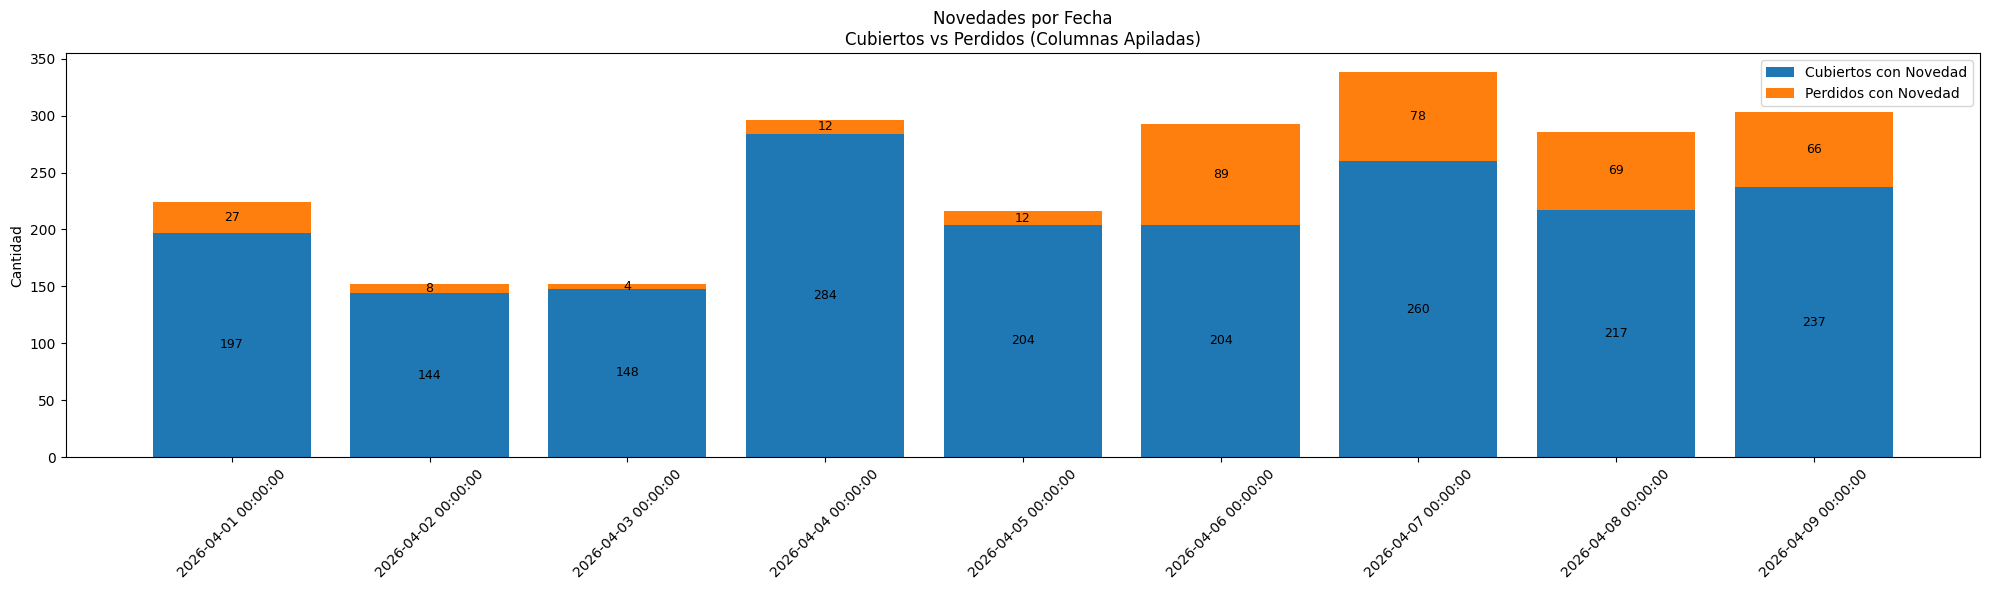

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Crear columnas auxiliares (si no existen)
df_bitacora["cubiertos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["cubierto_bin"] == 1)
).astype(int)

df_bitacora["perdidos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["perdido_bin"] == 1)
).astype(int)

# Resumen por Fecha
resumen_fecha = (
    df_bitacora
    .groupby("Fecha")
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum")
    )
    .reset_index()
    .sort_values("Fecha")
)

# Preparar datos
x = np.arange(len(resumen_fecha))
cubiertos = resumen_fecha["cubiertos_con_novedad"].values
perdidos = resumen_fecha["perdidos_con_novedad"].values

plt.figure(figsize=(20,6))

# Barras
bars1 = plt.bar(x, cubiertos, label="Cubiertos con Novedad")
bars2 = plt.bar(x, perdidos, bottom=cubiertos, label="Perdidos con Novedad")

# Etiquetas en cubiertos
for i, v in enumerate(cubiertos):
    if v > 0:
        plt.text(i, v/2, str(int(v)),
                 ha='center', va='center', fontsize=9)

# Etiquetas en perdidos
for i, v in enumerate(perdidos):
    if v > 0:
        plt.text(i, cubiertos[i] + v/2, str(int(v)),
                 ha='center', va='center', fontsize=9)

plt.xticks(x, resumen_fecha["Fecha"], rotation=45)
plt.ylabel("Cantidad")
plt.title("Novedades por Fecha\nCubiertos vs Perdidos (Columnas Apiladas)")
plt.legend()

plt.tight_layout()
plt.show()

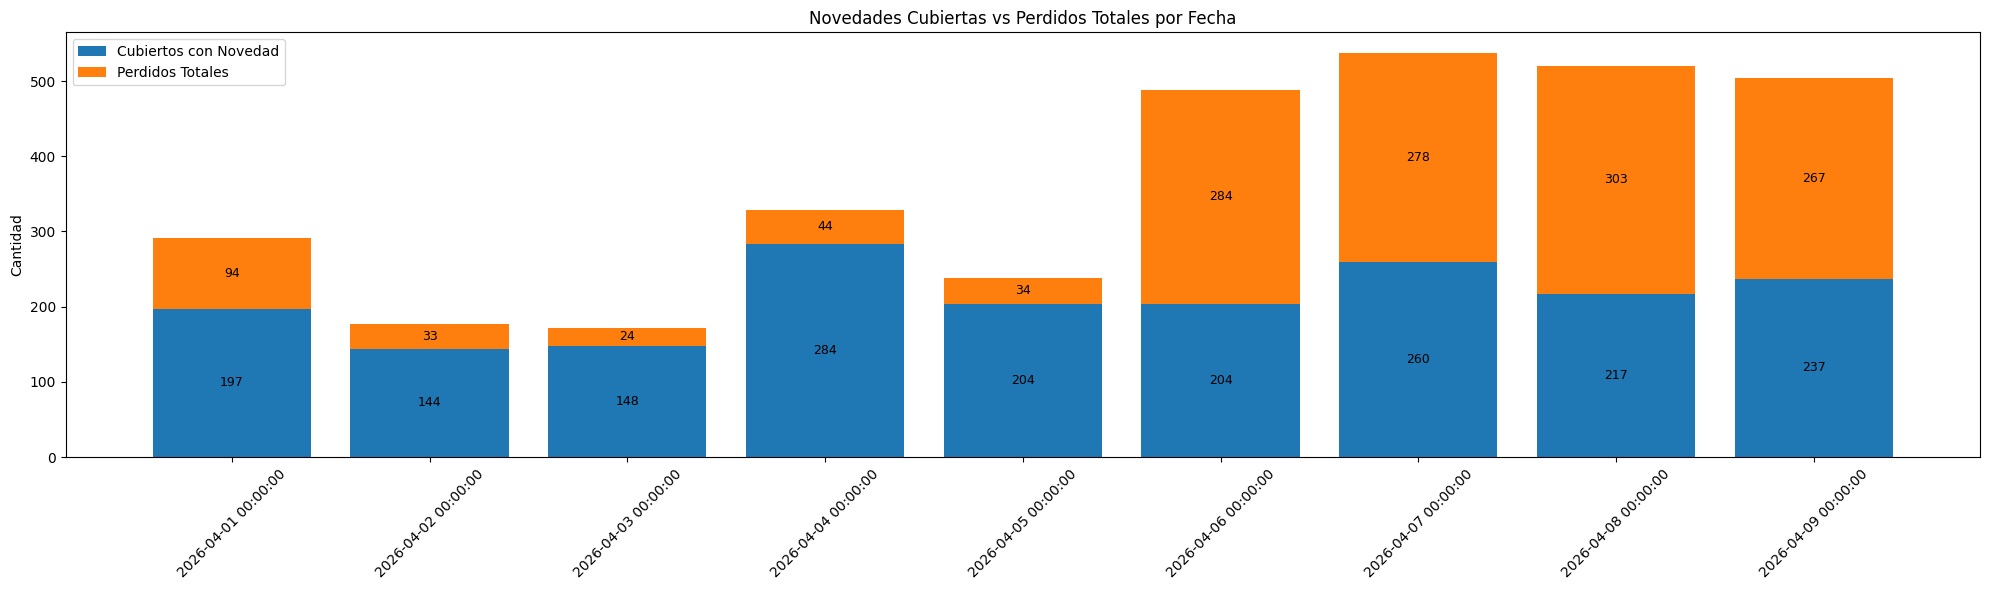

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurar columnas auxiliares
df_bitacora["cubiertos_con_novedad"] = (
    (df_bitacora["tiene_novedad"] == 1) &
    (df_bitacora["cubierto_bin"] == 1)
).astype(int)

# Resumen por Fecha
resumen_fecha = (
    df_bitacora
    .groupby("Fecha")
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")  # ← aquí está el cambio
    )
    .reset_index()
    .sort_values("Fecha")
)

# Preparar datos
x = np.arange(len(resumen_fecha))
cubiertos = resumen_fecha["cubiertos_con_novedad"].values
perdidos = resumen_fecha["perdidos_totales"].values

plt.figure(figsize=(20,6))

# Barras apiladas
plt.bar(x, cubiertos, label="Cubiertos con Novedad")
plt.bar(x, perdidos, bottom=cubiertos, label="Perdidos Totales")

# Etiquetas cubiertos
for i, v in enumerate(cubiertos):
    if v > 0:
        plt.text(i, v/2, str(int(v)),
                 ha='center', va='center', fontsize=9)

# Etiquetas perdidos
for i, v in enumerate(perdidos):
    if v > 0:
        plt.text(i, cubiertos[i] + v/2, str(int(v)),
                 ha='center', va='center', fontsize=9)

plt.xticks(x, resumen_fecha["Fecha"], rotation=45)
plt.ylabel("Cantidad")
plt.title("Novedades Cubiertas vs Perdidos Totales por Fecha")
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
import numpy as np

# Convertir a string
df_bitacora["Hora Inicio"] = df_bitacora["Hora Inicio"].astype(str)

# Extraer solo las horas válidas tipo 05:30, 17:45 etc
df_bitacora["Franja"] = (
    df_bitacora["Hora Inicio"]
    .str.extract(r'^(\d{1,2}):')   # toma solo números antes de :
)

# Convertir a numérico (los inválidos quedan como NaN)
df_bitacora["Franja"] = pd.to_numeric(df_bitacora["Franja"], errors="coerce")

# Opcional: eliminar registros sin hora válida
df_bitacora = df_bitacora[df_bitacora["Franja"].notna()]

# Convertir a entero
df_bitacora["Franja"] = df_bitacora["Franja"].astype(int)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_10856\2052652857.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bitacora["Franja"] = df_bitacora["Franja"].astype(int)


In [54]:
resumen_fecha_ruta = (
    df_bitacora
    .groupby(["Fecha", "Ruta", "Franja"])
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")  # ← corregido aquí
    )
    .reset_index()
)

resumen_fecha_ruta.head()

,Fecha,Ruta,Franja,cubiertos_con_novedad,perdidos_con_novedad,perdidos_totales
0,2026-04-01,1-1 ALAMOS,4,0,0,0
1,2026-04-01,1-1 ALAMOS,5,0,0,0
2,2026-04-01,1-1 ALAMOS,6,0,0,0
3,2026-04-01,1-1 ALAMOS,7,0,0,0
4,2026-04-01,1-1 ALAMOS,8,0,0,0


In [55]:
import matplotlib.pyplot as plt
import numpy as np

resumen_fecha_franja = (
    df_bitacora
    .groupby(["Fecha", "Franja"])
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")  # ← corregido aquí
    )
    .reset_index()
)

resumen_fecha_franja.head()

,Fecha,Franja,cubiertos_con_novedad,perdidos_con_novedad,perdidos_totales
0,2026-04-01,3,3,1,1
1,2026-04-01,4,13,2,8
2,2026-04-01,5,14,3,7
3,2026-04-01,6,14,4,8
4,2026-04-01,7,10,1,8


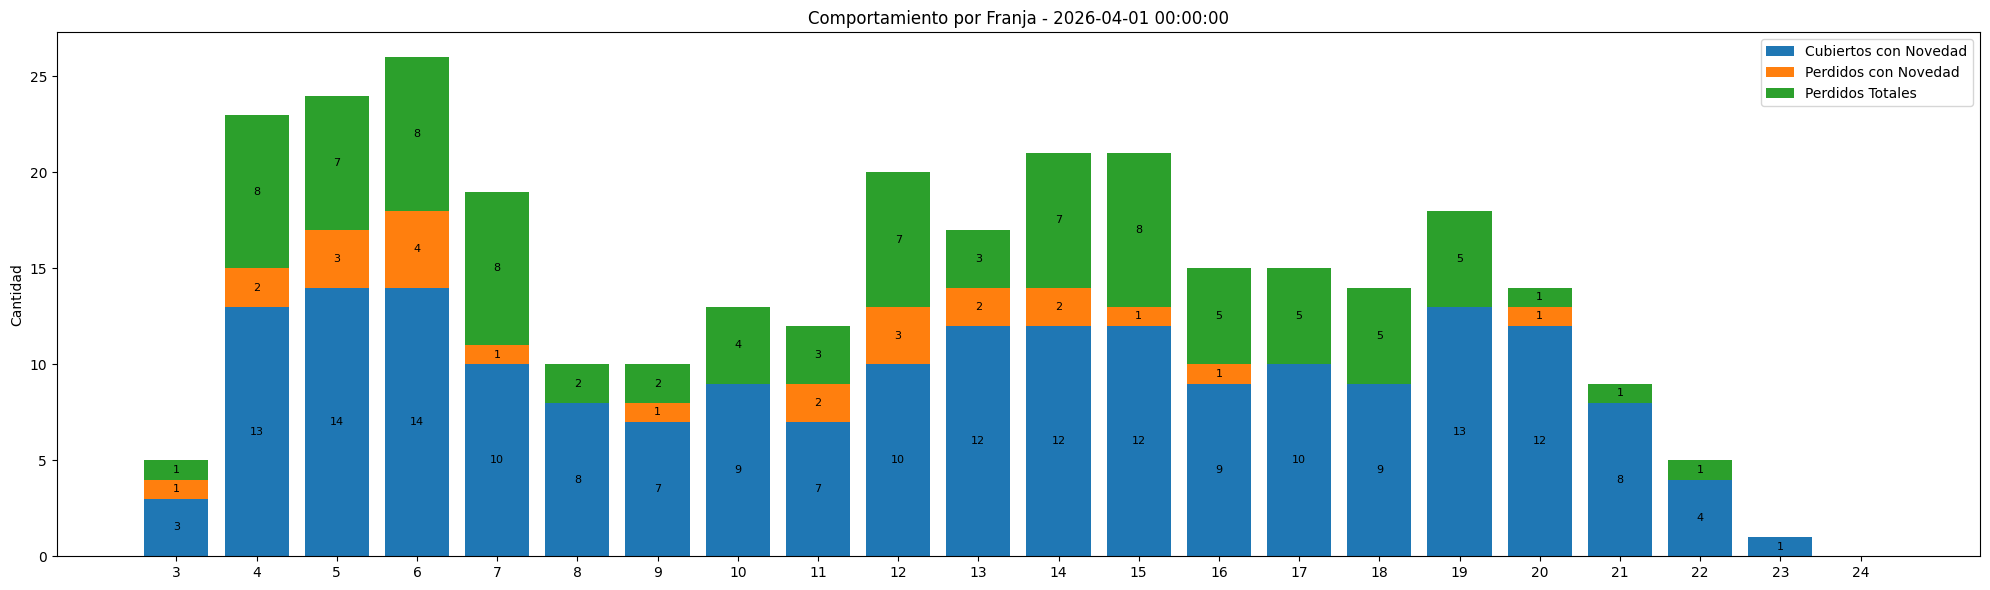

In [56]:
fecha_elegida = resumen_fecha_franja["Fecha"].iloc[0]

df_plot = resumen_fecha_franja[
    resumen_fecha_franja["Fecha"] == fecha_elegida
].sort_values("Franja")

x = np.arange(len(df_plot))

c1 = df_plot["cubiertos_con_novedad"].values
c2 = df_plot["perdidos_con_novedad"].values
c3 = df_plot["perdidos_totales"].values

plt.figure(figsize=(20,6))

plt.bar(x, c1, label="Cubiertos con Novedad")
plt.bar(x, c2, bottom=c1, label="Perdidos con Novedad")
plt.bar(x, c3, bottom=c1+c2, label="Perdidos Totales")

# Etiquetas
for i in range(len(x)):
    if c1[i] > 0:
        plt.text(i, c1[i]/2, str(int(c1[i])), ha='center', va='center', fontsize=8)
    if c2[i] > 0:
        plt.text(i, c1[i] + c2[i]/2, str(int(c2[i])), ha='center', va='center', fontsize=8)
    if c3[i] > 0:
        plt.text(i, c1[i] + c2[i] + c3[i]/2, str(int(c3[i])), ha='center', va='center', fontsize=8)

plt.xticks(x, df_plot["Franja"])
plt.title(f"Comportamiento por Franja - {fecha_elegida}")
plt.ylabel("Cantidad")
plt.legend()
plt.tight_layout()
plt.show()

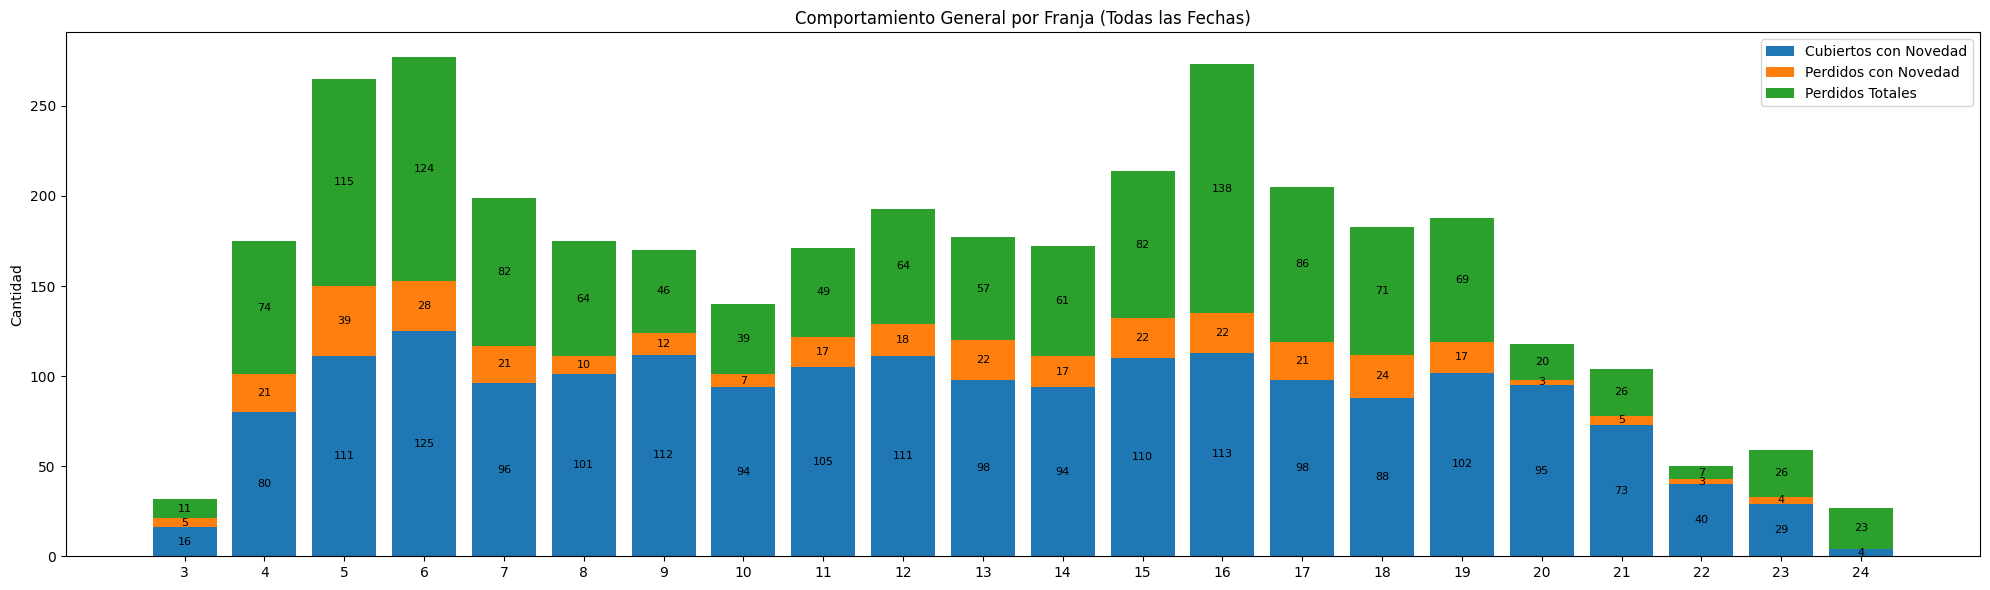

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar SOLO por Franja (todas las fechas consolidadas)
resumen_franja = (
    df_bitacora
    .groupby("Franja")
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")
    )
    .reset_index()
    .sort_values("Franja")
)

x = np.arange(len(resumen_franja))

c1 = resumen_franja["cubiertos_con_novedad"].values
c2 = resumen_franja["perdidos_con_novedad"].values
c3 = resumen_franja["perdidos_totales"].values

plt.figure(figsize=(20,6))

# Columnas apiladas
plt.bar(x, c1, label="Cubiertos con Novedad")
plt.bar(x, c2, bottom=c1, label="Perdidos con Novedad")
plt.bar(x, c3, bottom=c1+c2, label="Perdidos Totales")

# Etiquetas
for i in range(len(x)):
    if c1[i] > 0:
        plt.text(i, c1[i]/2, str(int(c1[i])), ha='center', va='center', fontsize=8)
    if c2[i] > 0:
        plt.text(i, c1[i] + c2[i]/2, str(int(c2[i])), ha='center', va='center', fontsize=8)
    if c3[i] > 0:
        plt.text(i, c1[i] + c2[i] + c3[i]/2, str(int(c3[i])), ha='center', va='center', fontsize=8)

plt.xticks(x, resumen_franja["Franja"])
plt.title("Comportamiento General por Franja (Todas las Fechas)")
plt.ylabel("Cantidad")
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
resumen_ruta = (
    df_bitacora
    .groupby("Ruta")
    .agg(
        total_servicios=("Ruta", "count"),
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum"),
        total_novedades=("tiene_novedad", "sum")
    )
    .reset_index()
)

# Métricas clave
resumen_ruta["% perdida_total"] = (
    resumen_ruta["perdidos_totales"] / resumen_ruta["total_servicios"]
) * 100

resumen_ruta["% perdida_novedad"] = (
    resumen_ruta["perdidos_con_novedad"] / resumen_ruta["total_novedades"]
) * 100

resumen_ruta["% cobertura_novedad"] = (
    resumen_ruta["cubiertos_con_novedad"] / resumen_ruta["total_novedades"]
) * 100

resumen_ruta = resumen_ruta.fillna(0)

resumen_ruta.head()

,Ruta,total_servicios,cubiertos_con_novedad,perdidos_con_novedad,perdidos_totales,total_novedades,% perdida_total,% perdida_novedad,% cobertura_novedad
0,1-1 ALAMOS,695,22,0,2,22,0.287770,0.000000,100.000000
1,1-9 V. DOR,733,30,0,8,30,1.091405,0.000000,100.000000
2,12,482,33,3,15,37,3.112033,8.108108,89.189189
3,142,524,68,6,27,71,5.152672,8.450704,95.774648
4,16-1 TIERRA,813,36,2,16,36,1.968020,5.555556,100.000000


In [59]:
top_perdidos = (
    resumen_ruta
    .sort_values("perdidos_totales", ascending=False)
    .head(5)
)

top_perdidos[["Ruta", "perdidos_totales", "% perdida_total"]]

,Ruta,perdidos_totales,% perdida_total
18,614,127,6.924755
20,806,84,6.603774
21,BD237,81,5.995559
30,DL219,79,8.413206
17,577,73,6.952381


In [60]:
top_perdidos_novedad = (
    resumen_ruta
    .sort_values("perdidos_con_novedad", ascending=False)
    .head(5)
)

top_perdidos_novedad[["Ruta", "perdidos_con_novedad", "% perdida_novedad"]]

,Ruta,perdidos_con_novedad,% perdida_novedad
18,614,34,28.571429
21,BD237,29,16.292135
30,DL219,23,31.506849
20,806,23,26.436782
17,577,21,15.909091


In [61]:
peor_cobertura = (
    resumen_ruta
    .sort_values("% cobertura_novedad")
    .head(5)
)

peor_cobertura[["Ruta", "% cobertura_novedad", "perdidos_con_novedad"]]

,Ruta,% cobertura_novedad,perdidos_con_novedad
29,DH216,60.000000,12
24,DA213,61.538462,7
7,16-3 DOR,63.636364,0
36,SE14,68.000000,16
25,DA218,70.731707,11


In [62]:
resumen_ruta["indice_criticidad"] = (
    resumen_ruta["% perdida_total"] * 0.4 +
    resumen_ruta["% perdida_novedad"] * 0.3 +
    (100 - resumen_ruta["% cobertura_novedad"]) * 0.3
)

ranking_final = (
    resumen_ruta
    .sort_values("indice_criticidad", ascending=False)
    .head(5)
)

ranking_final[["Ruta", "indice_criticidad"]]

,Ruta,indice_criticidad
29,DH216,27.298351
24,DA213,21.711057
36,SE14,21.600000
30,DL219,21.036515
20,806,19.193234


In [63]:
# Top 5 rutas con más perdidos totales
top_rutas = (
    df_bitacora
    .groupby("Ruta")["perdido_bin"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_rutas

Index(['614', '806', 'BD237', 'DL219', '577'], dtype='object', name='Ruta')

In [64]:
resumen_top = (
    df_bitacora[df_bitacora["Ruta"].isin(top_rutas)]
    .groupby(["Ruta", "Franja"])
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")
    )
    .reset_index()
)

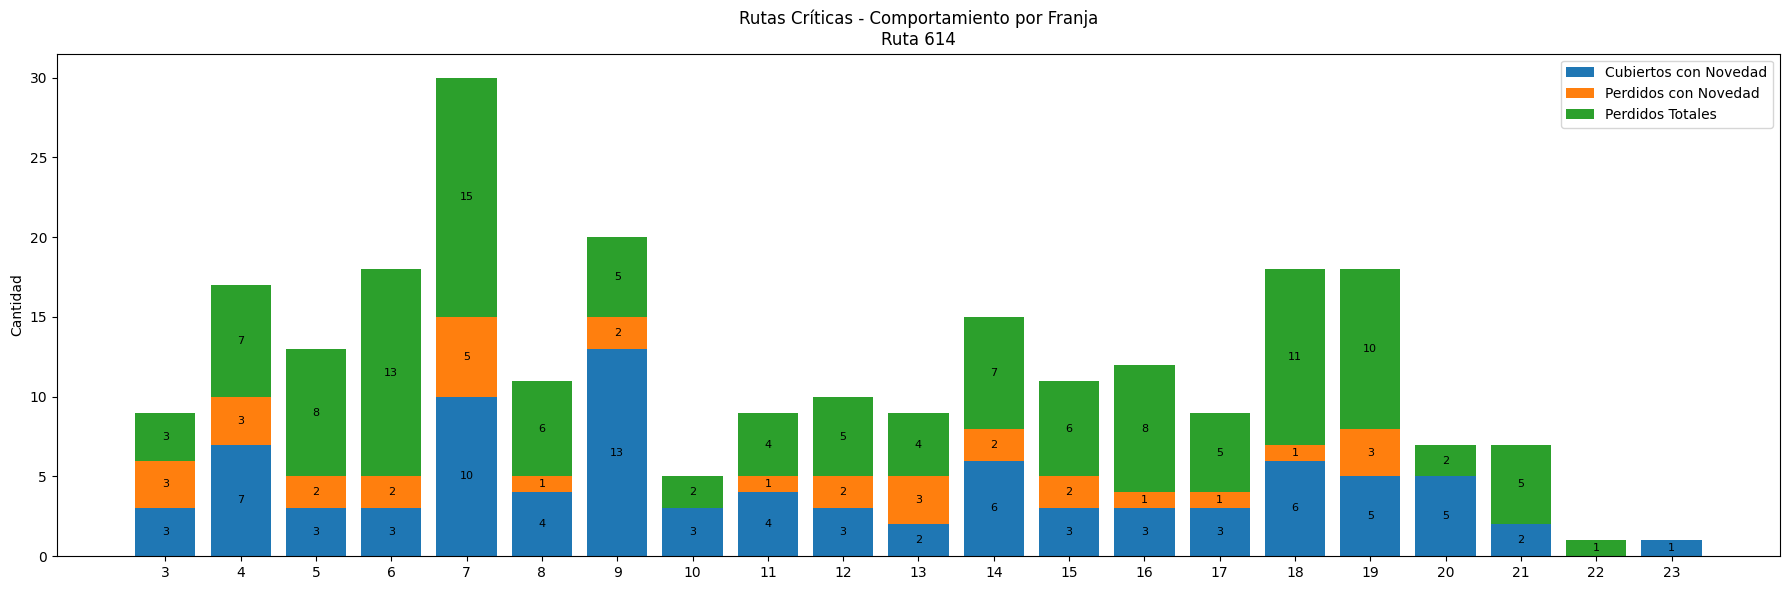

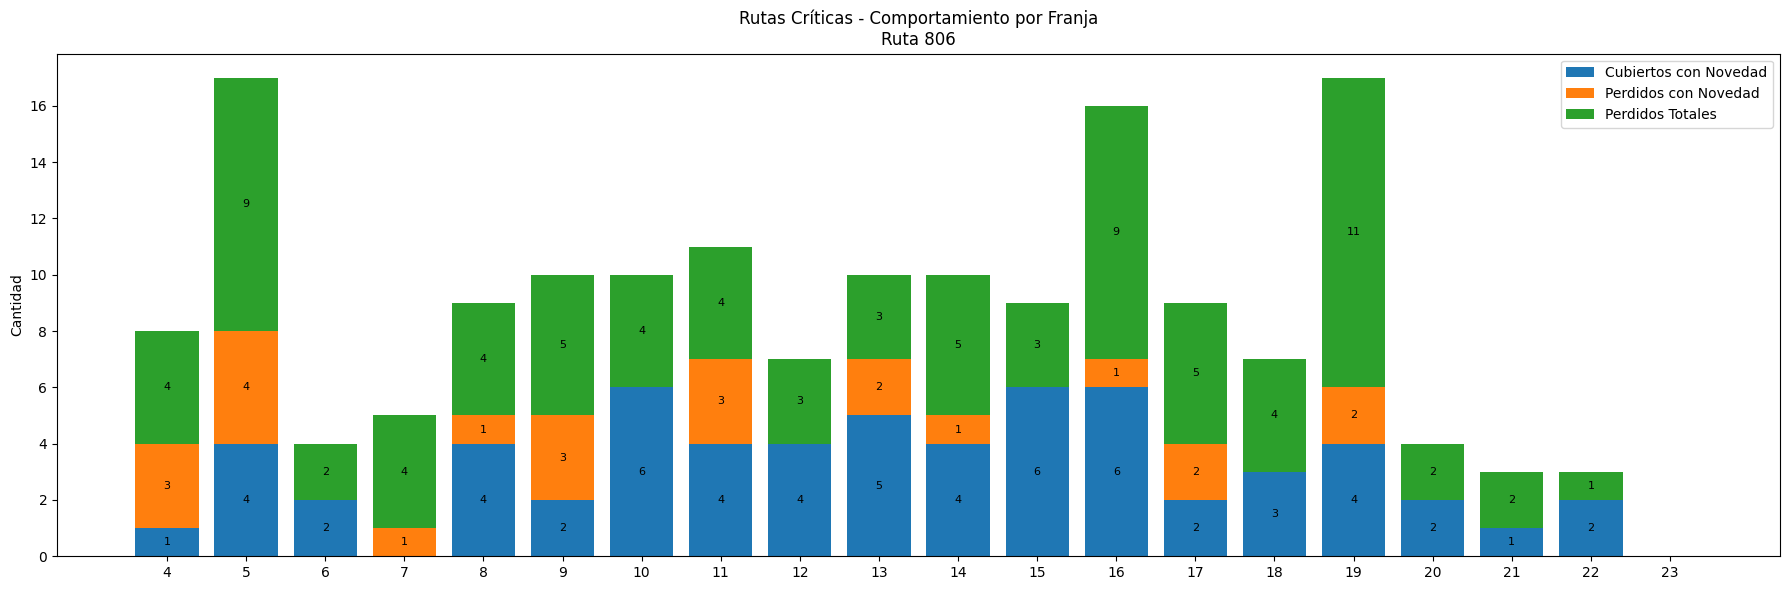

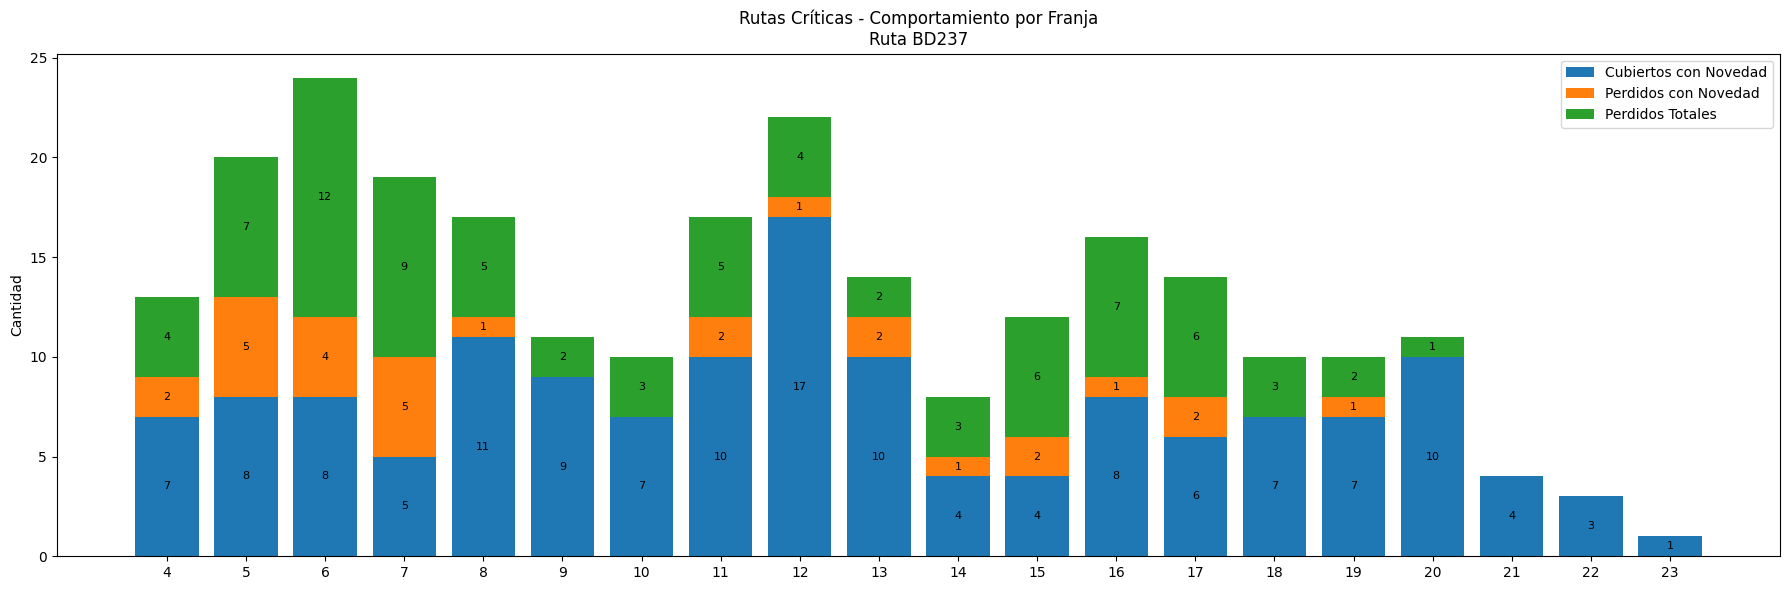

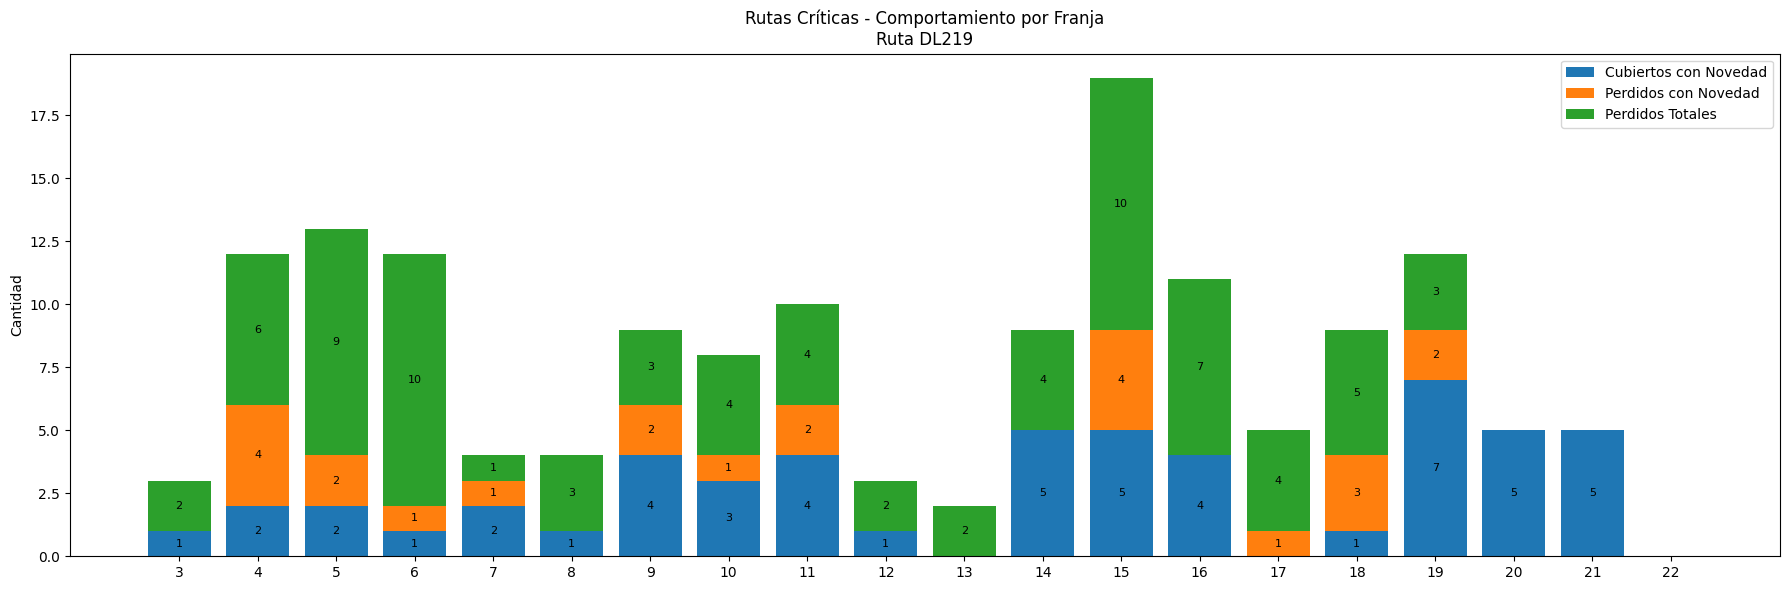

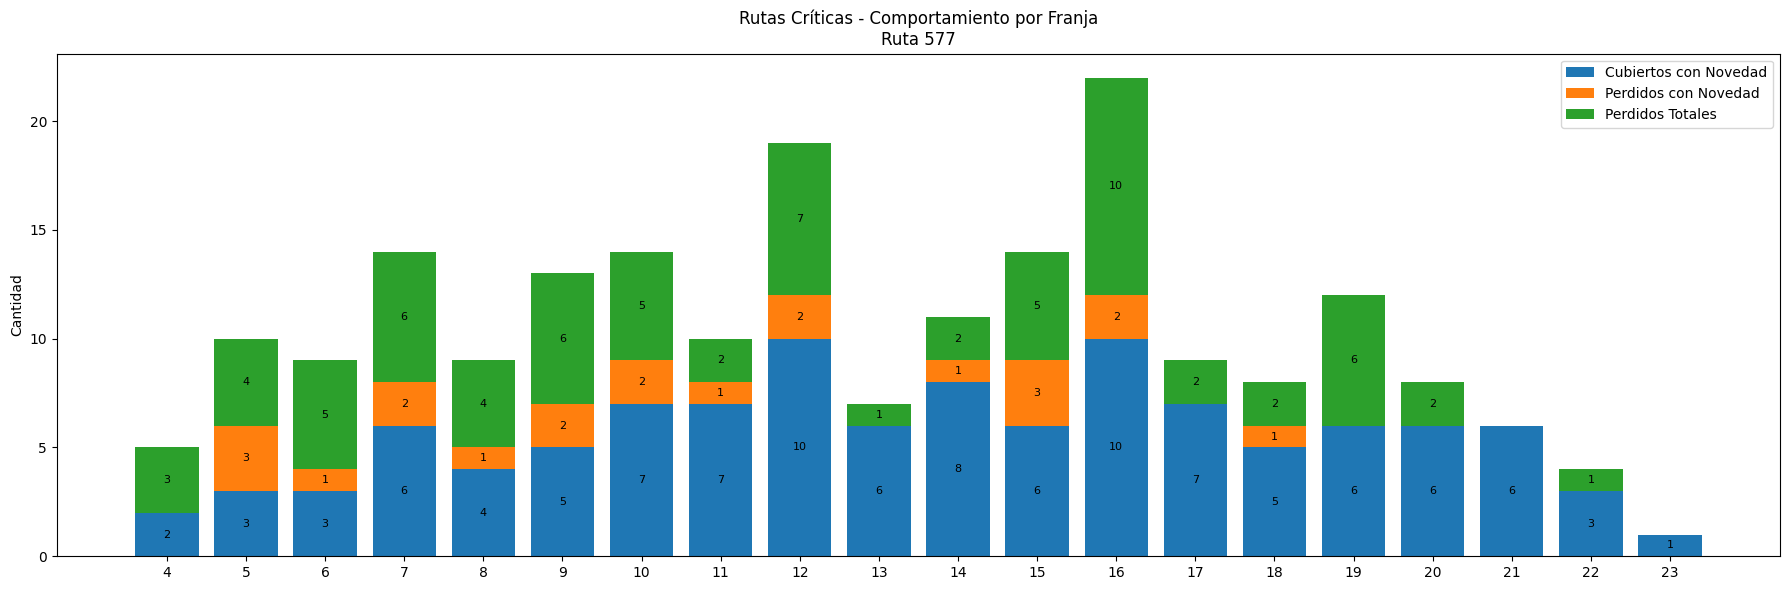

In [65]:
import matplotlib.pyplot as plt
import numpy as np

for ruta in top_rutas:
    
    df_plot = (
        resumen_top[resumen_top["Ruta"] == ruta]
        .sort_values("Franja")
    )
    
    x = np.arange(len(df_plot))
    
    c1 = df_plot["cubiertos_con_novedad"].values
    c2 = df_plot["perdidos_con_novedad"].values
    c3 = df_plot["perdidos_totales"].values
    
    plt.figure(figsize=(18,6))
    
    plt.bar(x, c1, label="Cubiertos con Novedad")
    plt.bar(x, c2, bottom=c1, label="Perdidos con Novedad")
    plt.bar(x, c3, bottom=c1+c2, label="Perdidos Totales")
    
    # Etiquetas
    for i in range(len(x)):
        if c1[i] > 0:
            plt.text(i, c1[i]/2, str(int(c1[i])), ha='center', va='center', fontsize=8)
        if c2[i] > 0:
            plt.text(i, c1[i] + c2[i]/2, str(int(c2[i])), ha='center', va='center', fontsize=8)
        if c3[i] > 0:
            plt.text(i, c1[i] + c2[i] + c3[i]/2, str(int(c3[i])), ha='center', va='center', fontsize=8)
    
    plt.xticks(x, df_plot["Franja"])
    plt.title(f"Rutas Críticas - Comportamiento por Franja\nRuta {ruta}")
    plt.ylabel("Cantidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [67]:
patron_motivo = (
    casos_criticos
    .groupby("Motivo_perdida")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

patron_motivo.head()

,Motivo_perdida,cantidad
1,Gestion de Mtto,51
4,Gestion del Operador,31
0,Gestion de Centro de Control,7
3,Gestion de SV,3
2,Gestion de Operaciones,1


In [68]:
patron_causa = (
    casos_criticos
    .groupby("Causa")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

patron_causa.head()

,Causa,cantidad
12,Operador no se presenta,25
16,Varado en Vía,14
3,Falla Sirci en vía,13
15,Sin Movil para retomar,10
5,Movil llega tarde - Incorporación,7


In [70]:
patron_operador = (
    casos_criticos
    .groupby("operador_faltante")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

patron_operador.head()

,operador_faltante,cantidad
49,510174,3
21,508302,3
62,510478,3
1,500033,2
29,509241,2


In [71]:
patron_completo = (
    casos_criticos
    .groupby(["Motivo_perdida", "Causa", "operador_faltante"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

patron_completo.head(10)

,Motivo_perdida,Causa,operador_faltante,cantidad
0,Gestion de Centro de Control,Baja demanda,507488,2
71,Gestion del Operador,Operador no se presenta,508430,2
81,Gestion del Operador,Operador no se presenta,510508,2
80,Gestion del Operador,Operador no se presenta,510494,2
17,Gestion de Mtto,Falla Sirci en vía,510478,2
75,Gestion del Operador,Operador no se presenta,509448,2
35,Gestion de Mtto,Sin Movil para retomar,508518,2
69,Gestion del Operador,Operador no se presenta,507318,2
59,Gestion del Operador,Operador No asignado,500033,1
58,Gestion de SV,Accidente,509534,1


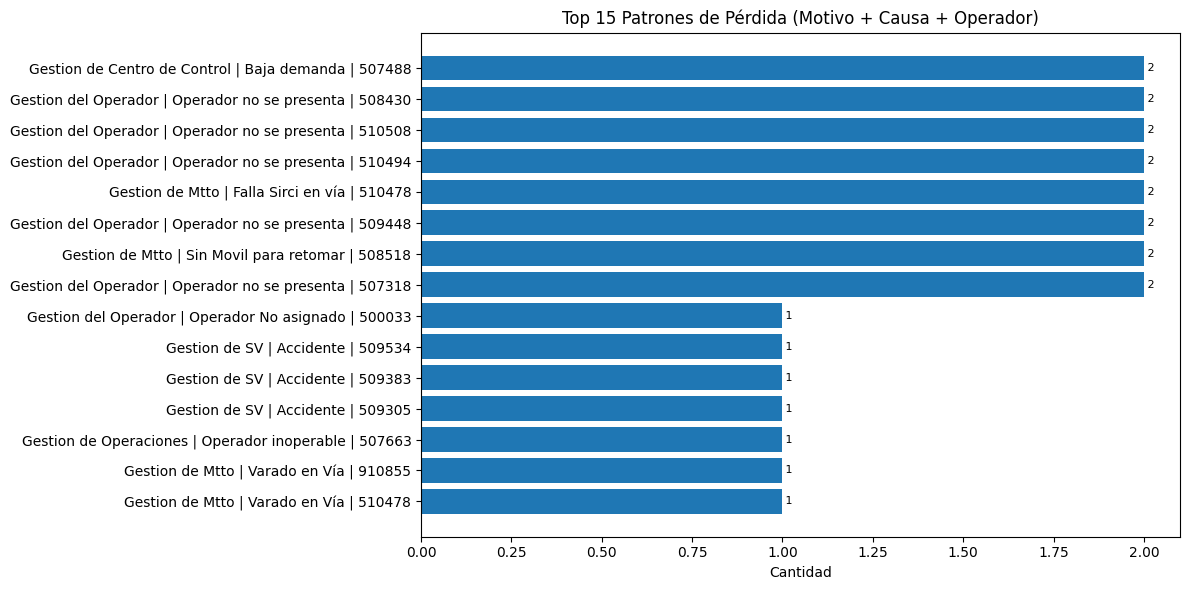

In [72]:
import matplotlib.pyplot as plt

# Tomar los 15 más frecuentes
df_plot = patron_completo.head(15).copy()

# Crear etiqueta combinada
df_plot["patron"] = (
    df_plot["Motivo_perdida"] + " | " +
    df_plot["Causa"] + " | " +
    df_plot["operador_faltante"].astype(str)
)

plt.figure(figsize=(12,6))

plt.barh(df_plot["patron"], df_plot["cantidad"])

plt.xlabel("Cantidad")
plt.title("Top 15 Patrones de Pérdida (Motivo + Causa + Operador)")
plt.gca().invert_yaxis()

# Etiquetas pequeñas
for i, v in enumerate(df_plot["cantidad"]):
    plt.text(v, i, f" {int(v)}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [73]:
patron_completo = (
    casos_criticos
    .groupby(["Fecha","Motivo_perdida", "Causa", "operador_faltante"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

patron_completo.head()

,Fecha,Motivo_perdida,Causa,operador_faltante,cantidad
85,2026-04-09,Gestion del Operador,Operador no se presenta,508430,2
53,2026-04-07,Gestion del Operador,Operador no se presenta,510494,2
66,2026-04-08,Gestion del Operador,Operador no se presenta,509448,2
70,2026-04-08,Gestion del Operador,Operador no se presenta,510508,2
34,2026-04-06,Gestion de Mtto,Sin Movil para retomar,508518,2


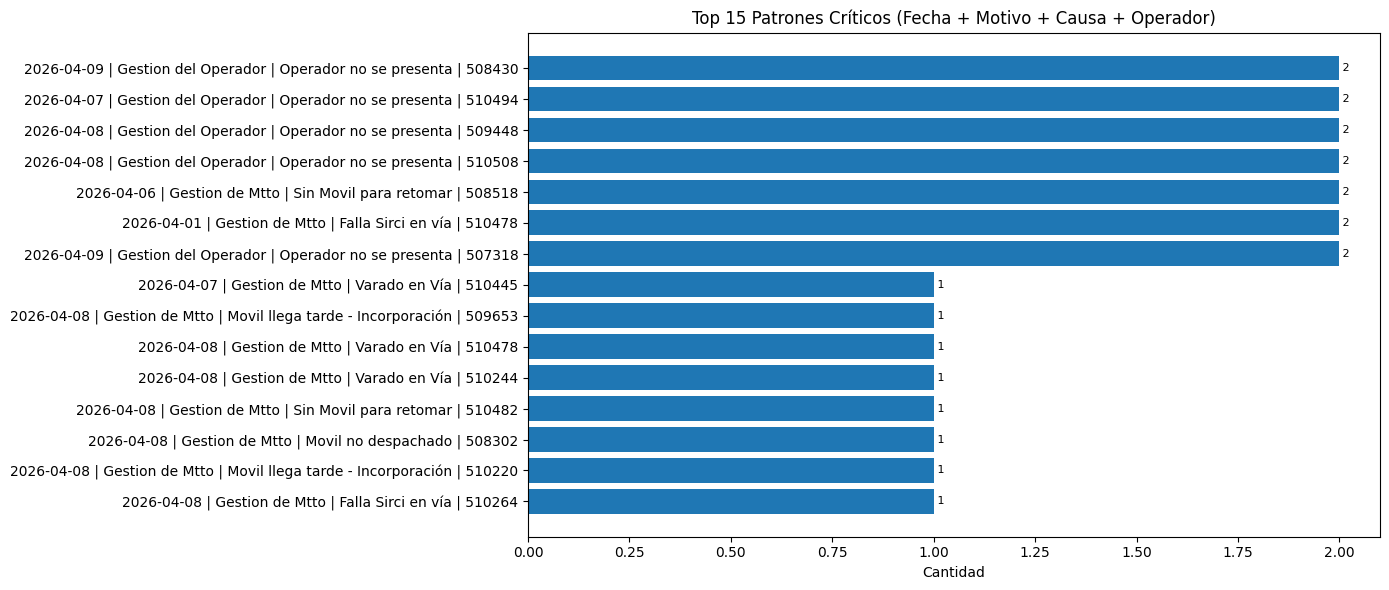

In [74]:
import matplotlib.pyplot as plt

df_plot = patron_completo.head(15).copy()

df_plot["patron"] = (
    df_plot["Fecha"].astype(str) + " | " +
    df_plot["Motivo_perdida"] + " | " +
    df_plot["Causa"] + " | " +
    df_plot["operador_faltante"].astype(str)
)

plt.figure(figsize=(14,6))
plt.barh(df_plot["patron"], df_plot["cantidad"])
plt.gca().invert_yaxis()

for i, v in enumerate(df_plot["cantidad"]):
    plt.text(v, i, f" {int(v)}", va='center', fontsize=8)

plt.xlabel("Cantidad")
plt.title("Top 15 Patrones Críticos (Fecha + Motivo + Causa + Operador)")
plt.tight_layout()
plt.show()

In [75]:
tasa_falla_cubiertos = (
    casos_criticos.shape[0] /
    bitacora[bitacora["cubierto_bin"] == 1].shape[0]
) * 100

print(tasa_falla_cubiertos)

3.4740381023533806


In [76]:
tabla_estado_op = (
    bitacora
    .groupby("estado_op")
    .agg(
        total_servicios=("estado_op", "count"),
        perdidos=("estado_perdido", "sum")
    )
)

tabla_estado_op["%_perdidos"] = (
    tabla_estado_op["perdidos"] /
    tabla_estado_op["total_servicios"] * 100
)

tabla_estado_op.head()

,total_servicios,perdidos,%_perdidos
estado_op,,,
0,29062,1234,4.246095
1,258,127,49.224806


In [77]:
import matplotlib.pyplot as plt

# Agrupar por Ruta (sumando todas las fechas)
df_ruta = (
    analisis_final
    .groupby("Ruta")[
        [
            "cubiertos_normales",
            "perdidos_normales",
            "cubiertos_no_asignados",
            "perdidos_no_asignados"
        ]
    ]
    .sum()
    .reset_index()
)

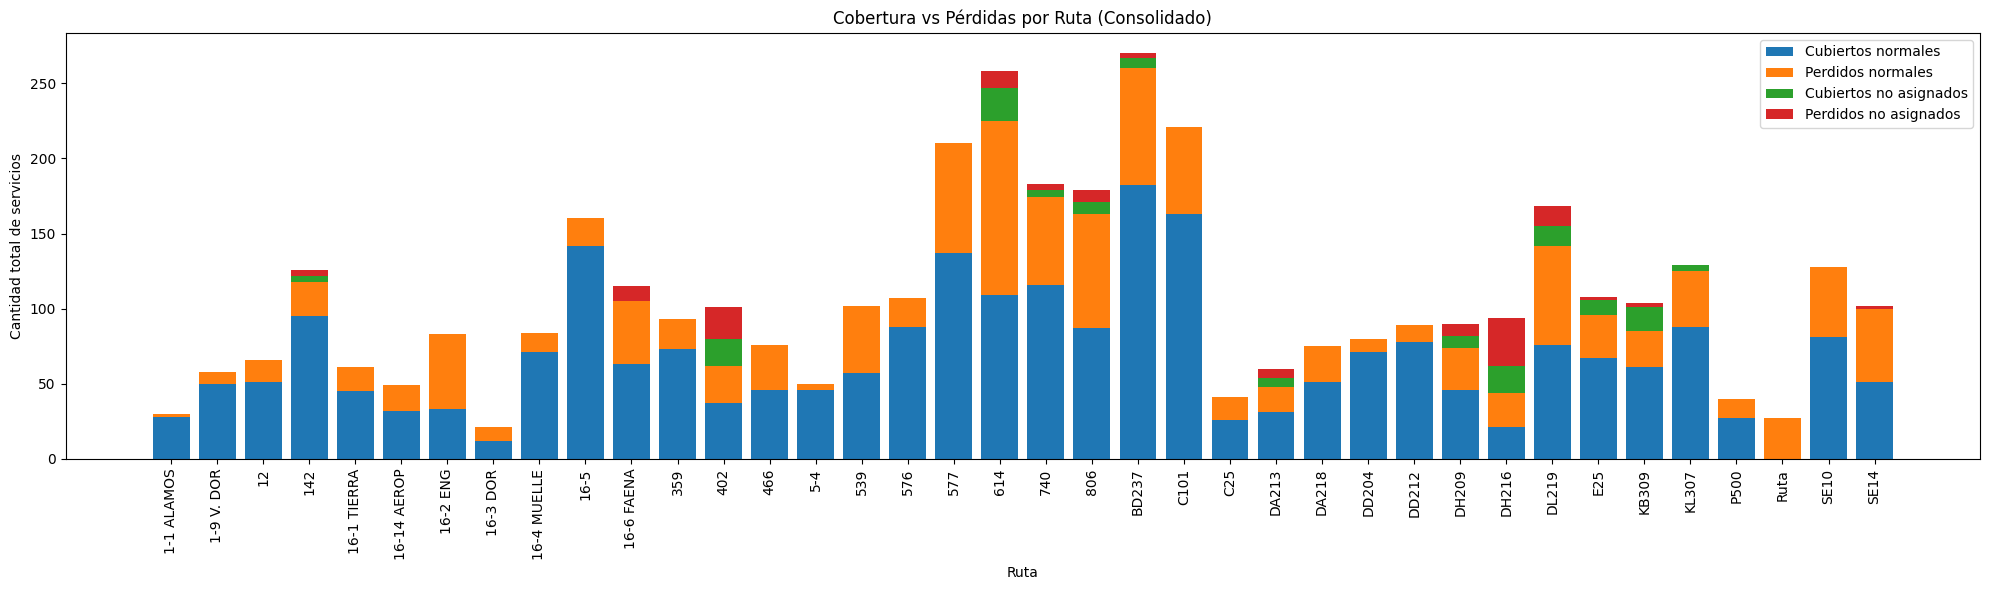

In [78]:
x = range(len(df_ruta))

plt.figure(figsize=(20,6))

plt.bar(x, df_ruta["cubiertos_normales"], label="Cubiertos normales")

plt.bar(
    x,
    df_ruta["perdidos_normales"],
    bottom=df_ruta["cubiertos_normales"],
    label="Perdidos normales"
)

plt.bar(
    x,
    df_ruta["cubiertos_no_asignados"],
    bottom=df_ruta["cubiertos_normales"] + df_ruta["perdidos_normales"],
    label="Cubiertos no asignados"
)

plt.bar(
    x,
    df_ruta["perdidos_no_asignados"],
    bottom=(
        df_ruta["cubiertos_normales"]
        + df_ruta["perdidos_normales"]
        + df_ruta["cubiertos_no_asignados"]
    ),
    label="Perdidos no asignados"
)

plt.xticks(x, df_ruta["Ruta"], rotation=90)
plt.xlabel("Ruta")
plt.ylabel("Cantidad total de servicios")
plt.title("Cobertura vs Pérdidas por Ruta (Consolidado)")
plt.legend()
plt.tight_layout()
plt.show()

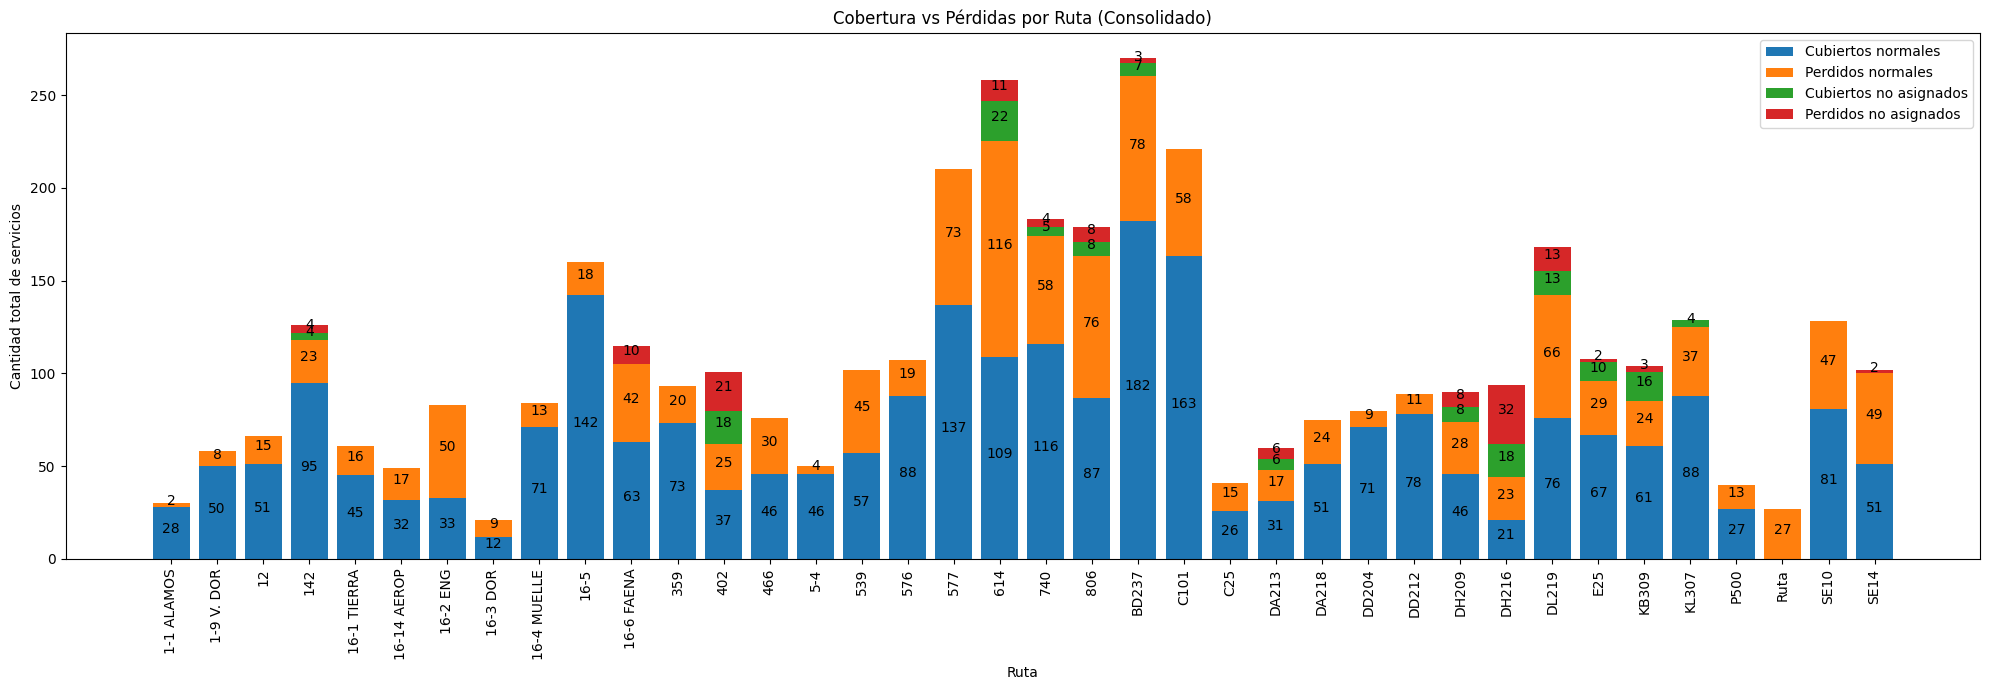

In [79]:
import matplotlib.pyplot as plt

# Agrupar por Ruta
df_ruta = (
    analisis_final
    .groupby("Ruta")[
        [
            "cubiertos_normales",
            "perdidos_normales",
            "cubiertos_no_asignados",
            "perdidos_no_asignados"
        ]
    ]
    .sum()
    .reset_index()
)

x = range(len(df_ruta))

plt.figure(figsize=(20,7))

# Barras
b1 = plt.bar(x, df_ruta["cubiertos_normales"], label="Cubiertos normales")
b2 = plt.bar(
    x,
    df_ruta["perdidos_normales"],
    bottom=df_ruta["cubiertos_normales"],
    label="Perdidos normales"
)
b3 = plt.bar(
    x,
    df_ruta["cubiertos_no_asignados"],
    bottom=df_ruta["cubiertos_normales"] + df_ruta["perdidos_normales"],
    label="Cubiertos no asignados"
)
b4 = plt.bar(
    x,
    df_ruta["perdidos_no_asignados"],
    bottom=(
        df_ruta["cubiertos_normales"]
        + df_ruta["perdidos_normales"]
        + df_ruta["cubiertos_no_asignados"]
    ),
    label="Perdidos no asignados"
)

# 🔢 Agregar etiquetas
for i in range(len(df_ruta)):
    # Cubiertos normales
    if df_ruta["cubiertos_normales"][i] > 0:
        plt.text(i, df_ruta["cubiertos_normales"][i] / 2,
                 int(df_ruta["cubiertos_normales"][i]),
                 ha='center')

    # Perdidos normales
    if df_ruta["perdidos_normales"][i] > 0:
        plt.text(
            i,
            df_ruta["cubiertos_normales"][i] + df_ruta["perdidos_normales"][i] / 2,
            int(df_ruta["perdidos_normales"][i]),
            ha='center'
        )

    # Cubiertos no asignados
    if df_ruta["cubiertos_no_asignados"][i] > 0:
        plt.text(
            i,
            df_ruta["cubiertos_normales"][i]
            + df_ruta["perdidos_normales"][i]
            + df_ruta["cubiertos_no_asignados"][i] / 2,
            int(df_ruta["cubiertos_no_asignados"][i]),
            ha='center'
        )

    # Perdidos no asignados
    if df_ruta["perdidos_no_asignados"][i] > 0:
        plt.text(
            i,
            df_ruta["cubiertos_normales"][i]
            + df_ruta["perdidos_normales"][i]
            + df_ruta["cubiertos_no_asignados"][i]
            + df_ruta["perdidos_no_asignados"][i] / 2,
            int(df_ruta["perdidos_no_asignados"][i]),
            ha='center'
        )

plt.xticks(x, df_ruta["Ruta"], rotation=90)
plt.xlabel("Ruta")
plt.ylabel("Cantidad total de servicios")
plt.title("Cobertura vs Pérdidas por Ruta (Consolidado)")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
ruta_165 = (
    bitacora
    [bitacora["Ruta"] == "16-5"]
    .groupby(["Fecha", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["Fecha", "cantidad"], ascending=[True, False])
)

ruta_165

,Fecha,Motivo_perdida,cantidad
0,2026-04-01,Gestion de Mtto,1
1,2026-04-01,Gestion del Operador,1
2,2026-04-05,Gestion de Mtto,1
3,2026-04-05,Gestion del Operador,1
5,2026-04-06,Gestion de Mtto,4
6,2026-04-06,Gestion del Operador,3
4,2026-04-06,Gestion de Centro de Control,1
7,2026-04-07,Gestion de Mtto,2
8,2026-04-07,Gestion del Operador,1
9,2026-04-08,Gestion de Mtto,1


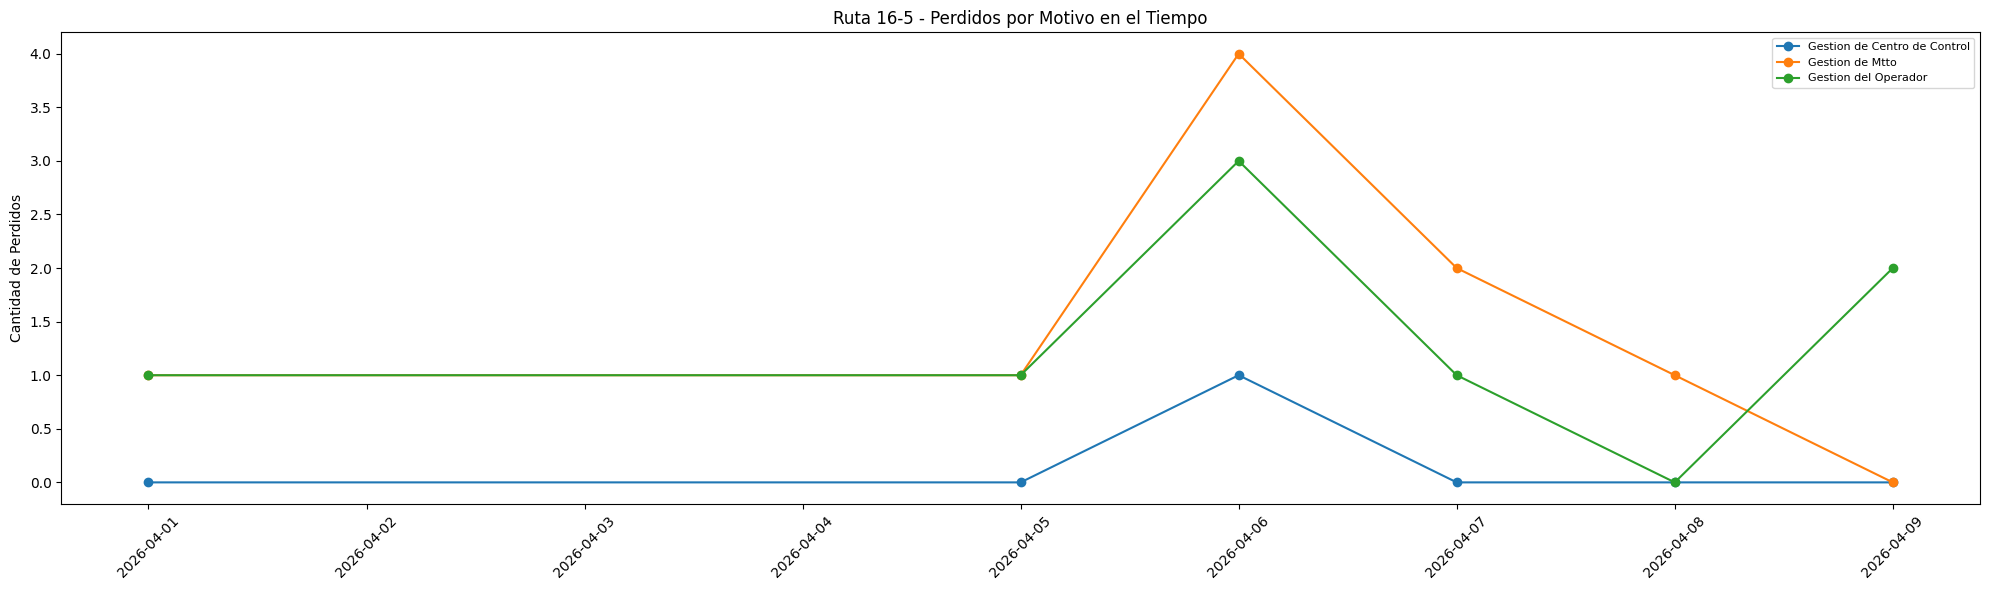

In [81]:
import matplotlib.pyplot as plt

# Convertir a formato pivote
df_plot = (
    ruta_165
    .pivot(index="Fecha", columns="Motivo_perdida", values="cantidad")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(20,6))

for col in df_plot.columns:
    if df_plot[col].sum() > 0:  # solo mostrar motivos con datos
        plt.plot(df_plot.index, df_plot[col], marker='o', label=col)

plt.xticks(rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Ruta 16-5 - Perdidos por Motivo en el Tiempo")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

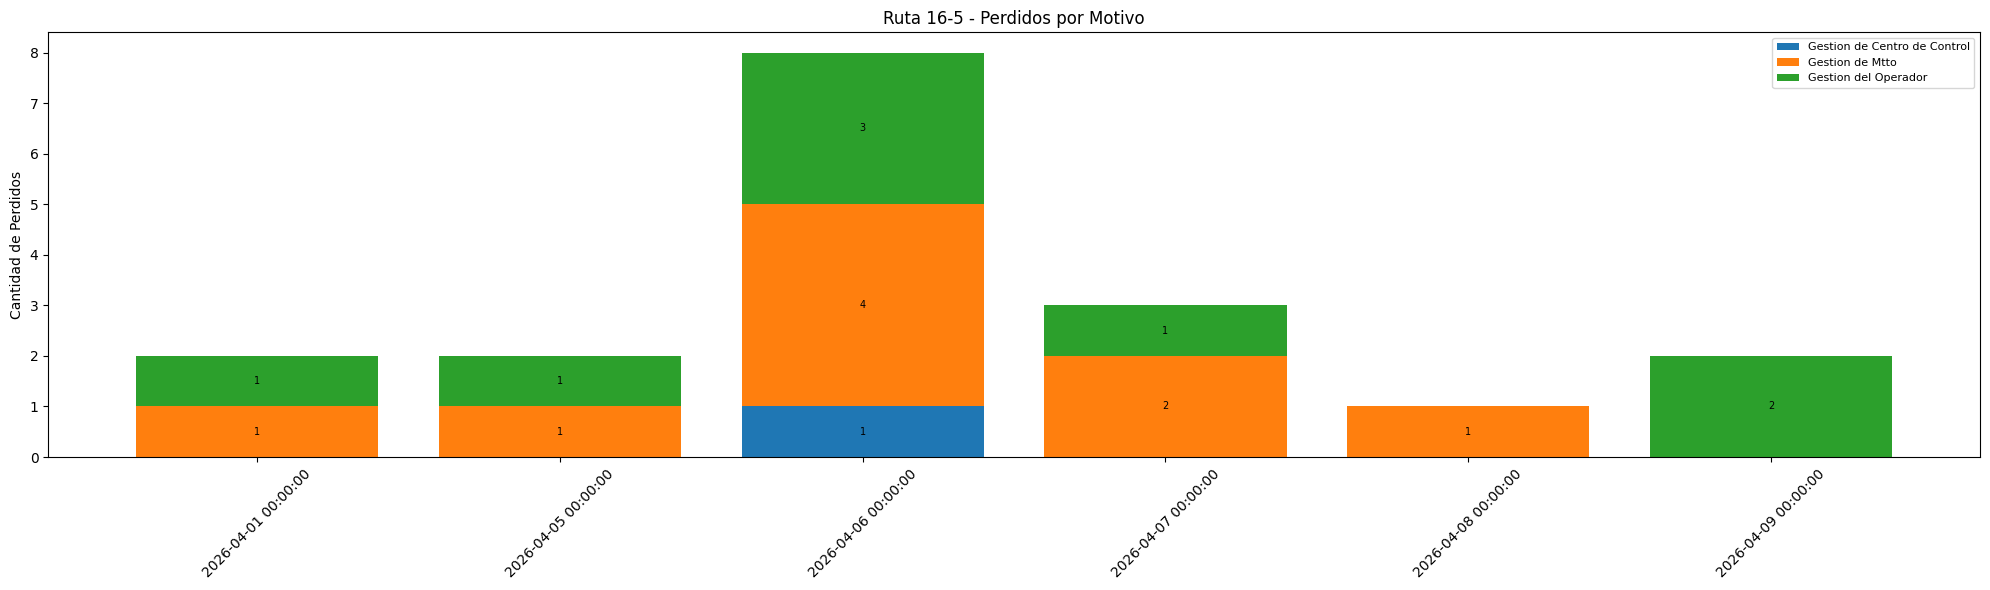

In [82]:
x = np.arange(len(df_plot))
bottom = np.zeros(len(df_plot))

plt.figure(figsize=(20,6))

for col in df_plot.columns:
    valores = df_plot[col].values
    
    # Solo graficar si tiene datos
    if valores.sum() > 0:
        bars = plt.bar(x, valores, bottom=bottom, label=col)
        
        # Etiquetas pequeñas
        for i, (v, btm) in enumerate(zip(valores, bottom)):
            if v > 0:
                plt.text(
                    i,
                    btm + v/2,
                    str(int(v)),
                    ha='center',
                    va='center',
                    fontsize=7
                )
        
        bottom += valores

plt.xticks(x, df_plot.index, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Ruta 16-5 - Perdidos por Motivo")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [84]:
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

In [85]:
df_motivos = (
    df_perdidos
    .groupby(["Ruta","estado_op", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["estado_op", "cantidad"], ascending=[True, False])
)

df_motivos.head(20)

,Ruta,estado_op,Motivo_perdida,cantidad
55,614,0,Gestion del Operador,65
71,BD237,0,Gestion del Operador,55
53,614,0,Gestion de Mtto,46
17,16-2 ENG,0,Gestion de Mtto,42
102,DL219,0,Gestion del Operador,41
67,806,0,Gestion del Operador,40
51,577,0,Gestion del Operador,37
26,16-6 FAENA,0,Gestion de Mtto,33
123,SE10,0,Gestion del Operador,33
127,SE14,0,Gestion del Operador,33


In [86]:
motivos_normales = df_motivos[df_motivos["estado_op"] == 0]
motivos_normales

,Ruta,estado_op,Motivo_perdida,cantidad
55,614,0,Gestion del Operador,65
71,BD237,0,Gestion del Operador,55
53,614,0,Gestion de Mtto,46
17,16-2 ENG,0,Gestion de Mtto,42
102,DL219,0,Gestion del Operador,41
...,...,...,...,...
115,KL307,0,Gestion de SV,1
120,SE10,0,Gestion de Centro de Control,1
122,SE10,0,Gestion de SV,1
124,SE14,0,Gestion de Centro de Control,1


In [87]:
motivos_no_asignados = df_motivos[df_motivos["estado_op"] == 1]
motivos_no_asignados

,Ruta,estado_op,Motivo_perdida,cantidad
98,DH216,1,Gestion del Operador,31
33,402,1,Gestion del Operador,21
103,DL219,1,Gestion del Operador,12
28,16-6 FAENA,1,Gestion de Mtto,10
57,614,1,Gestion del Operador,8
68,806,1,Gestion del Operador,8
92,DH209,1,Gestion del Operador,8
81,DA213,1,Gestion del Operador,6
11,142,1,Gestion del Operador,4
62,740,1,Gestion del Operador,4


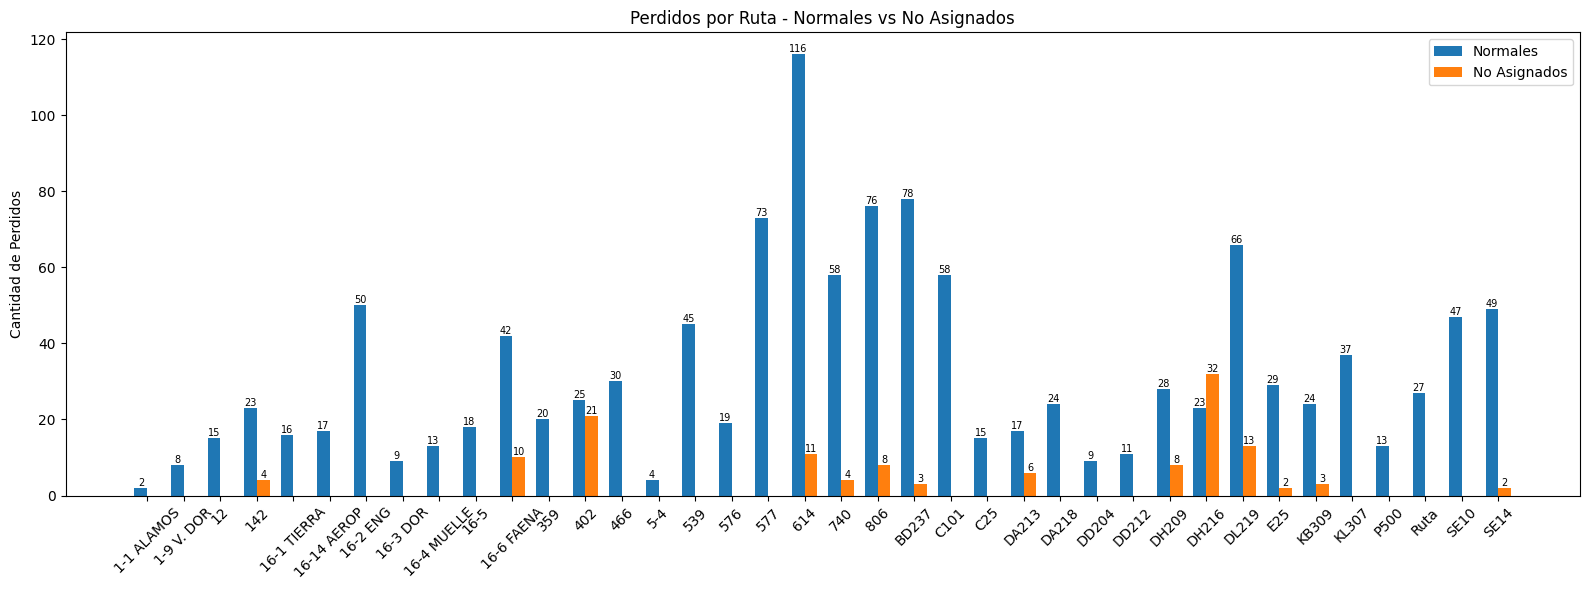

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar solo perdidos reales
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

# Agrupar por Ruta y estado_op
df_plot = (
    df_perdidos
    .groupby(["Ruta", "estado_op"])
    .size()
    .reset_index(name="cantidad")
    .pivot(index="Ruta", columns="estado_op", values="cantidad")
    .fillna(0)
)

# Renombrar columnas
df_plot.columns = ["Normales", "No Asignados"]

x = np.arange(len(df_plot))
width = 0.35  # ancho de barra

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, df_plot["Normales"], width, label="Normales")
bars2 = plt.bar(x + width/2, df_plot["No Asignados"], width, label="No Asignados")

# Etiquetas pequeñas
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=7
            )

plt.xticks(x, df_plot.index, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Perdidos por Ruta - Normales vs No Asignados")
plt.legend()
plt.tight_layout()
plt.show()

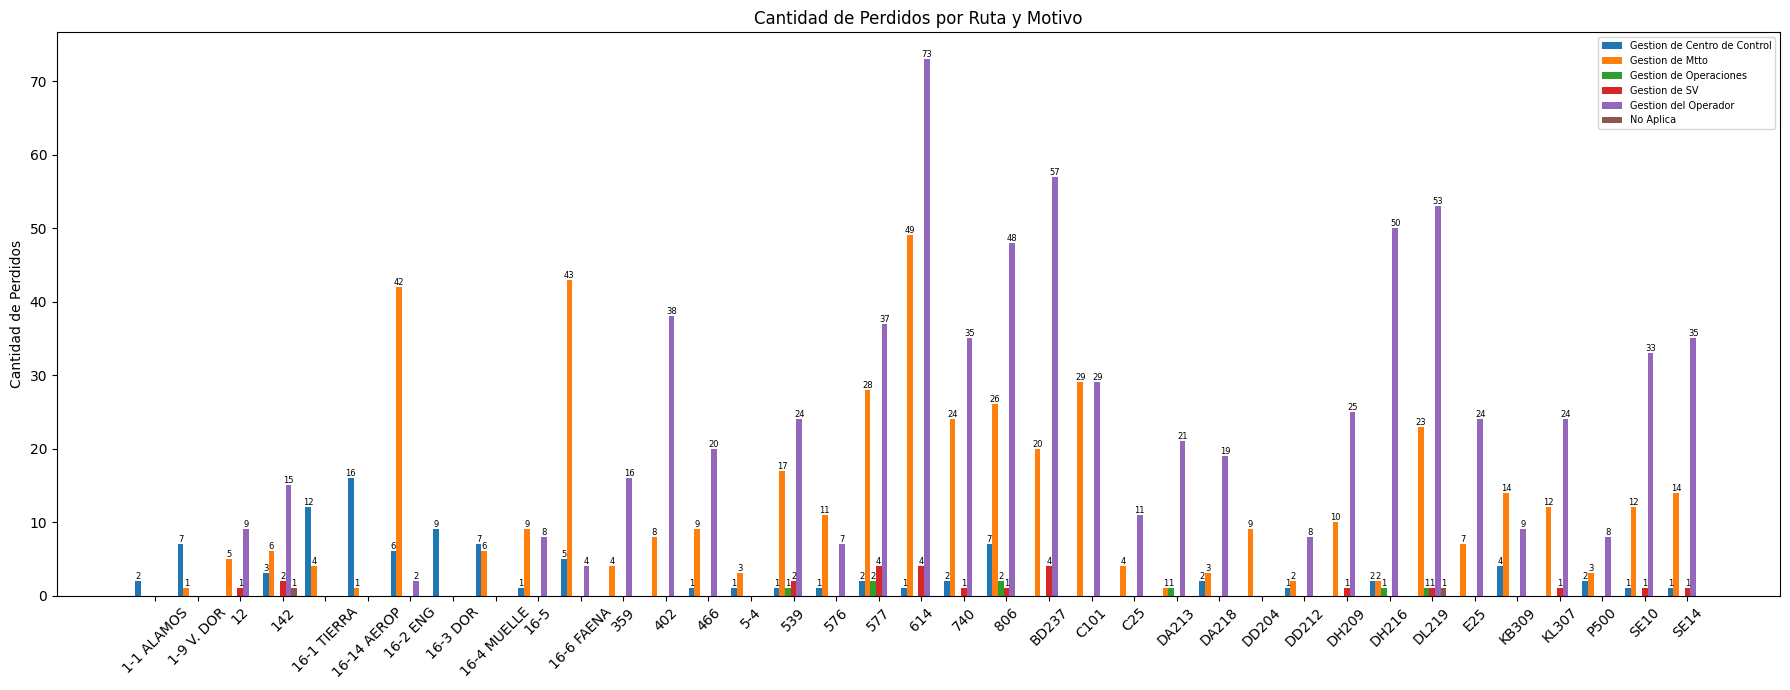

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrar solo perdidos reales
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

# 2️⃣ Agrupar por Ruta y Motivo
df_plot = (
    df_perdidos
    .groupby(["Ruta", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .pivot(index="Ruta", columns="Motivo_perdida", values="cantidad")
    .fillna(0)
)

rutas = df_plot.index
motivos = df_plot.columns

x = np.arange(len(rutas))
width = 0.8 / len(motivos)  # ancho dinámico según cantidad de motivos

plt.figure(figsize=(18,7))

for i, motivo in enumerate(motivos):
    valores = df_plot[motivo].values
    
    bars = plt.bar(
        x - 0.4 + i * width,
        valores,
        width,
        label=motivo
    )
    
    # Etiquetas pequeñas
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=6
            )

plt.xticks(x, rutas, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Cantidad de Perdidos por Ruta y Motivo")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

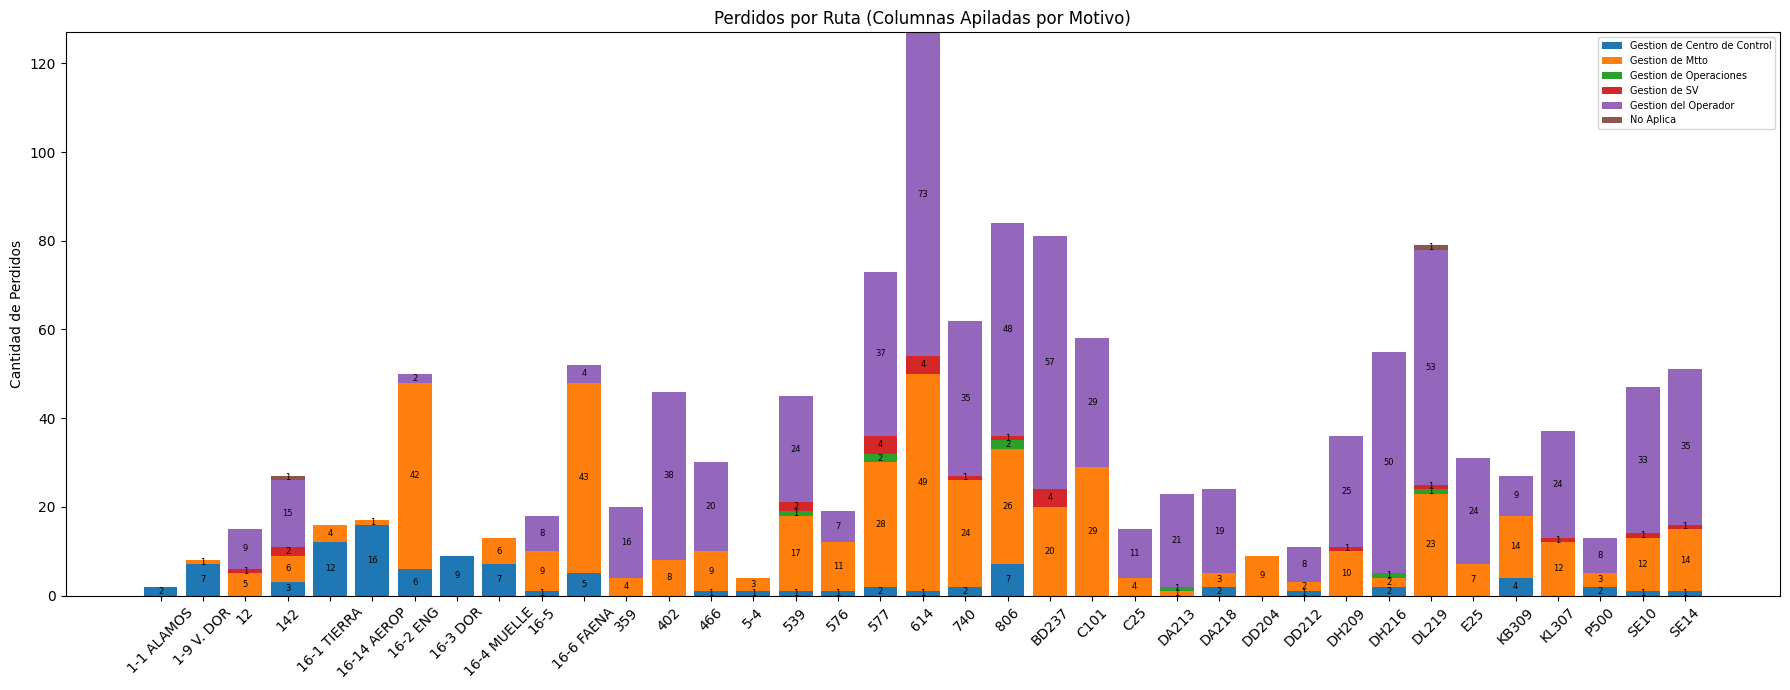

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrar solo perdidos reales
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

# 2️⃣ Agrupar por Ruta y Motivo
df_plot = (
    df_perdidos
    .groupby(["Ruta", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .pivot(index="Ruta", columns="Motivo_perdida", values="cantidad")
    .fillna(0)
)

rutas = df_plot.index
motivos = df_plot.columns

x = np.arange(len(rutas))
bottom = np.zeros(len(rutas))

plt.figure(figsize=(18,7))

for motivo in motivos:
    valores = df_plot[motivo].values
    
    bars = plt.bar(x, valores, bottom=bottom, label=motivo)
    
    # Etiquetas pequeñas centradas
    for i, (v, btm) in enumerate(zip(valores, bottom)):
        if v > 0:
            plt.text(
                i,
                btm + v/2,
                str(int(v)),
                ha='center',
                va='center',
                fontsize=6
            )
    
    bottom += valores

plt.xticks(x, rutas, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Perdidos por Ruta (Columnas Apiladas por Motivo)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

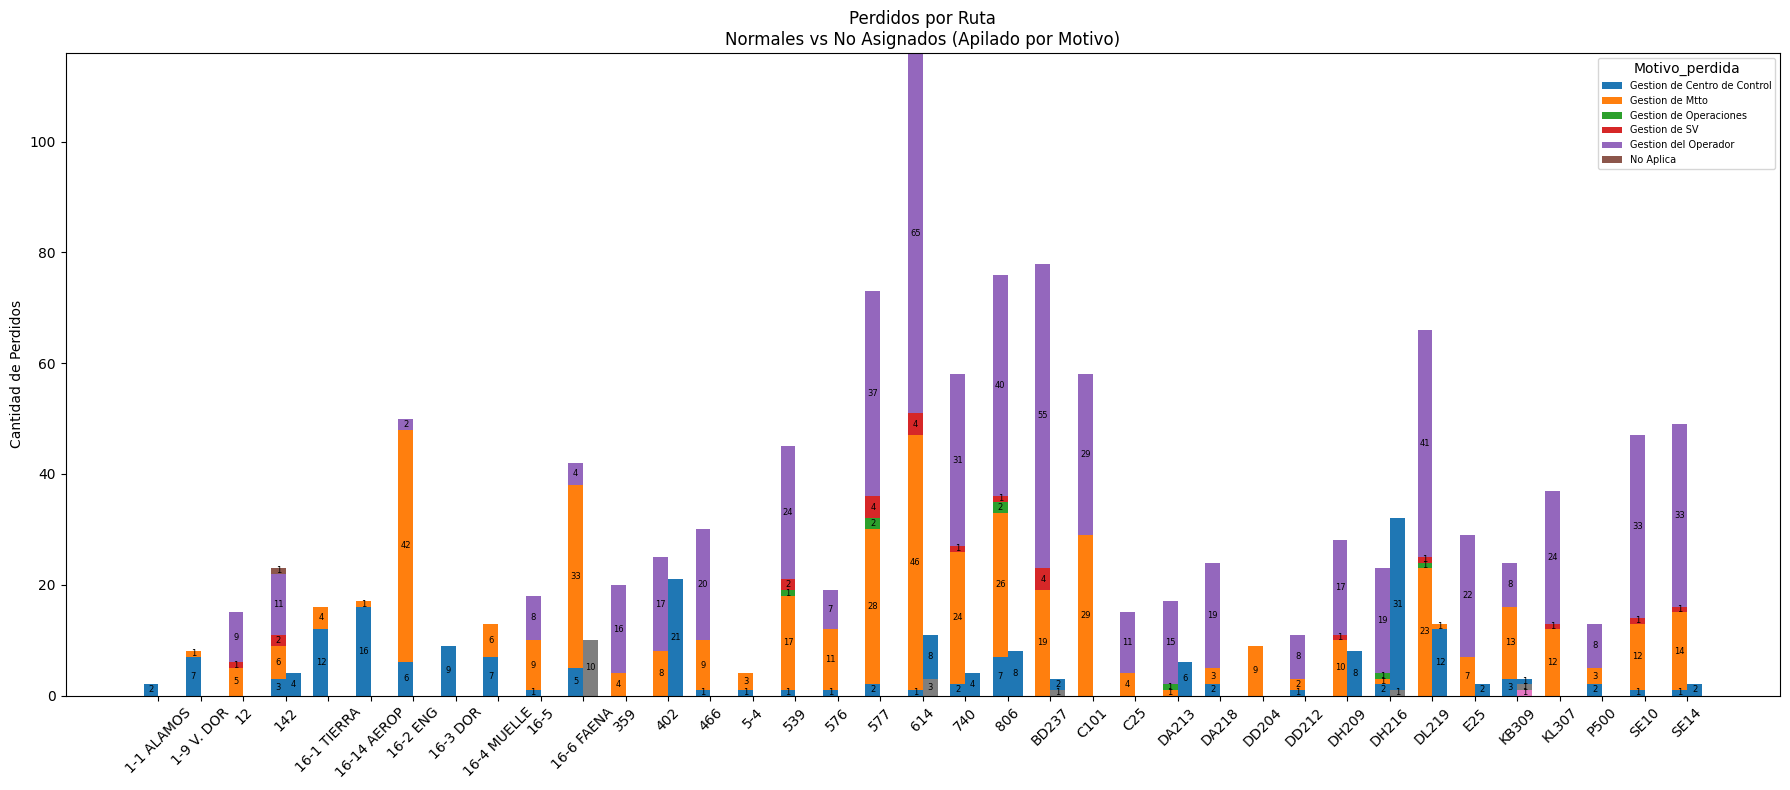

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrar solo perdidos reales
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

# 2️⃣ Agrupar por Ruta, estado_op y Motivo
df_plot = (
    df_perdidos
    .groupby(["Ruta", "estado_op", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .pivot_table(
        index=["Ruta", "estado_op"],
        columns="Motivo_perdida",
        values="cantidad",
        fill_value=0
    )
)

rutas = df_plot.index.get_level_values("Ruta").unique()
motivos = df_plot.columns

x = np.arange(len(rutas))
width = 0.35

plt.figure(figsize=(18,8))

for j, estado in enumerate([0, 1]):
    
    bottom = np.zeros(len(rutas))
    
    for motivo in motivos:
        valores = []
        
        for ruta in rutas:
            if (ruta, estado) in df_plot.index:
                valores.append(df_plot.loc[(ruta, estado), motivo])
            else:
                valores.append(0)
        
        valores = np.array(valores)
        
        bars = plt.bar(
            x + (j-0.5)*width,
            valores,
            width,
            bottom=bottom,
            label=f"{motivo}" if j == 0 else ""
        )
        
        # Etiquetas pequeñas
        for i, (v, btm) in enumerate(zip(valores, bottom)):
            if v > 0:
                plt.text(
                    x[i] + (j-0.5)*width,
                    btm + v/2,
                    str(int(v)),
                    ha='center',
                    va='center',
                    fontsize=6
                )
        
        bottom += valores

plt.xticks(x, rutas, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Perdidos por Ruta\nNormales vs No Asignados (Apilado por Motivo)")
plt.legend(title="Motivo_perdida", fontsize=7)
plt.tight_layout()
plt.show()

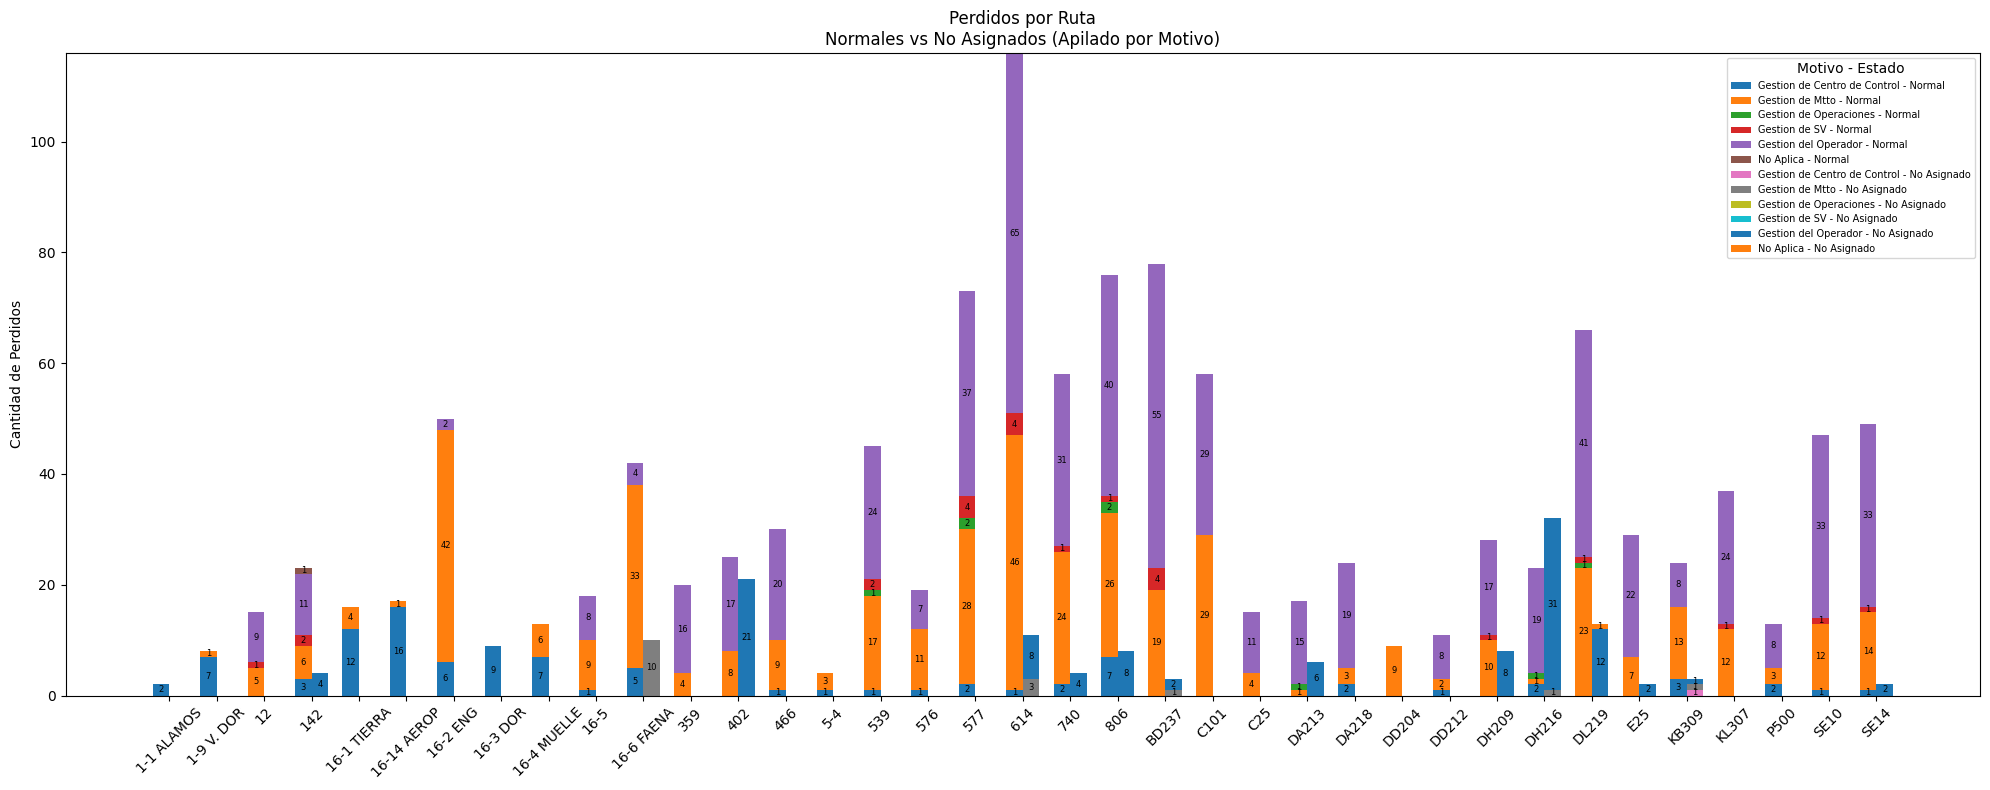

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Filtrar solo los servicios perdidos reales
df_perdidos = bitacora[bitacora["perdido_bin"] == 1].copy()

# 2️⃣ Agrupar por Ruta, estado_op y Motivo
df_plot = (
    df_perdidos
    .groupby(["Ruta", "estado_op", "Motivo_perdida"])
    .size()
    .reset_index(name="cantidad")
    .pivot_table(
        index=["Ruta", "estado_op"],
        columns="Motivo_perdida",
        values="cantidad",
        fill_value=0
    )
)

# 3️⃣ Obtener listas necesarias
rutas = df_plot.index.get_level_values("Ruta").unique()
motivos = df_plot.columns

x = np.arange(len(rutas))
width = 0.35

plt.figure(figsize=(20,8))

# 4️⃣ Crear columnas apiladas (una para Normal y otra para No Asignado)
for j, estado in enumerate([0, 1]):
    
    bottom = np.zeros(len(rutas))
    
    for motivo in motivos:
        
        valores = []
        
        for ruta in rutas:
            if (ruta, estado) in df_plot.index:
                valores.append(df_plot.loc[(ruta, estado), motivo])
            else:
                valores.append(0)
        
        valores = np.array(valores)
        
        bars = plt.bar(
            x + (j - 0.5) * width,
            valores,
            width,
            bottom=bottom,
            label=f"{motivo} - {'Normal' if estado==0 else 'No Asignado'}"
        )
        
        # Etiquetas centradas en cada bloque
        for i, (v, btm) in enumerate(zip(valores, bottom)):
            if v > 0:
                plt.text(
                    x[i] + (j - 0.5) * width,
                    btm + v / 2,
                    str(int(v)),
                    ha='center',
                    va='center',
                    fontsize=6
                )
        
        bottom += valores

# 5️⃣ Ajustes finales
plt.xticks(x, rutas, rotation=45)
plt.ylabel("Cantidad de Perdidos")
plt.title("Perdidos por Ruta\nNormales vs No Asignados (Apilado por Motivo)")
plt.legend(title="Motivo - Estado", fontsize=7)
plt.tight_layout()
plt.show()

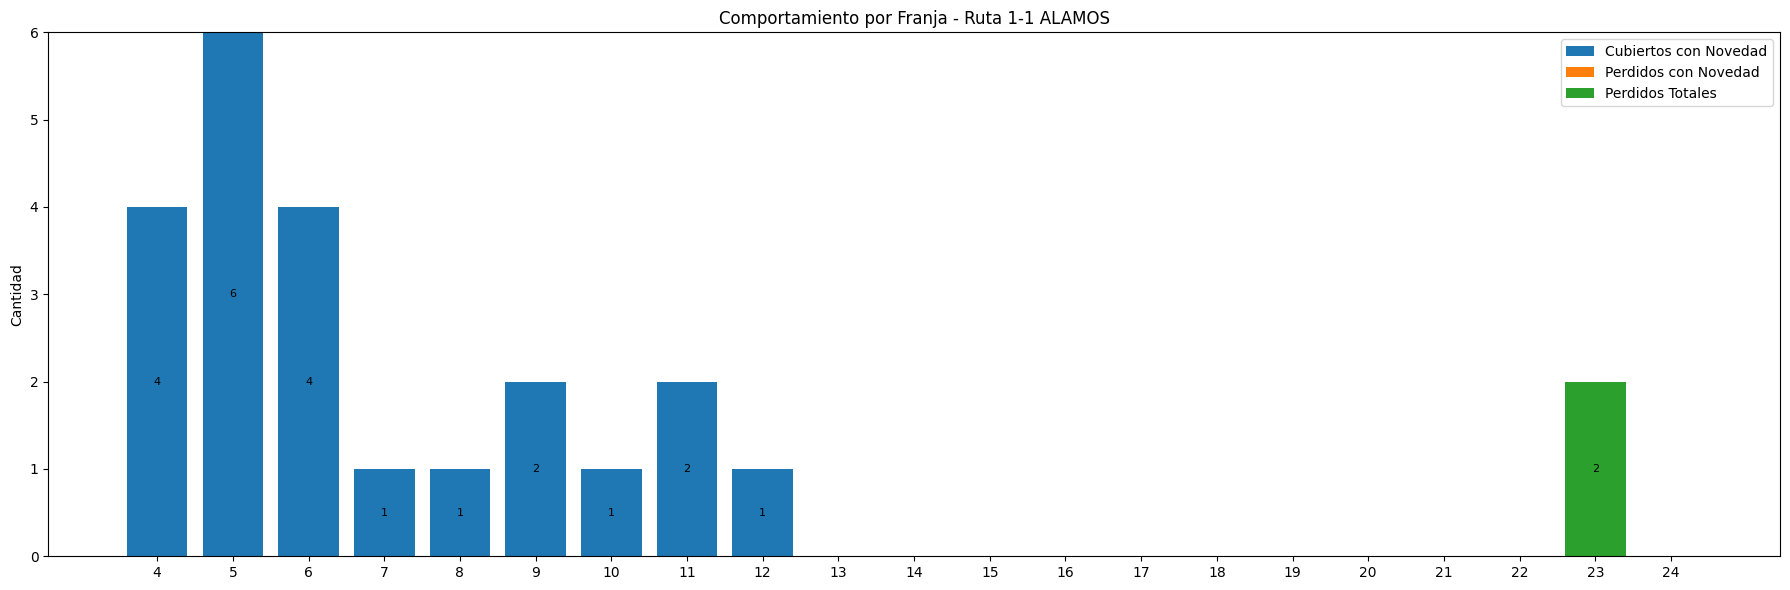

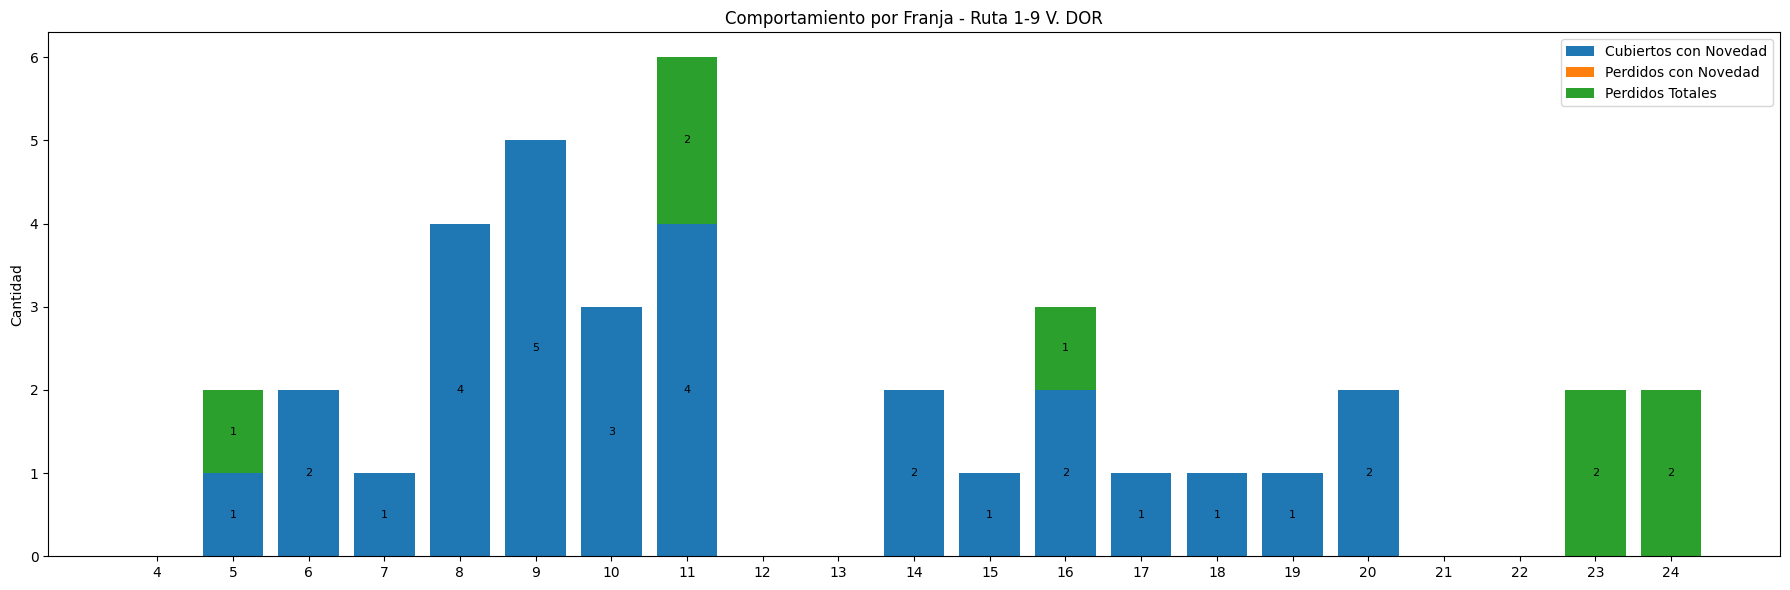

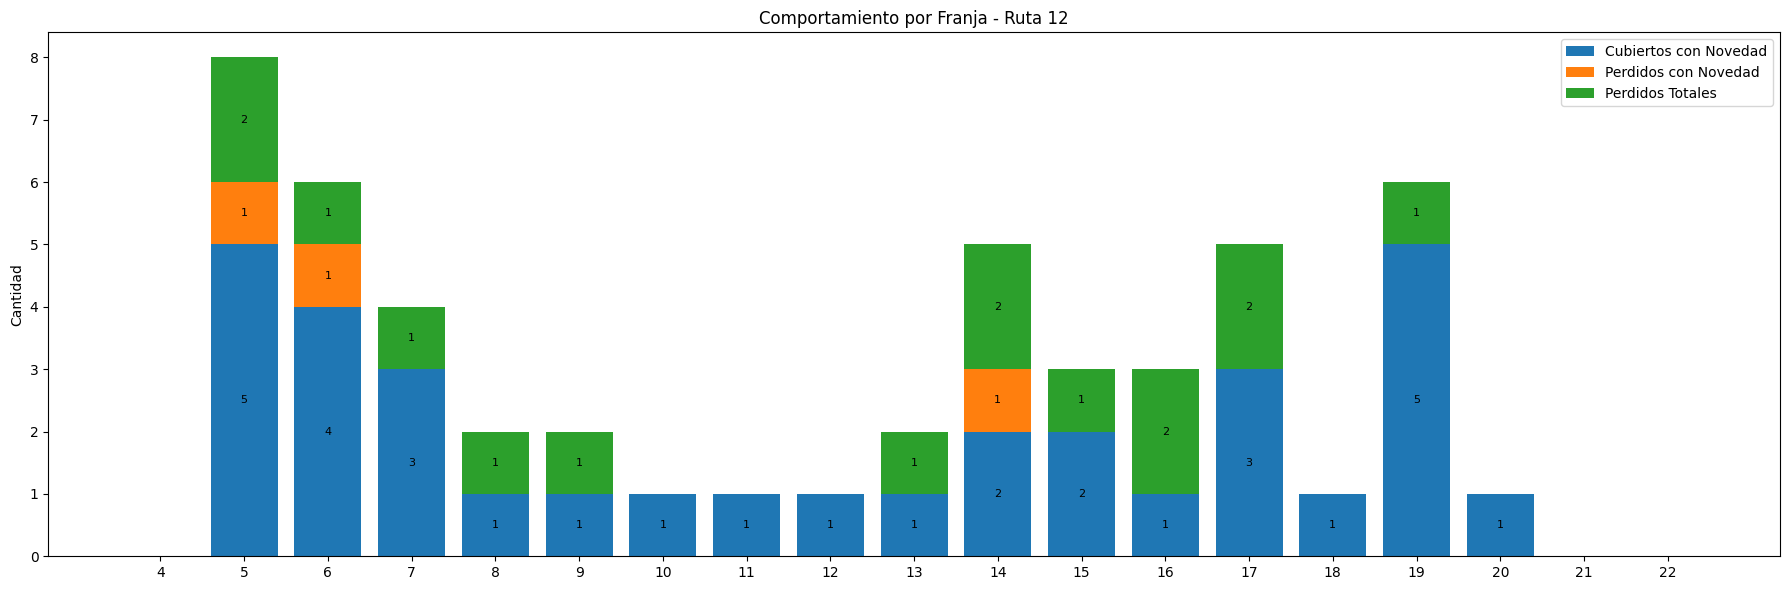

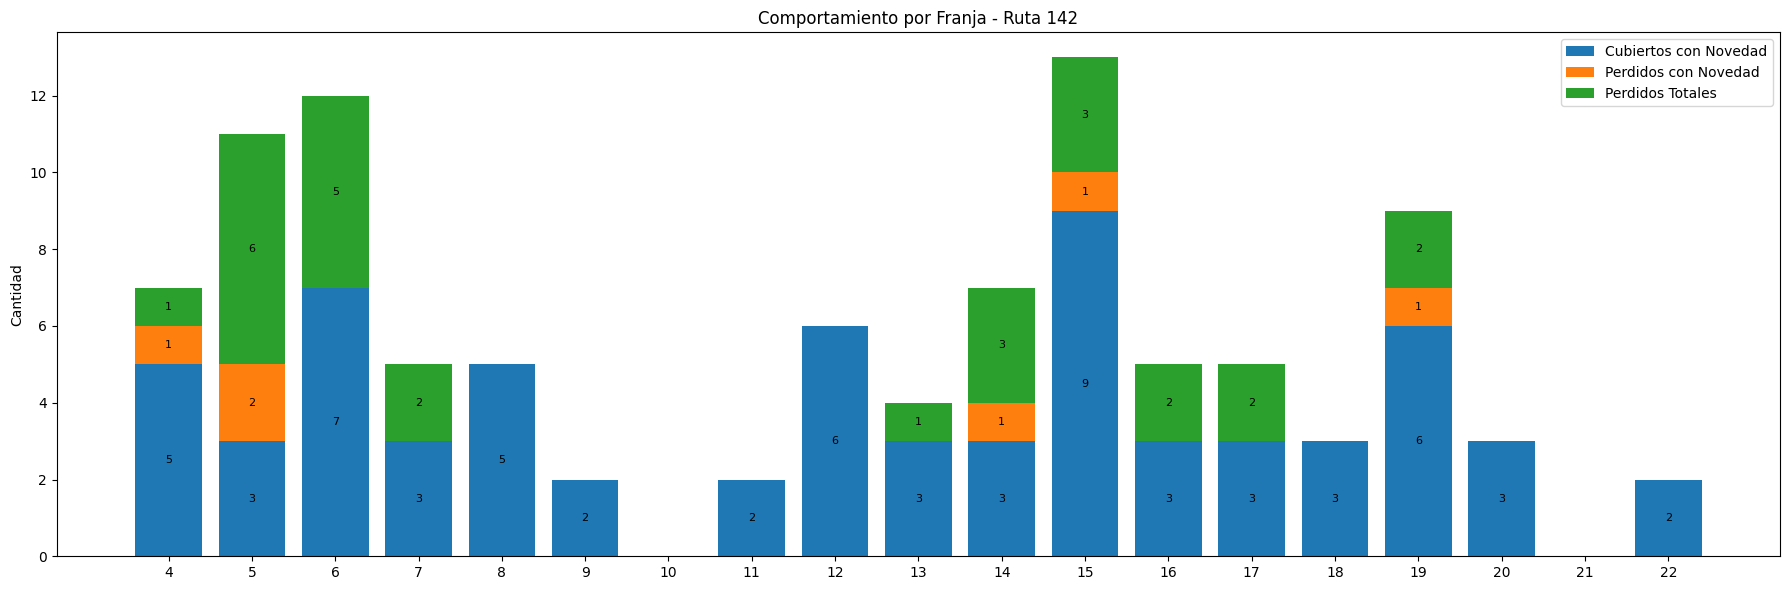

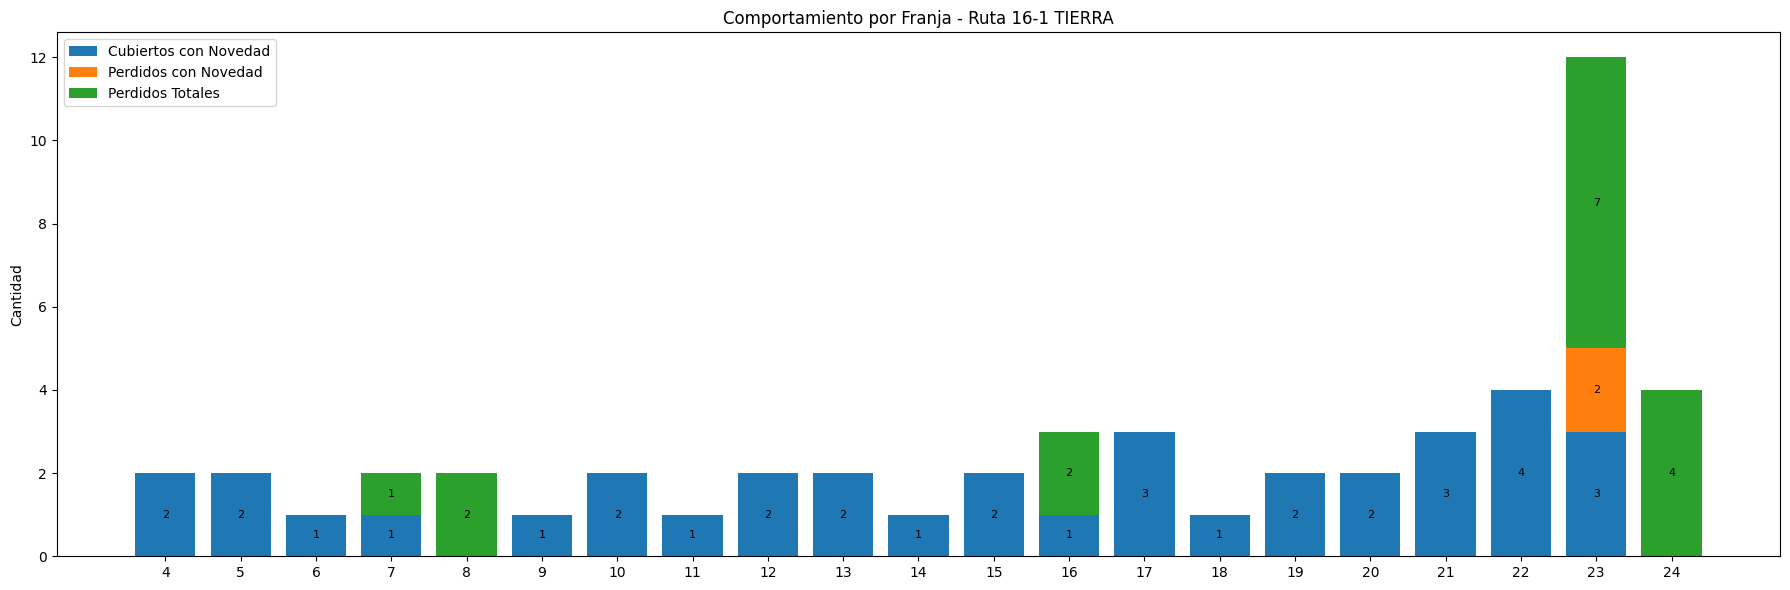

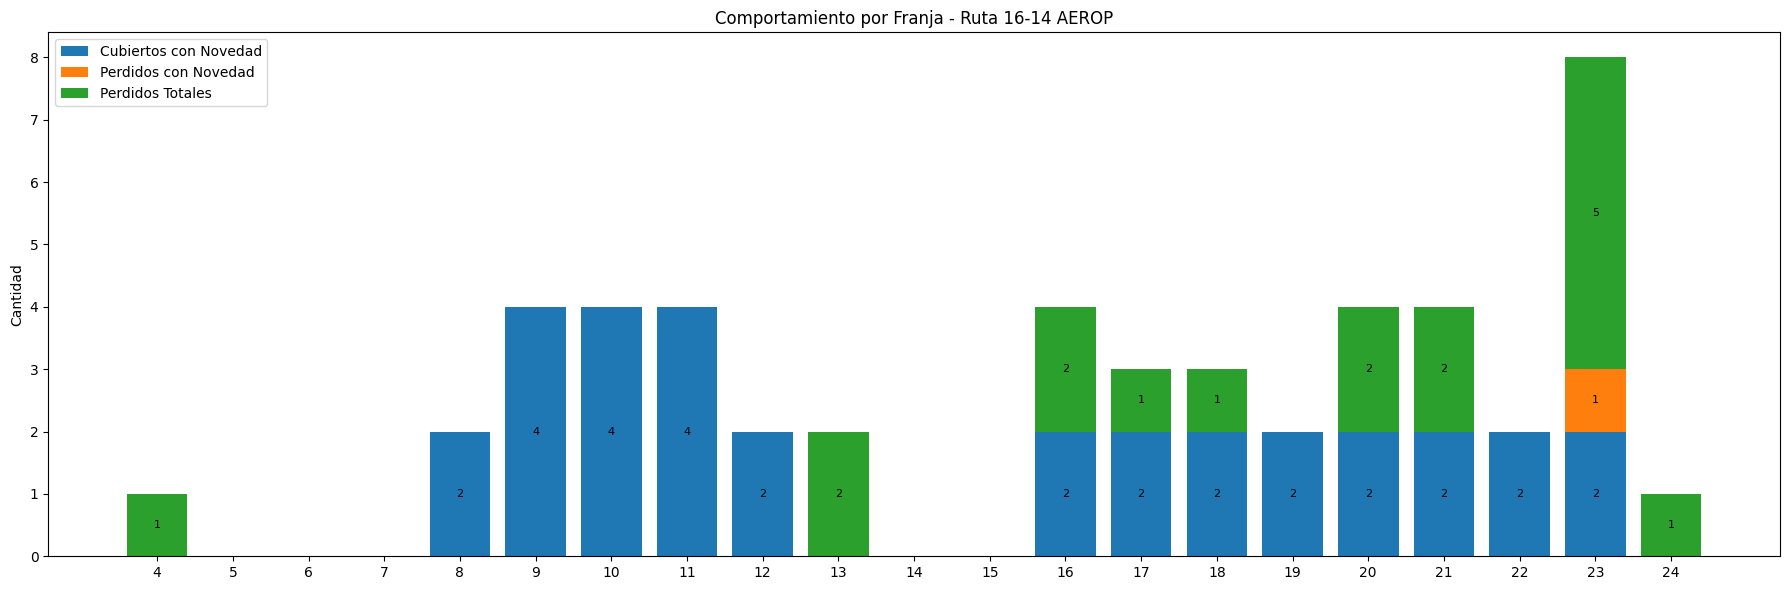

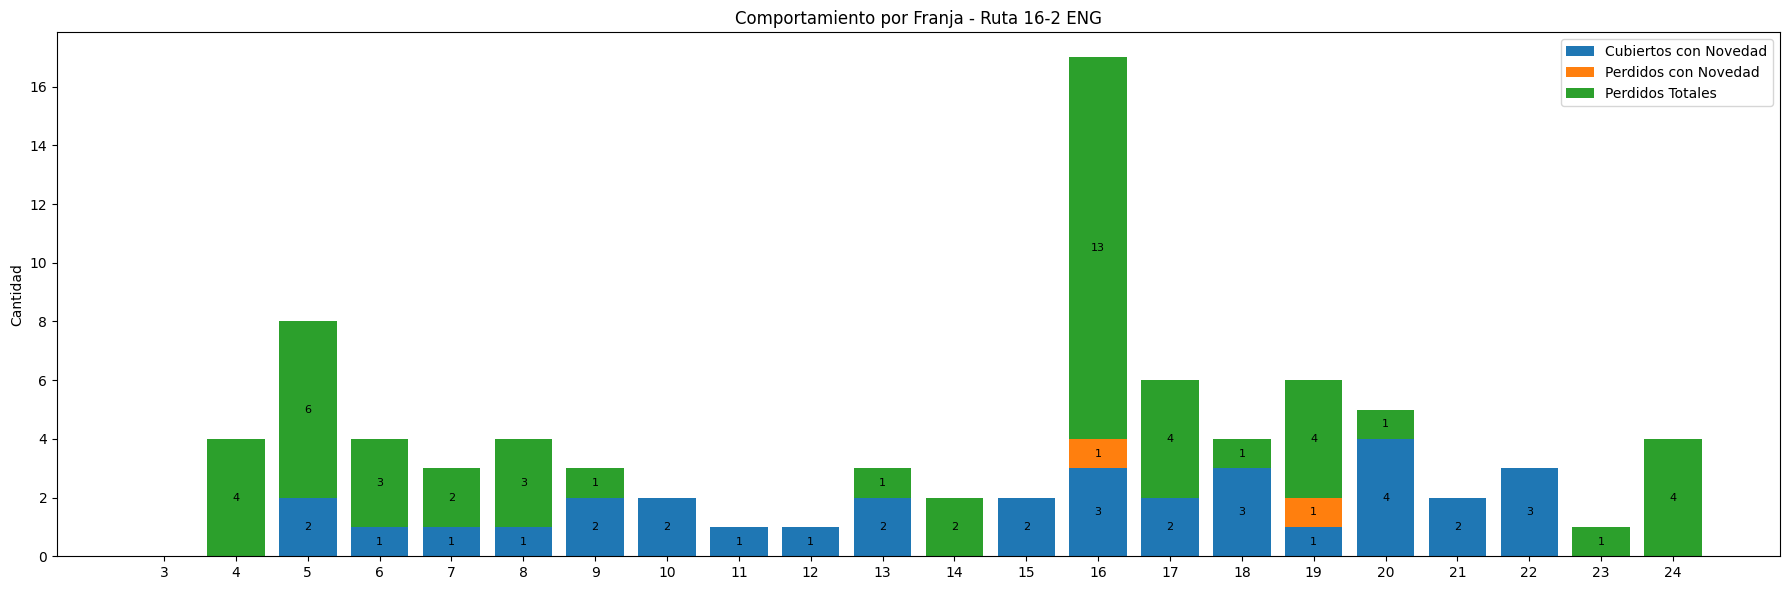

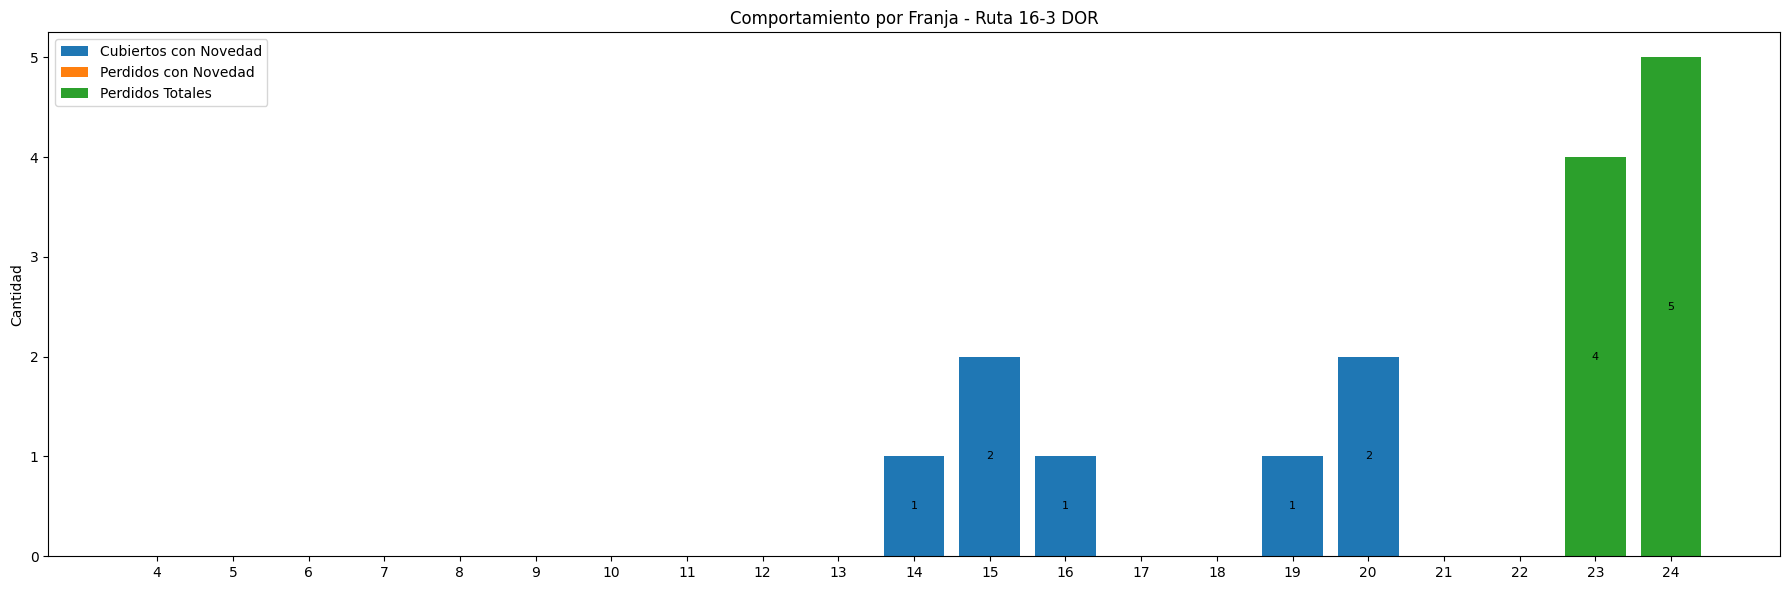

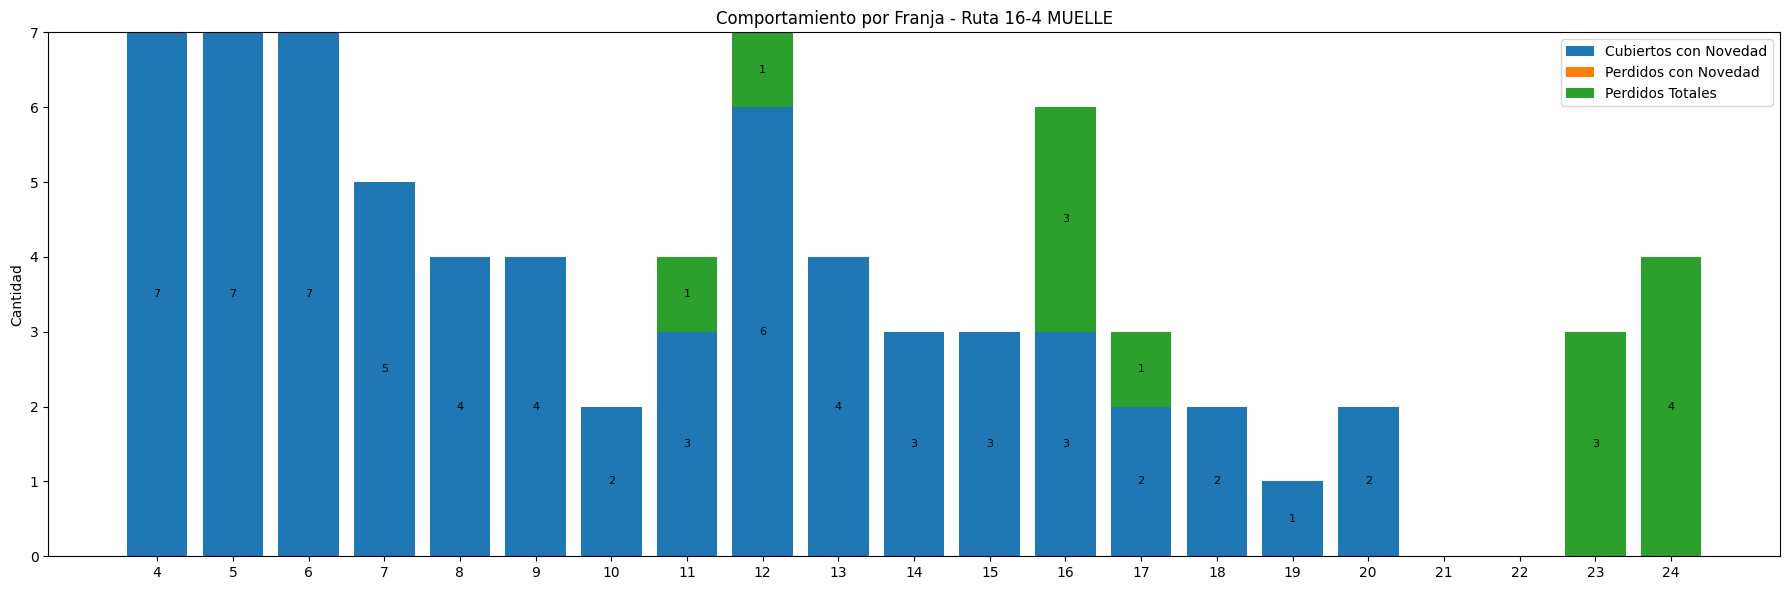

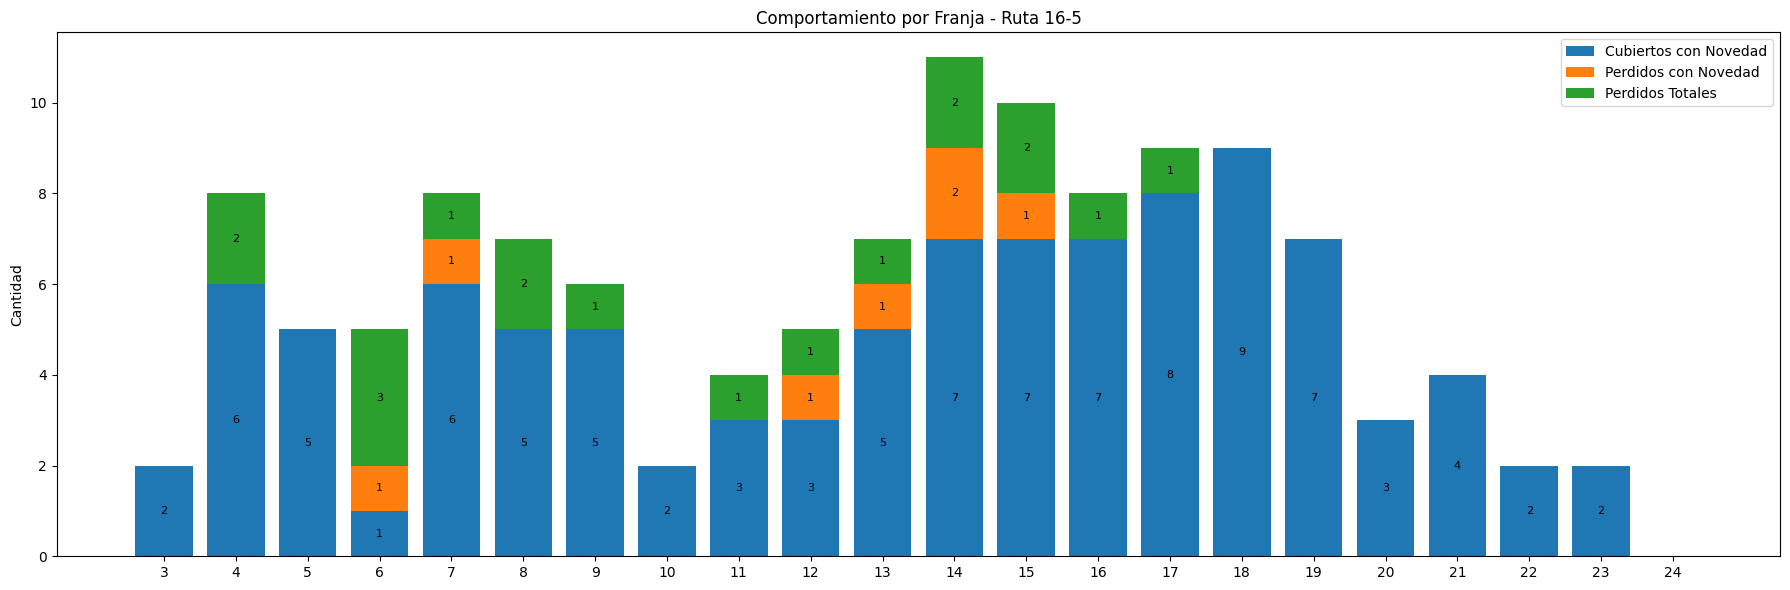

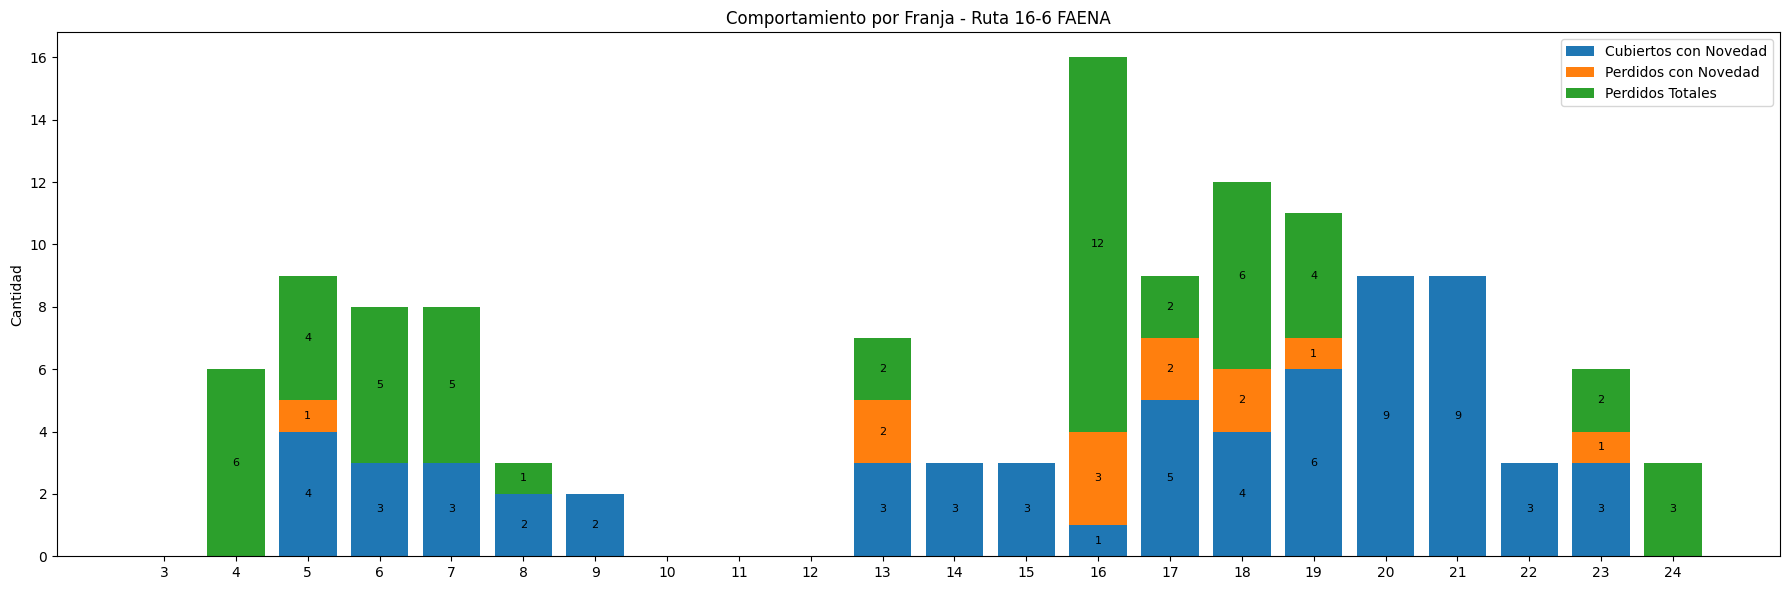

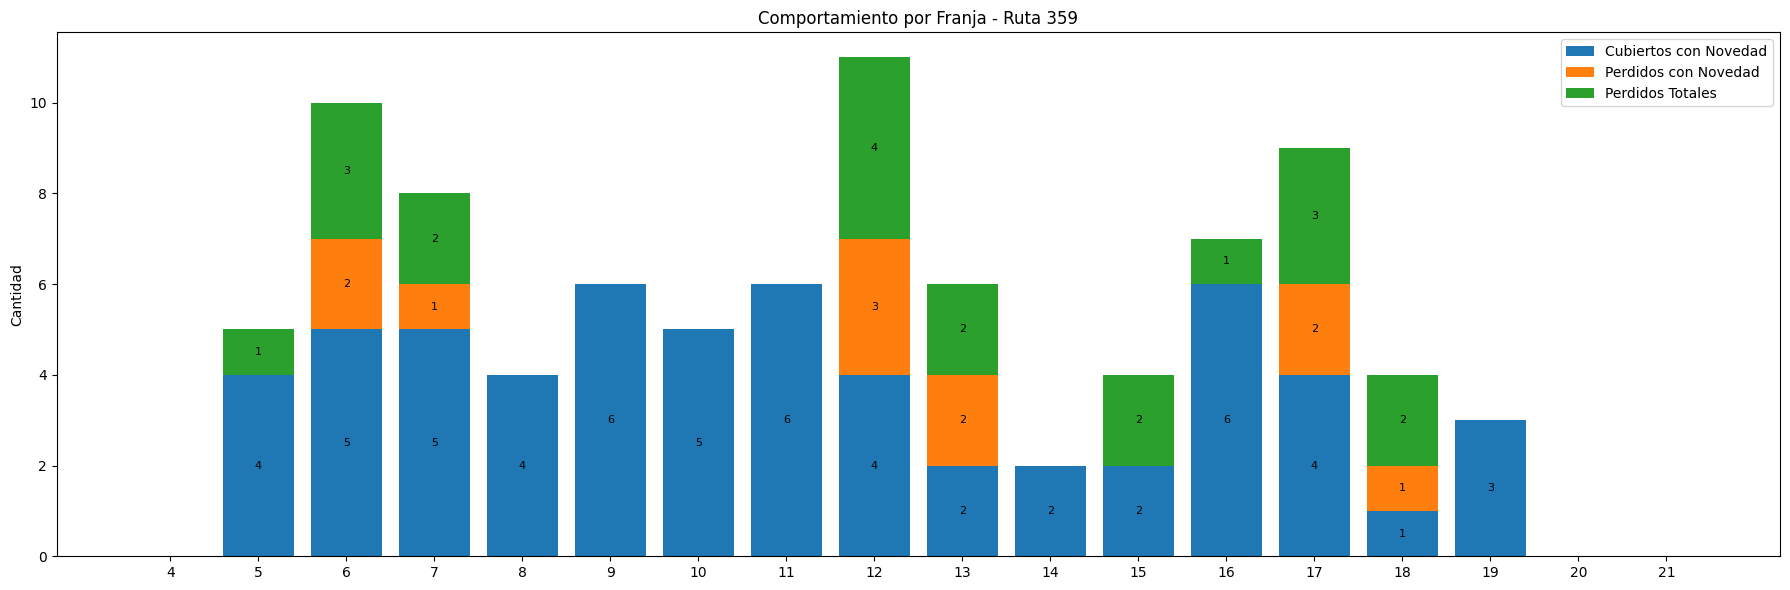

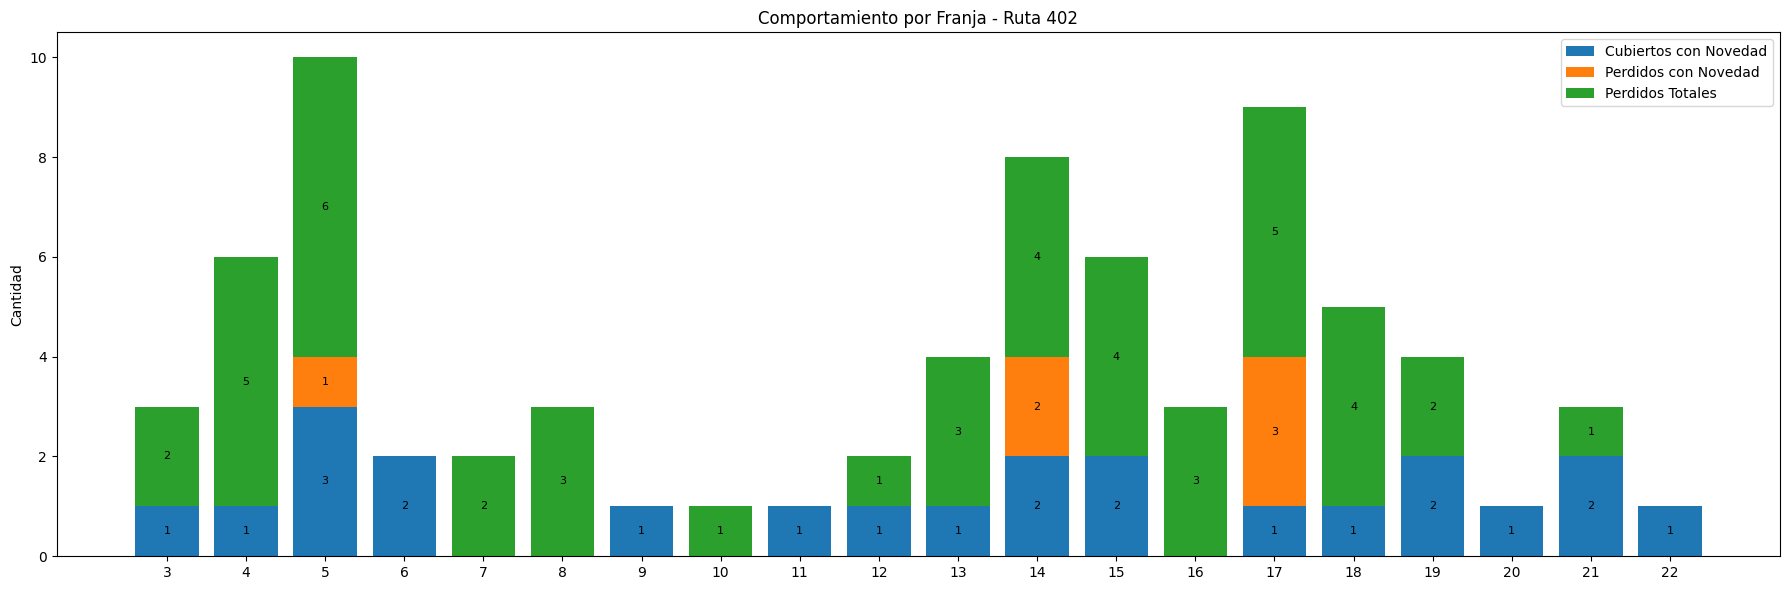

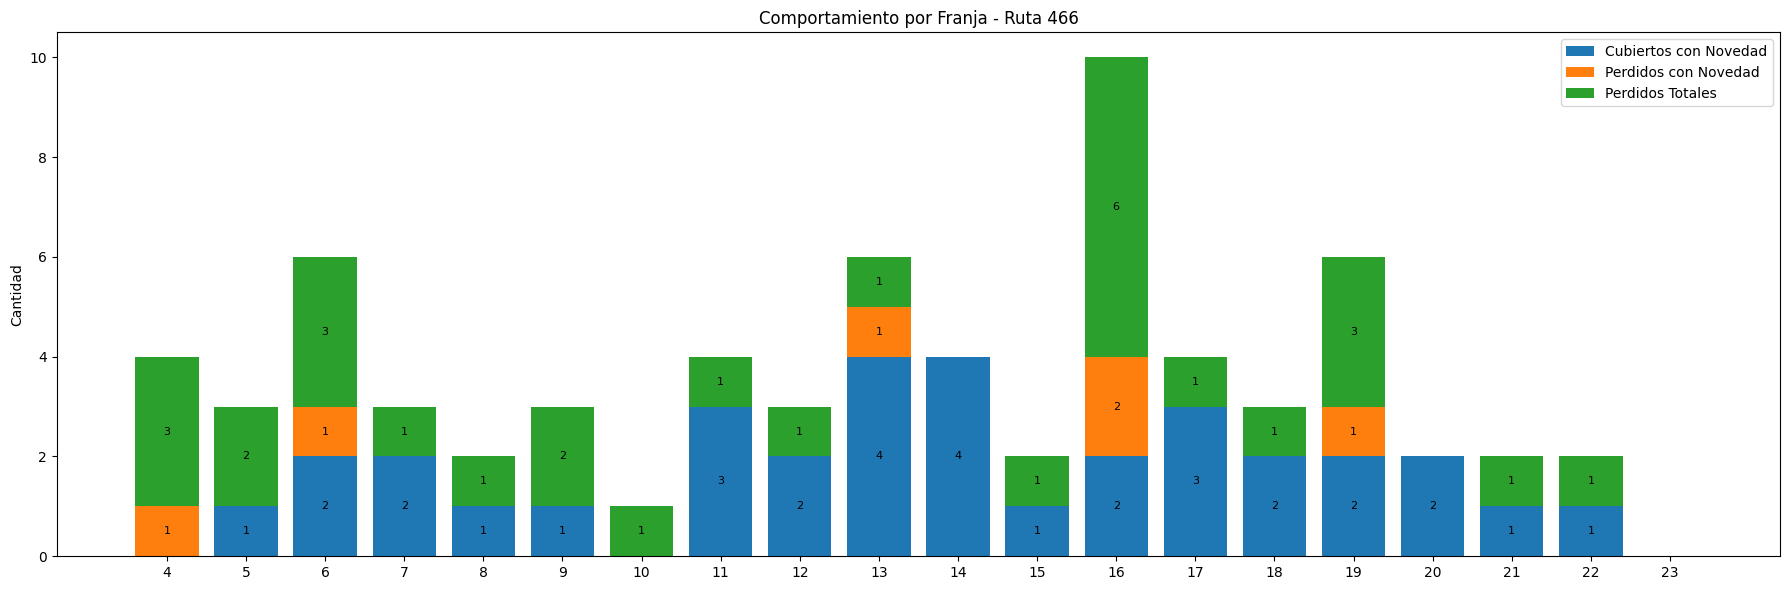

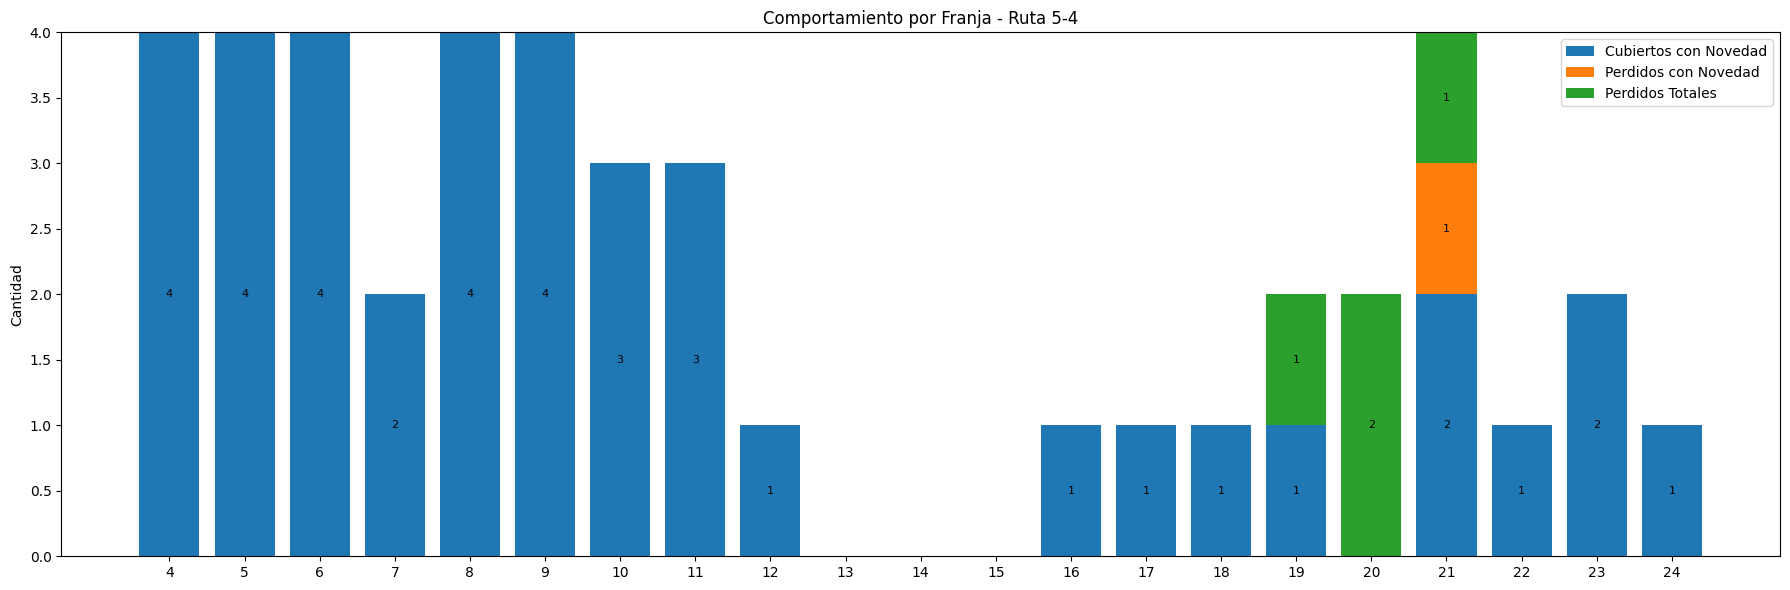

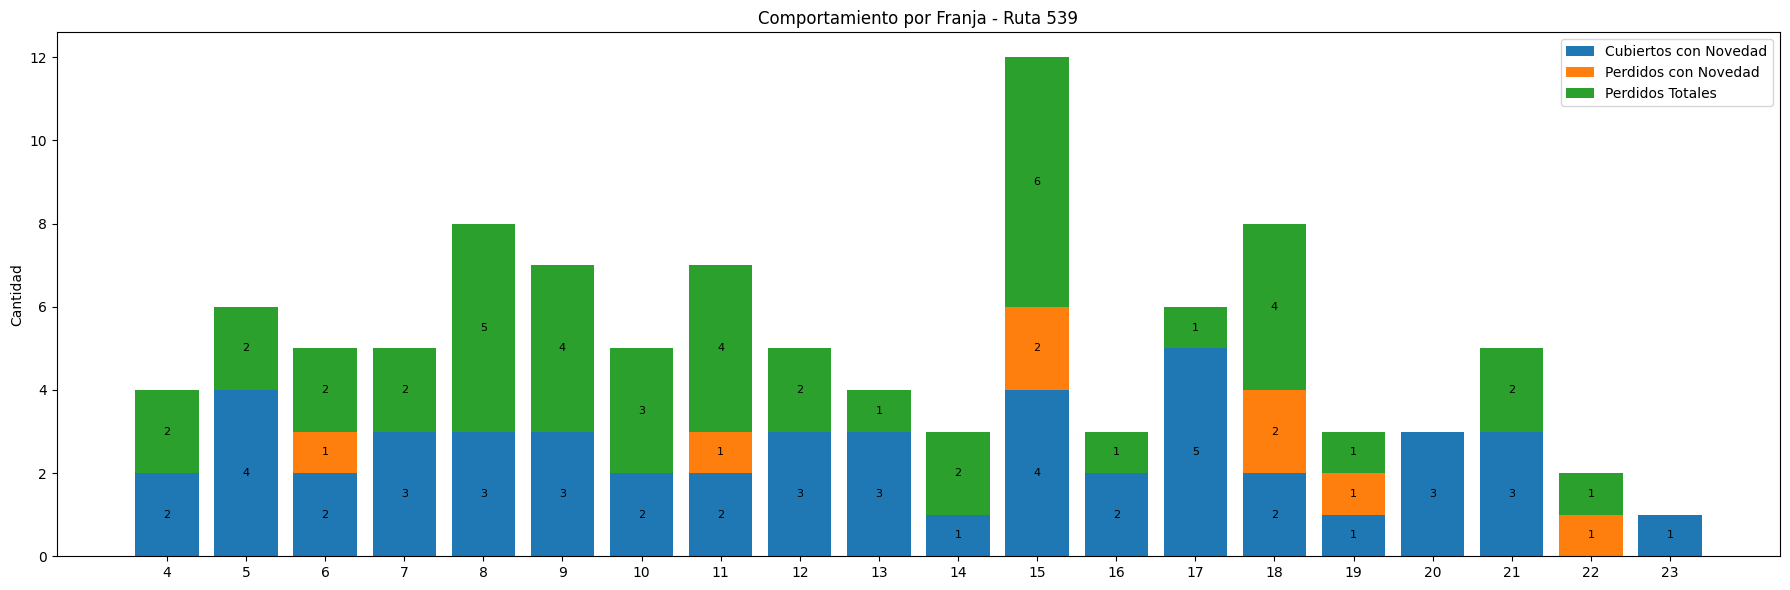

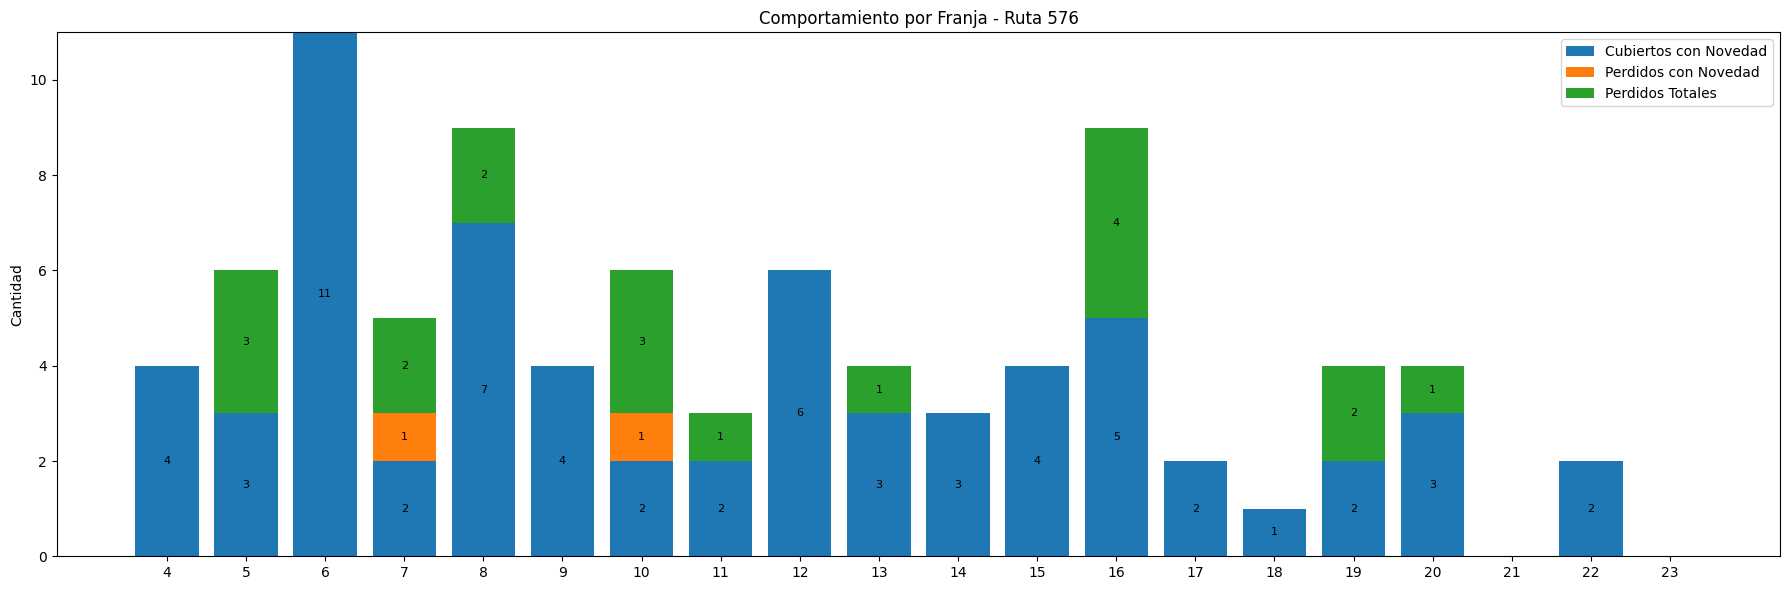

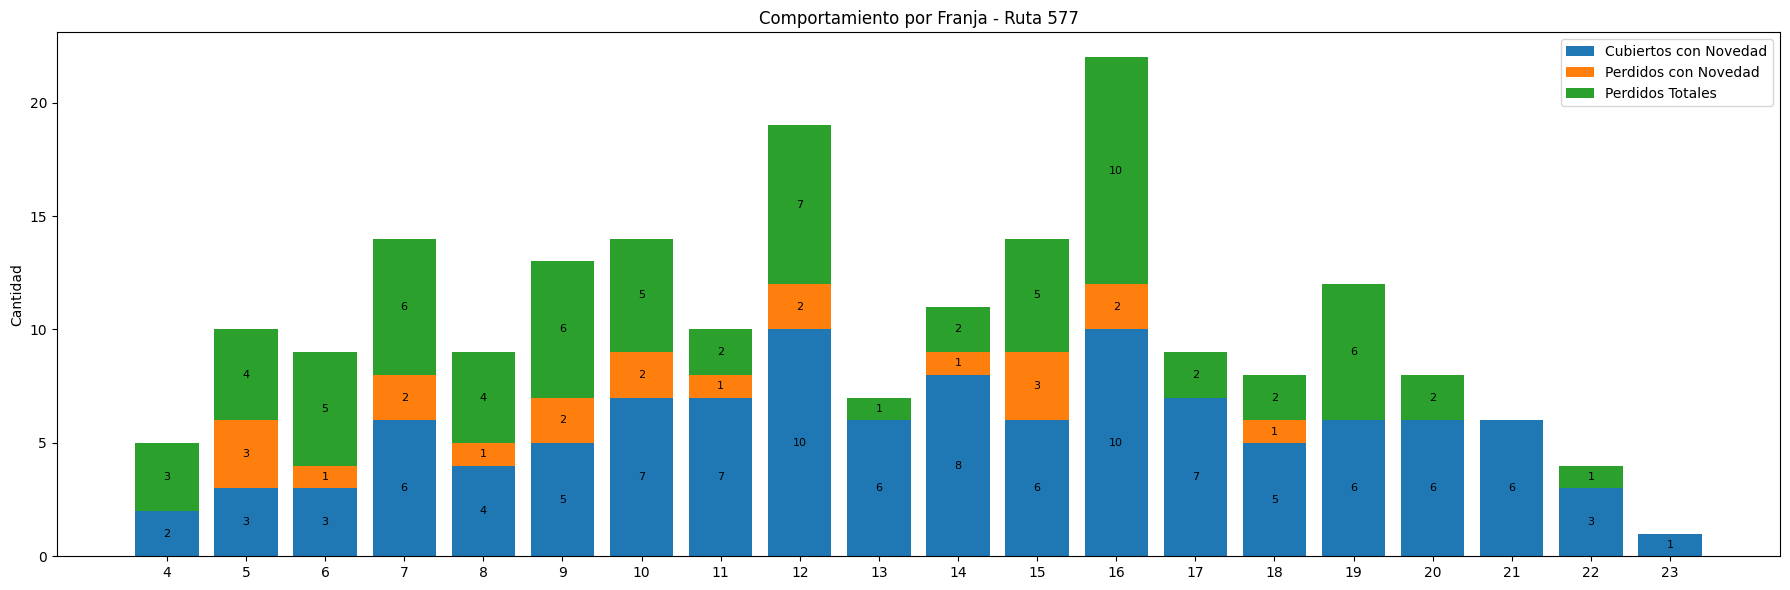

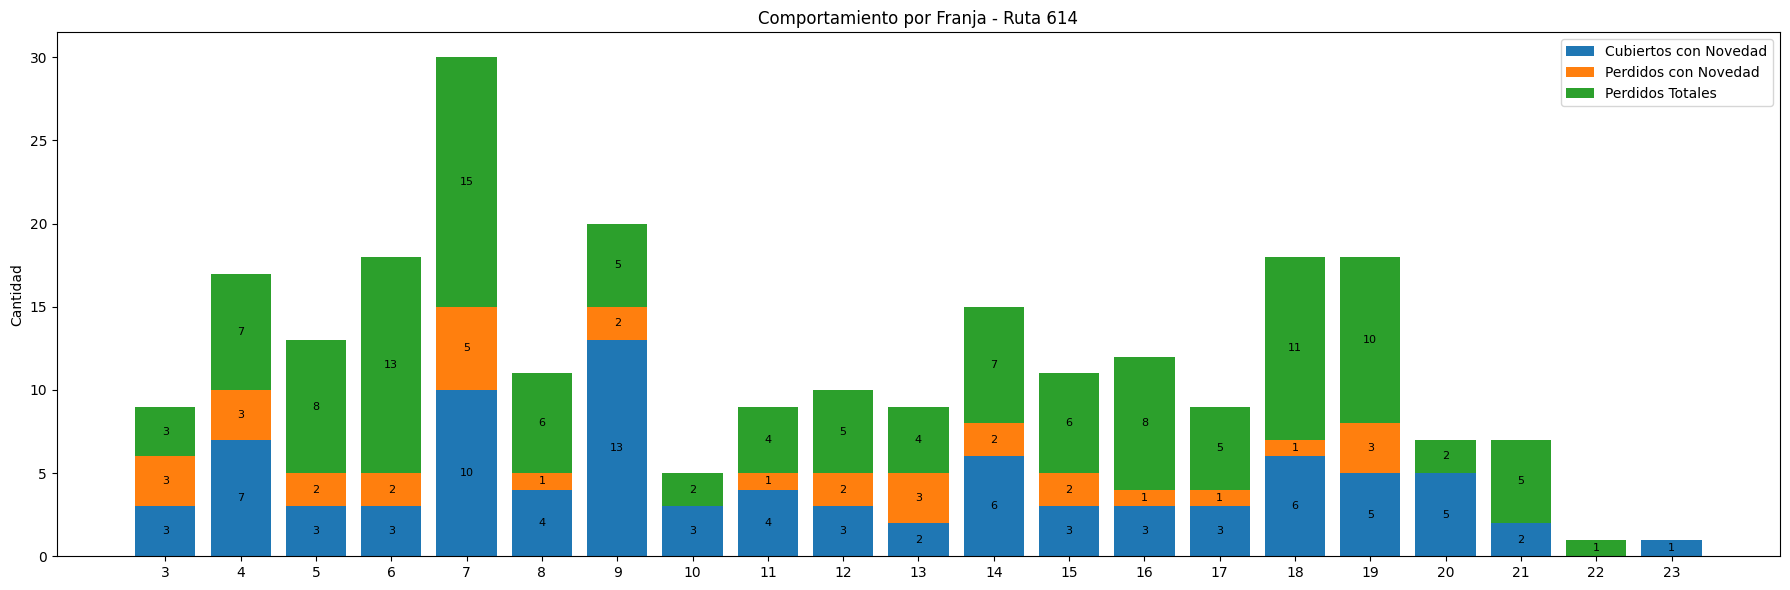

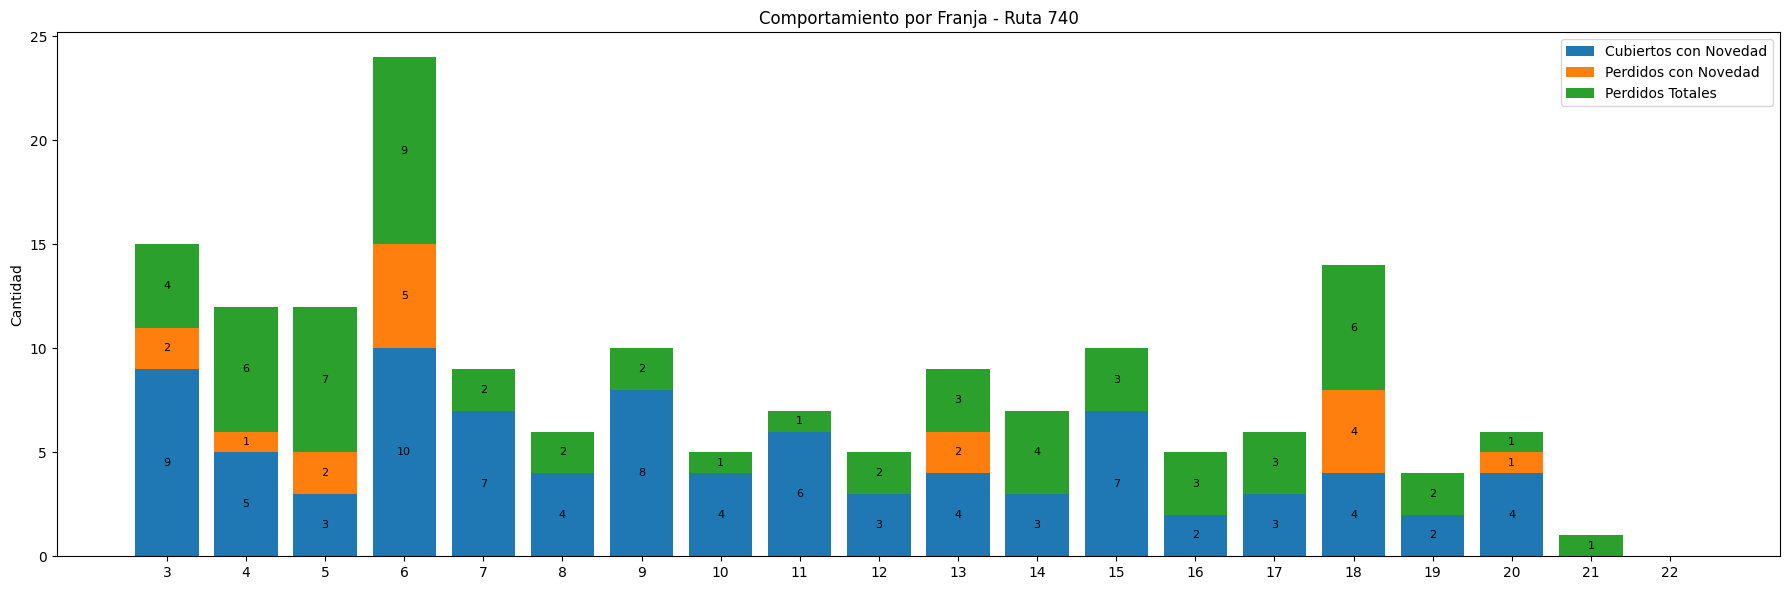

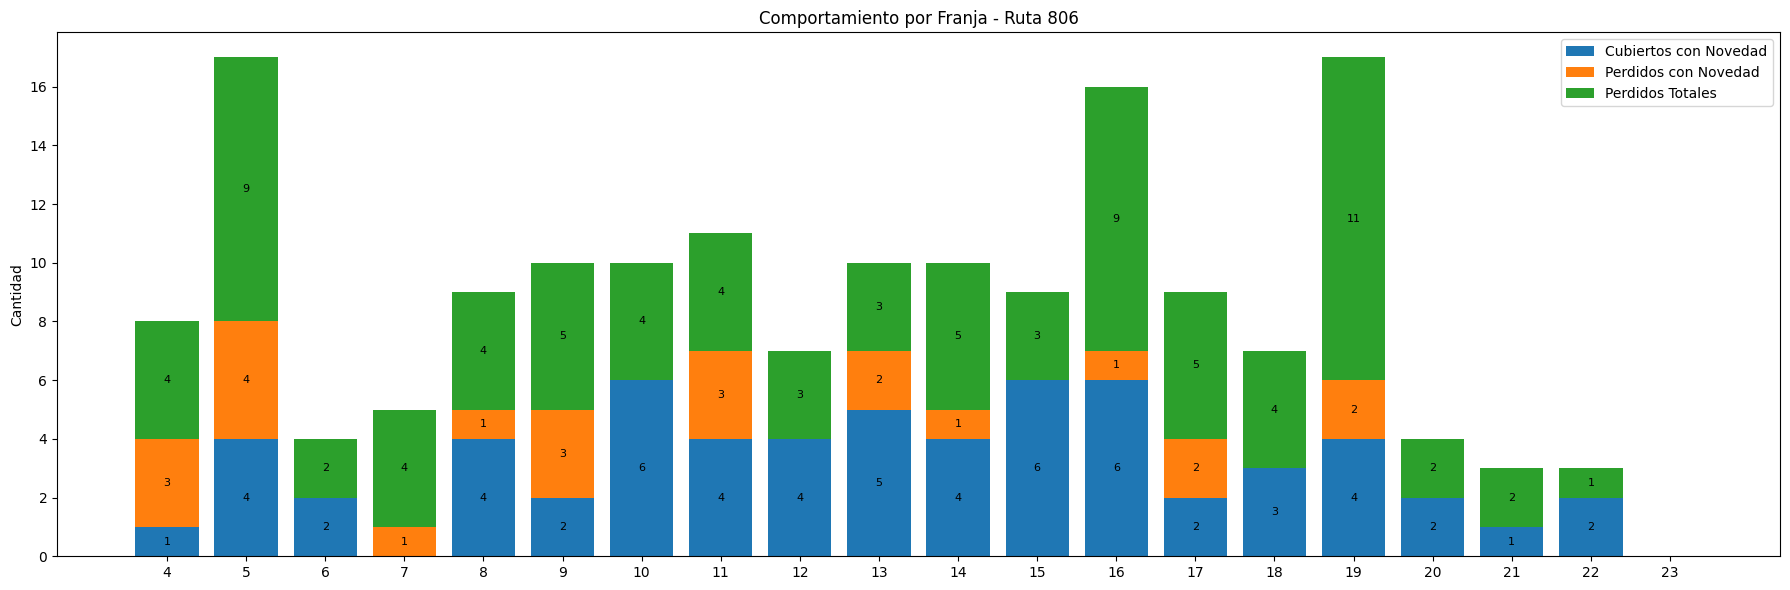

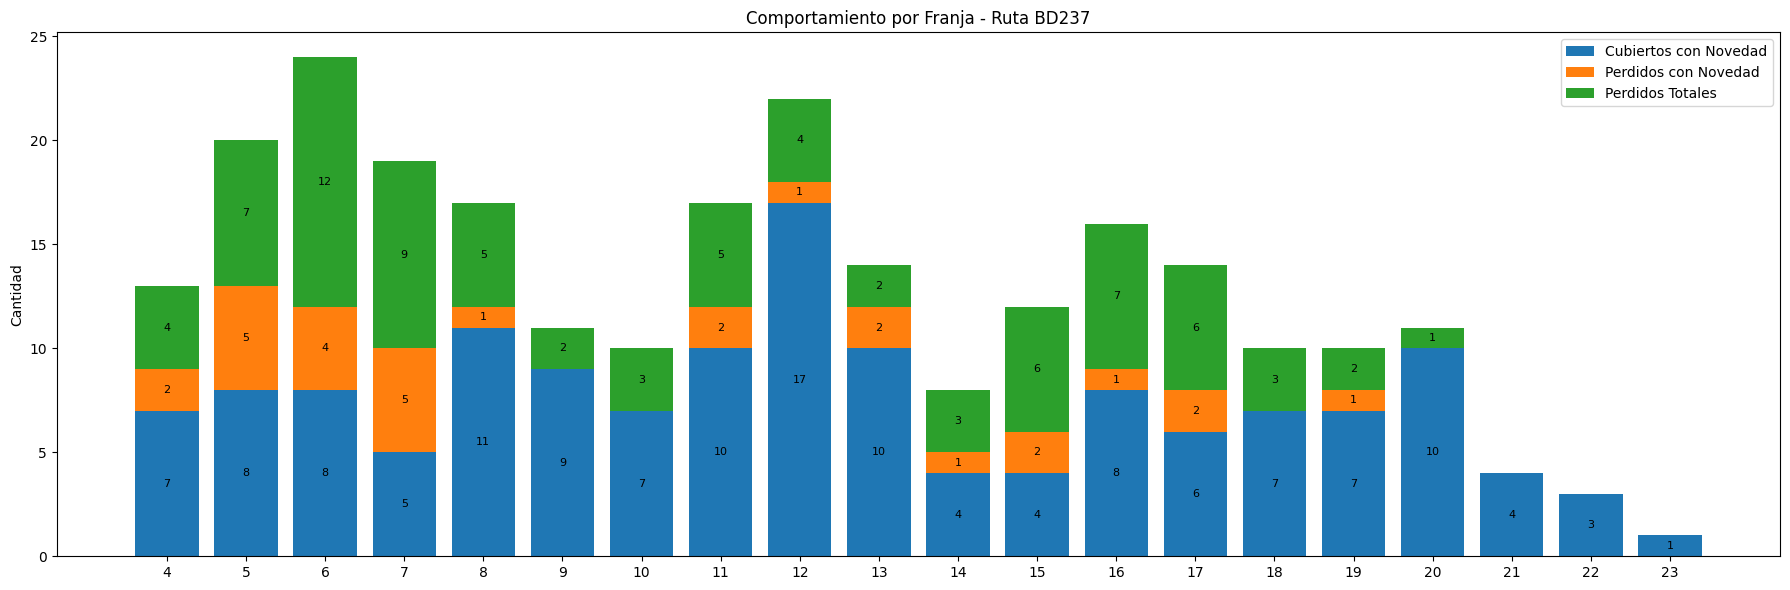

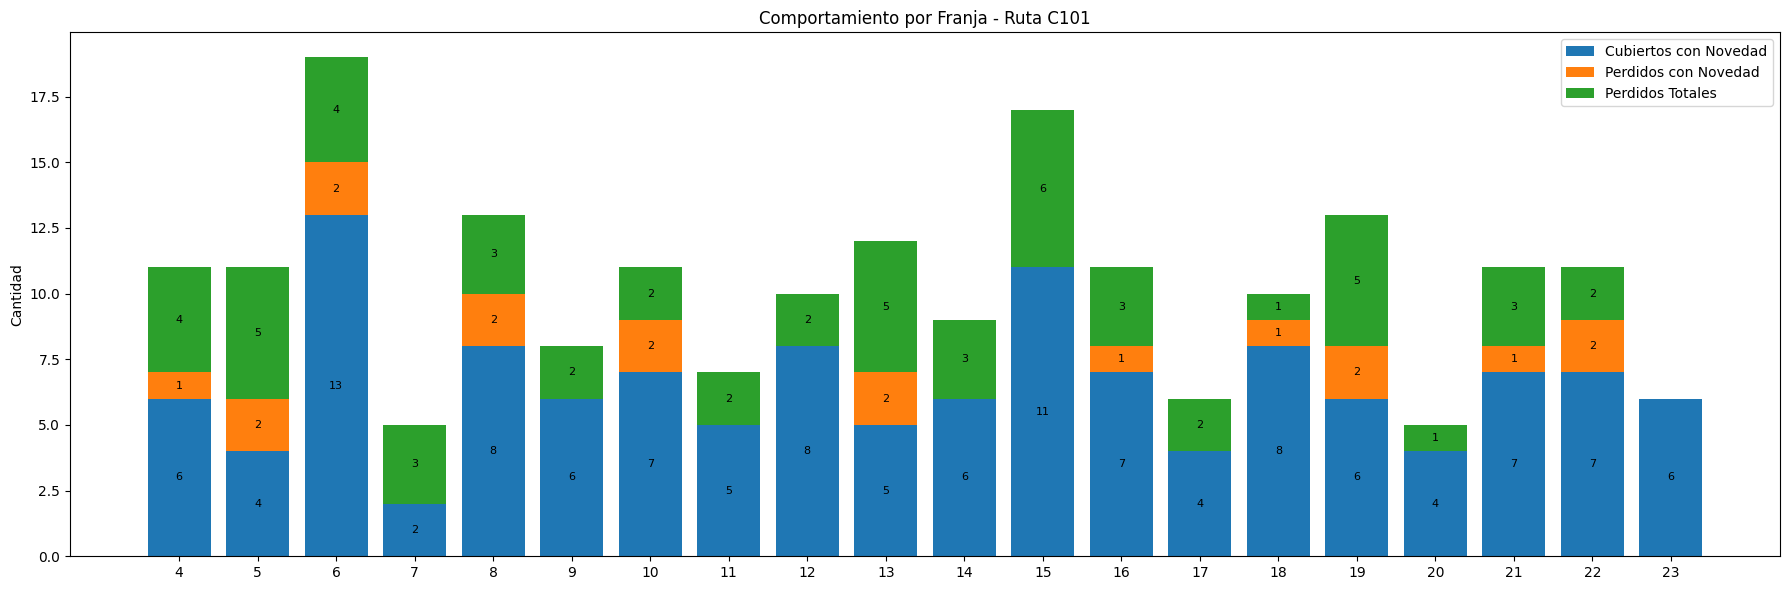

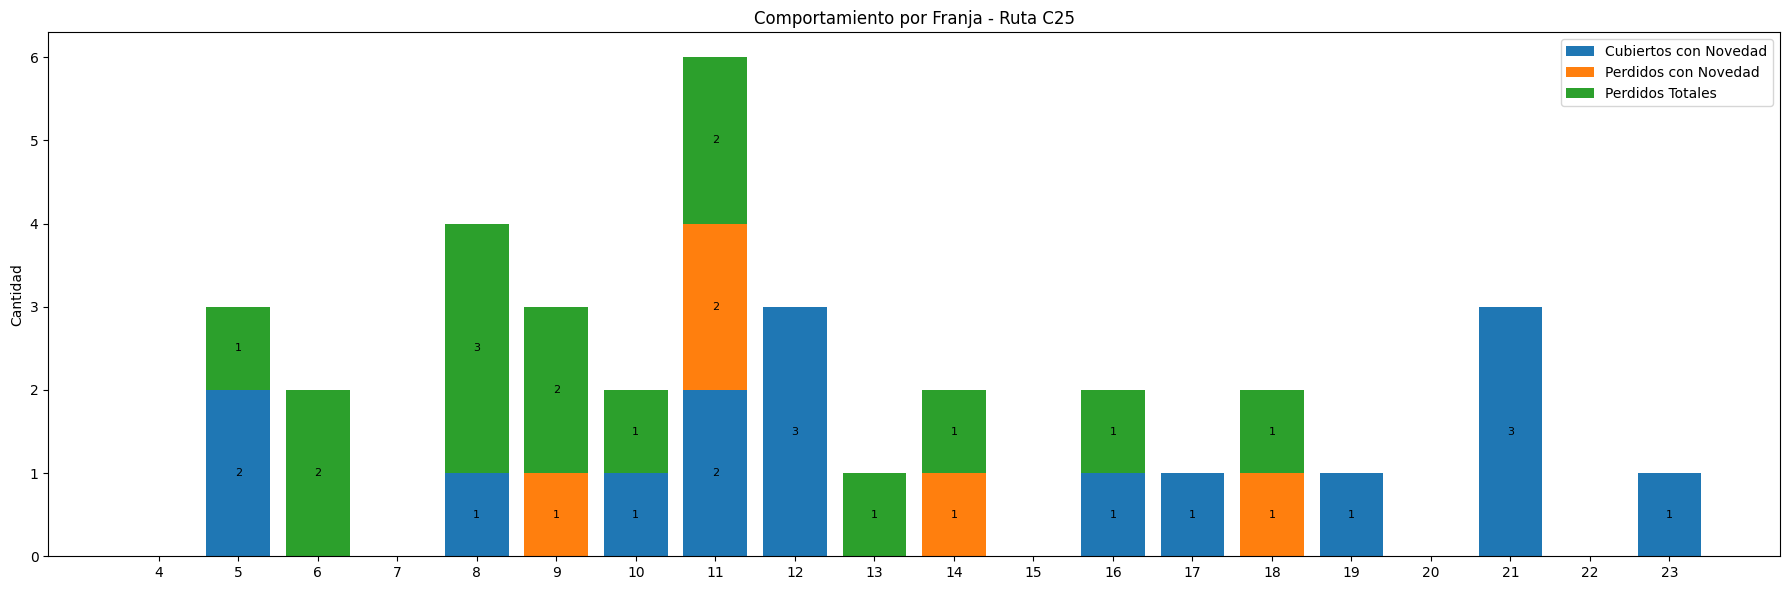

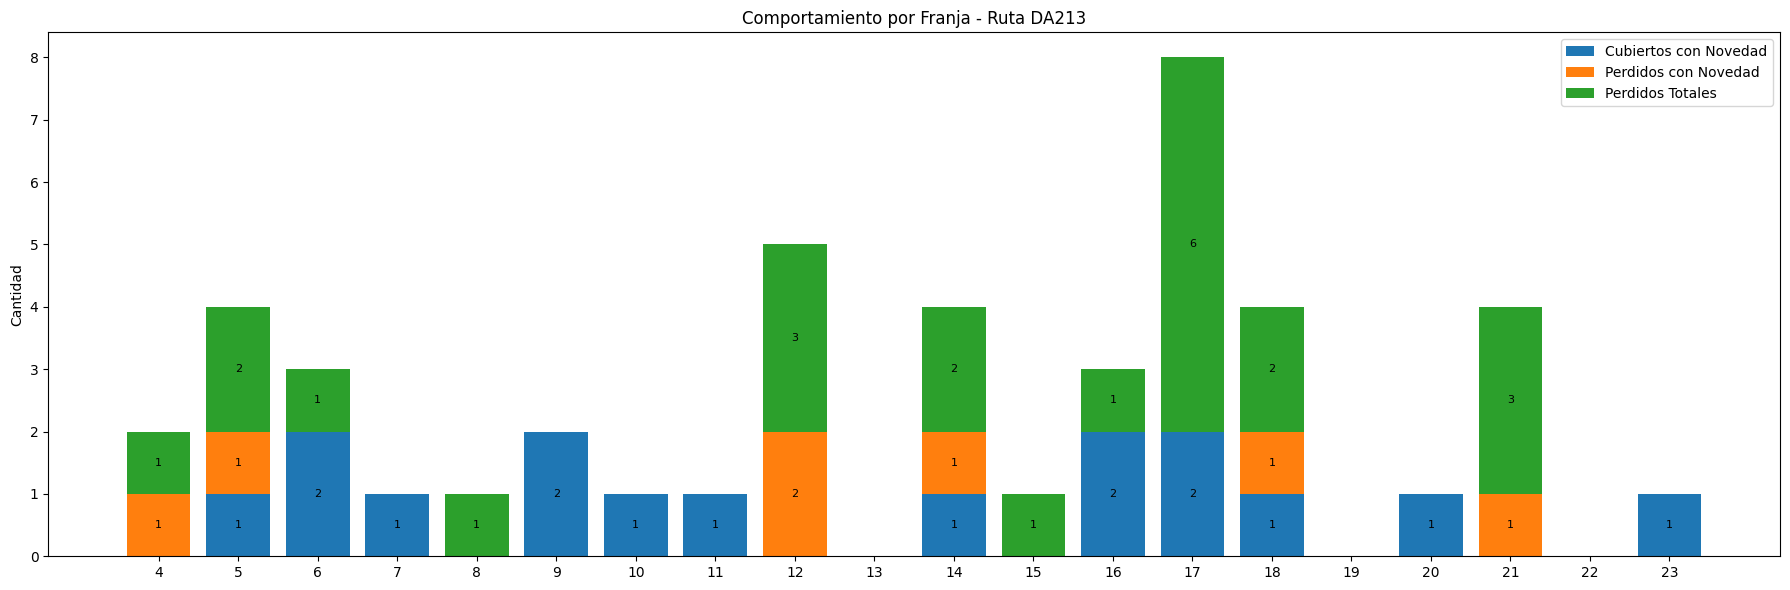

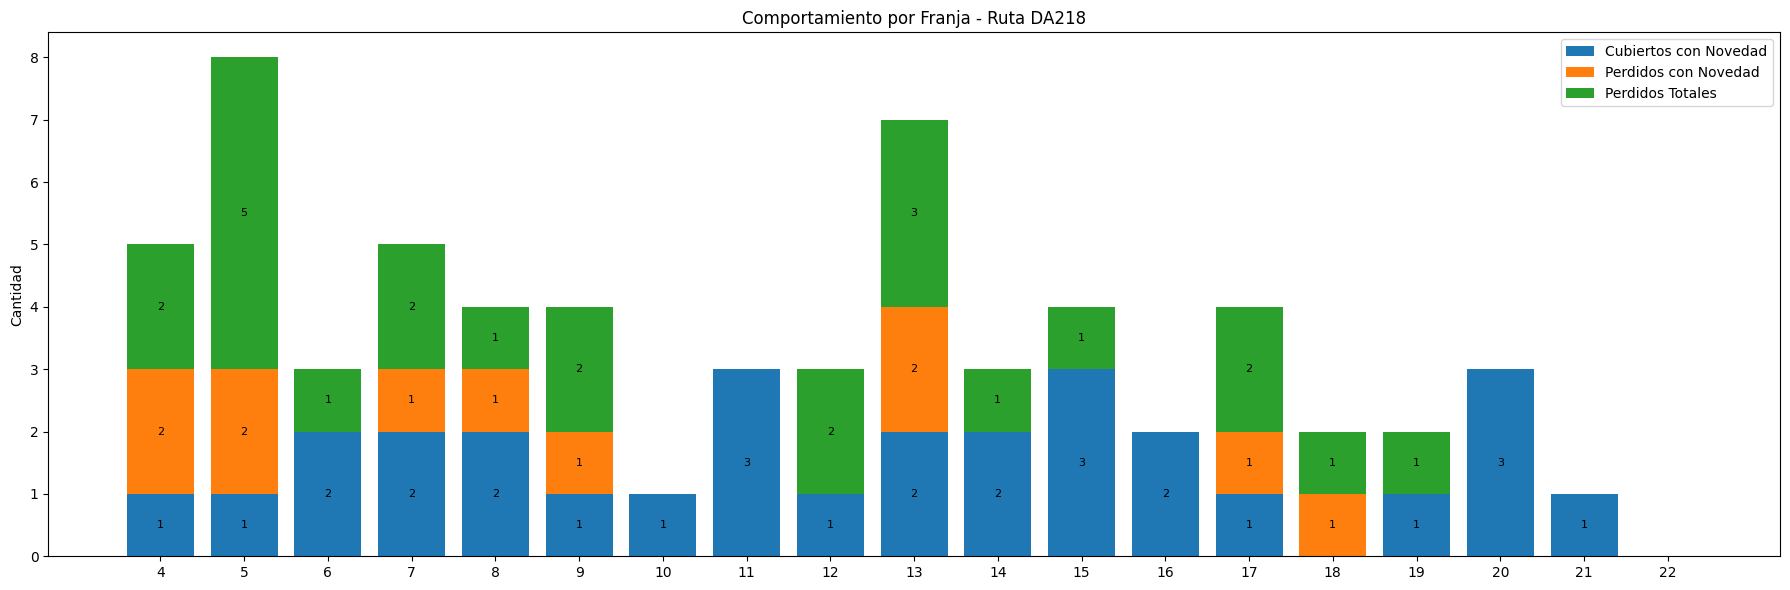

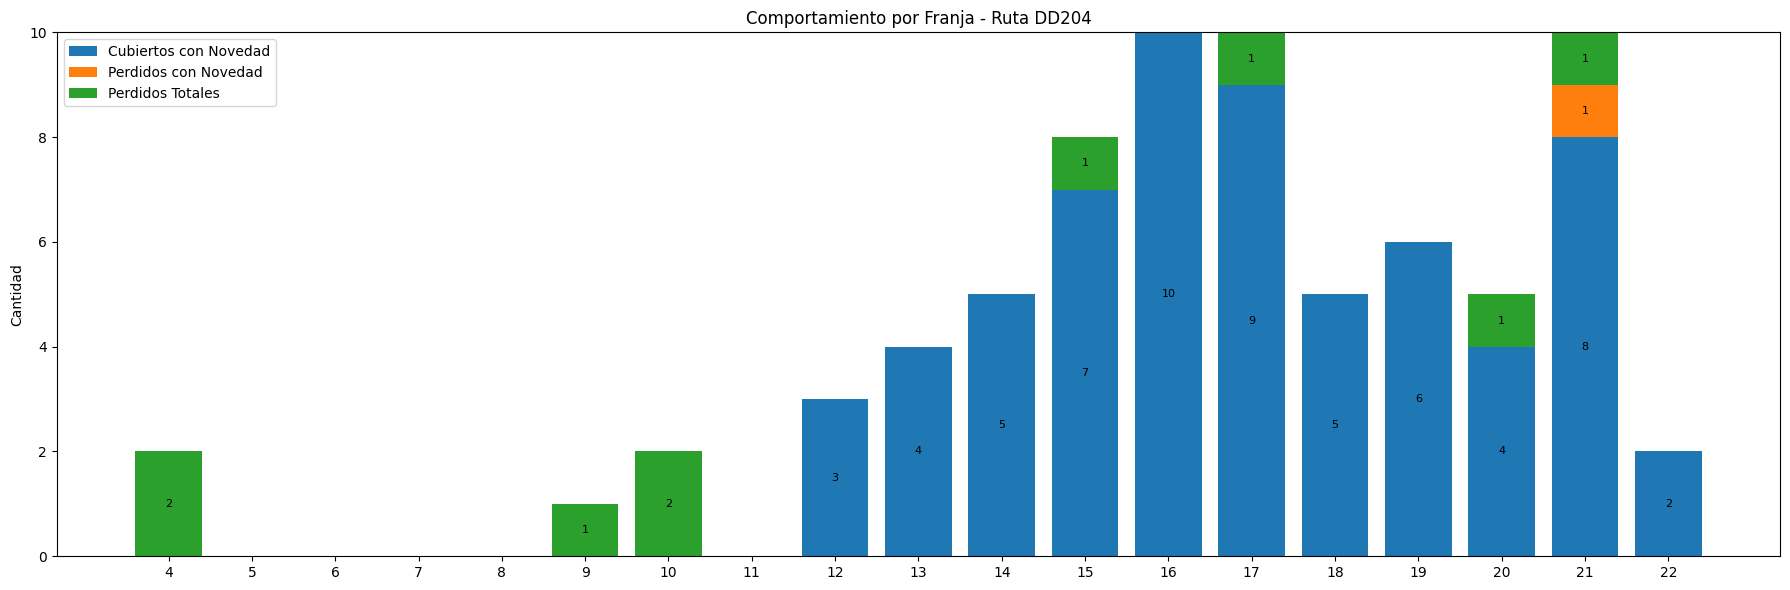

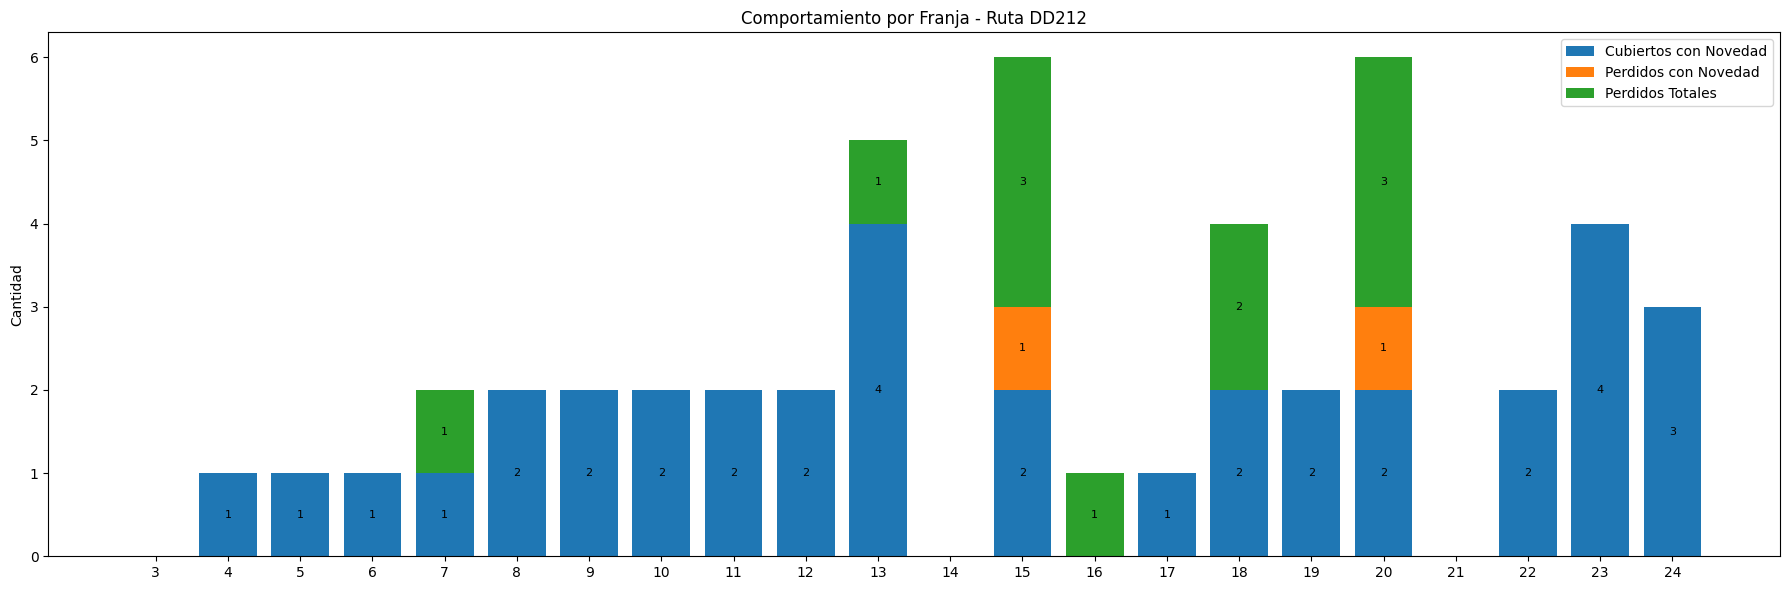

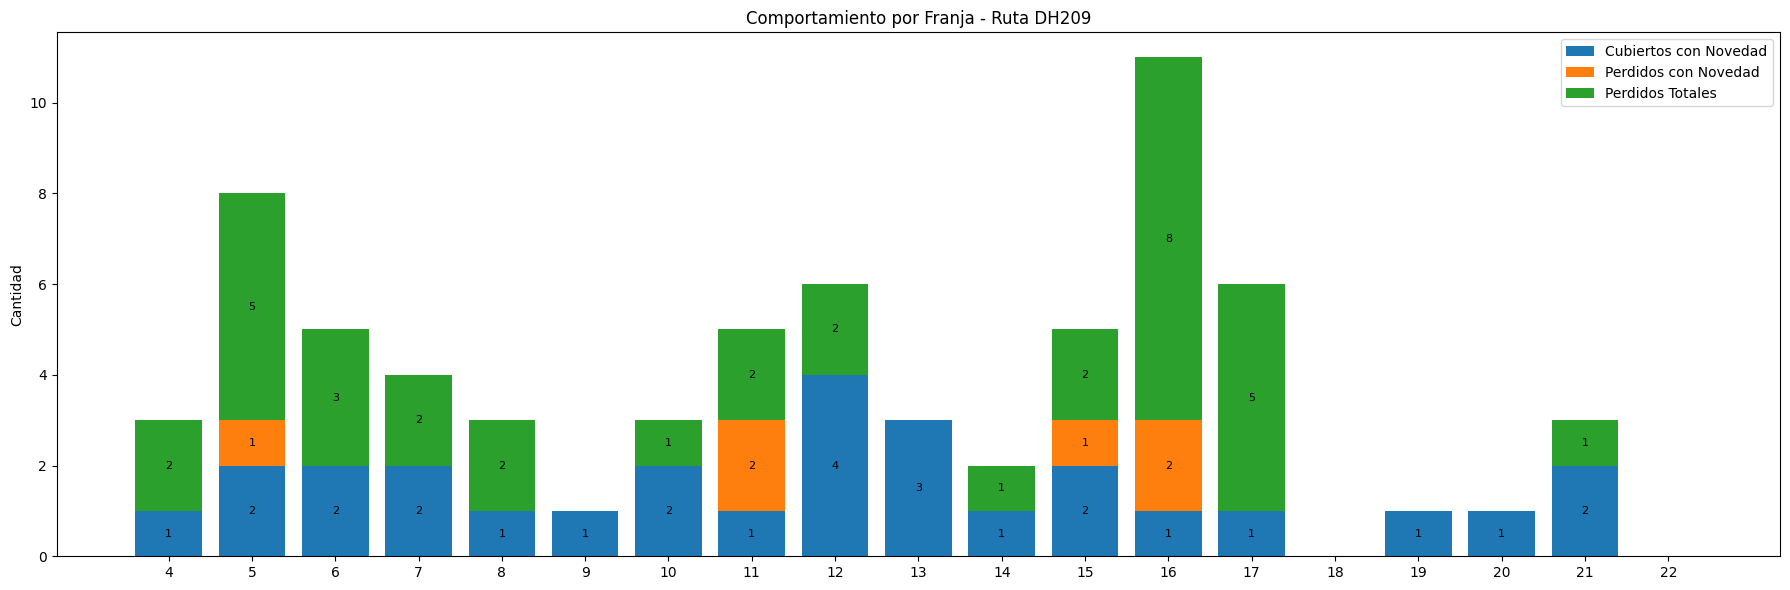

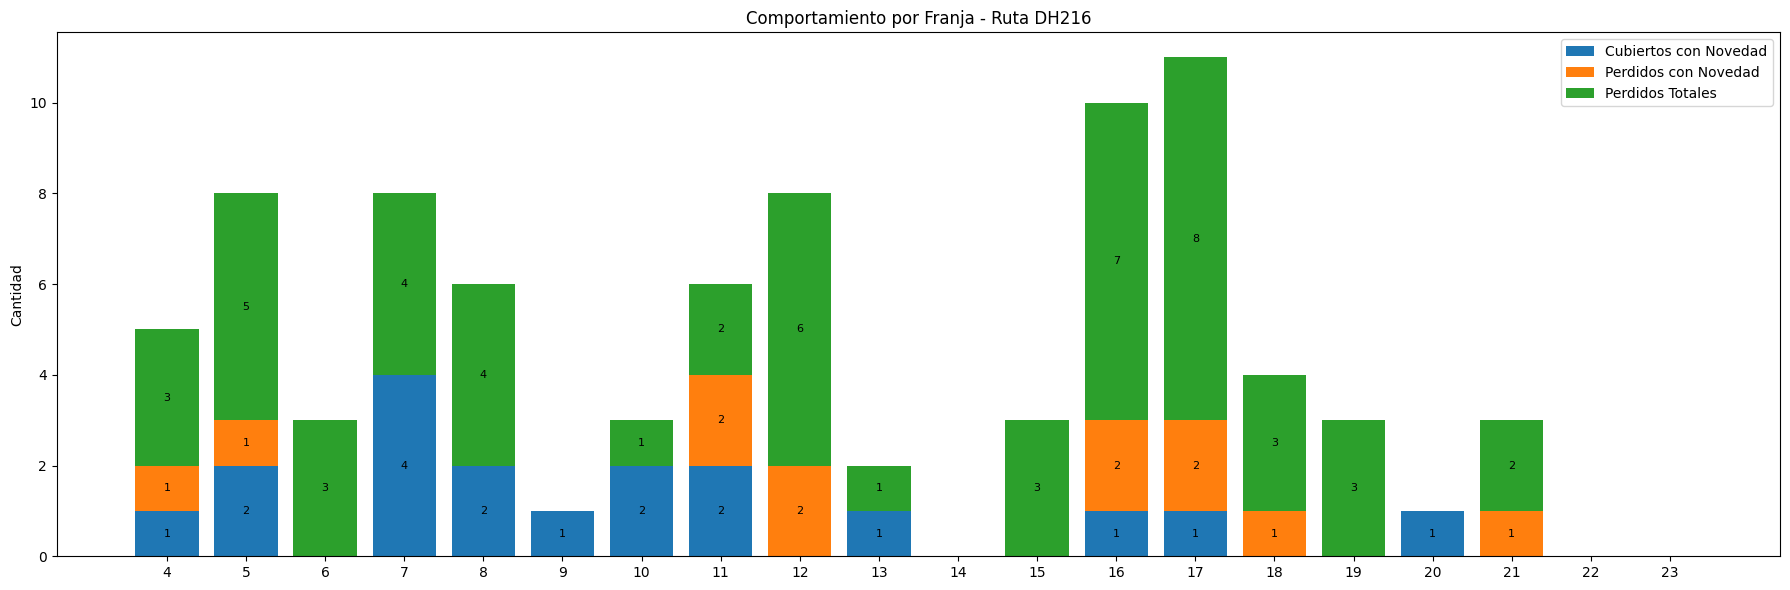

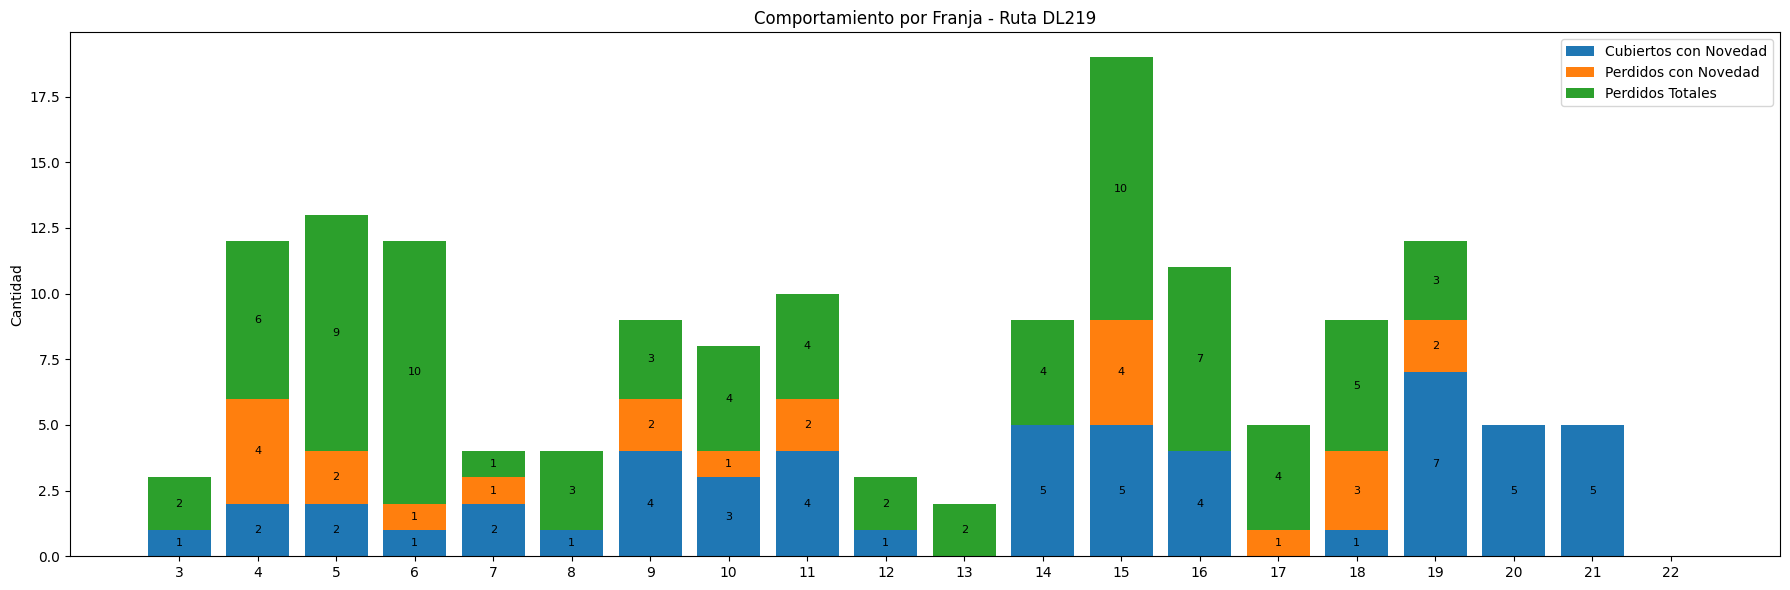

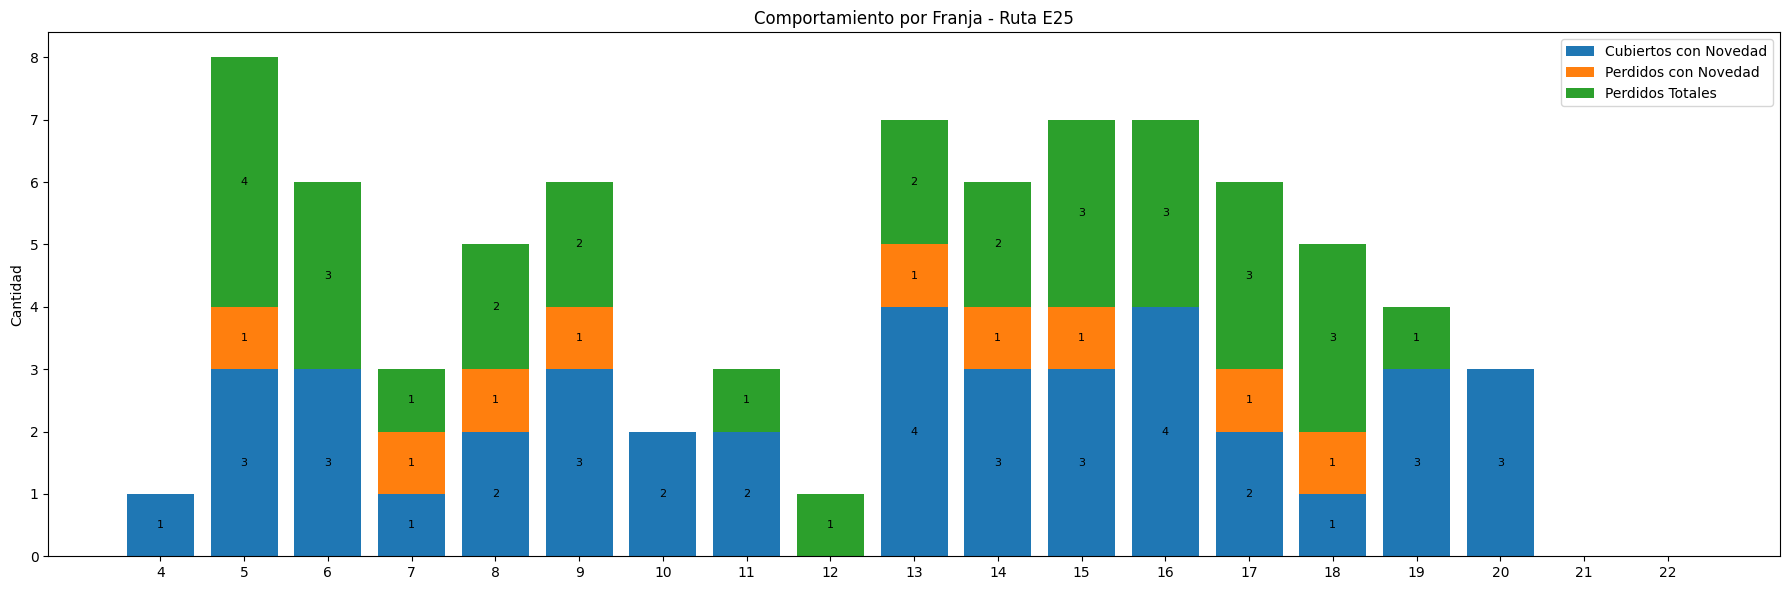

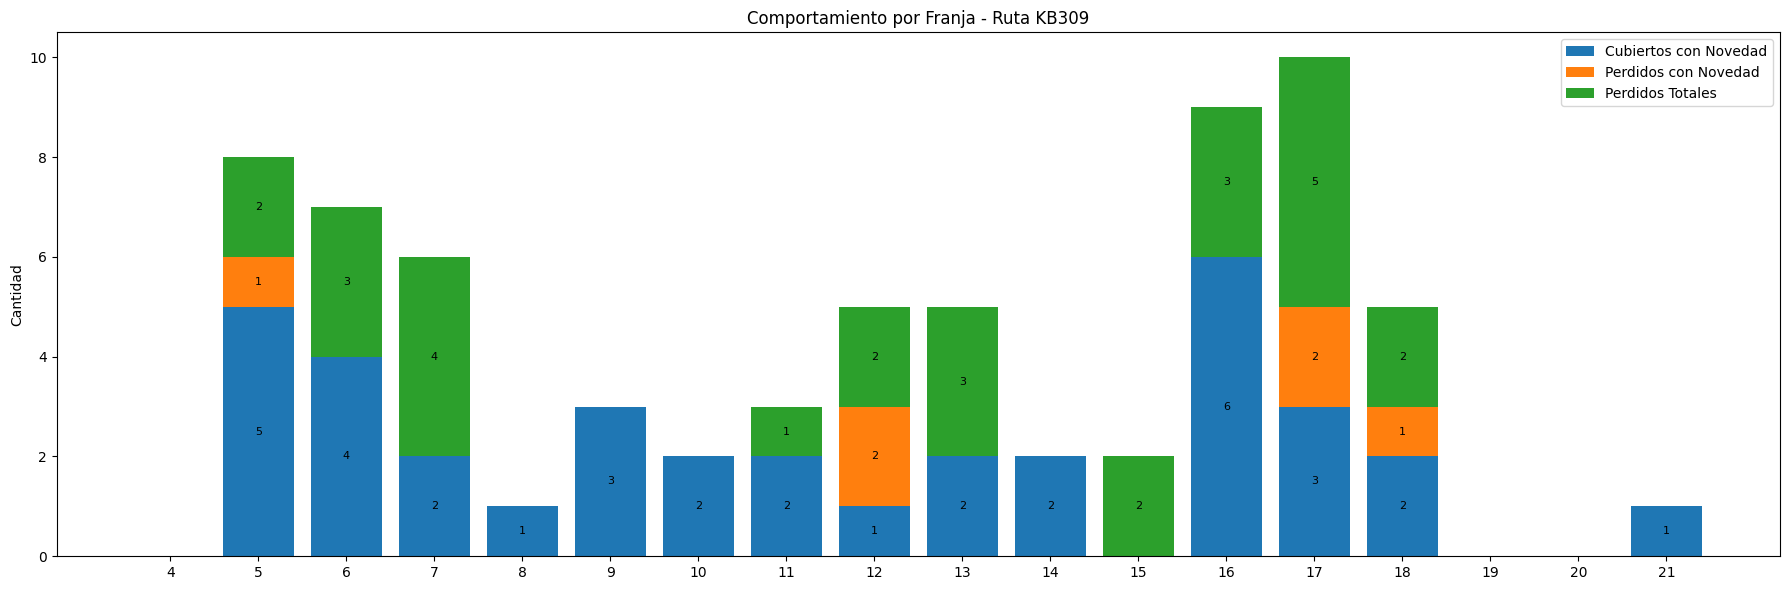

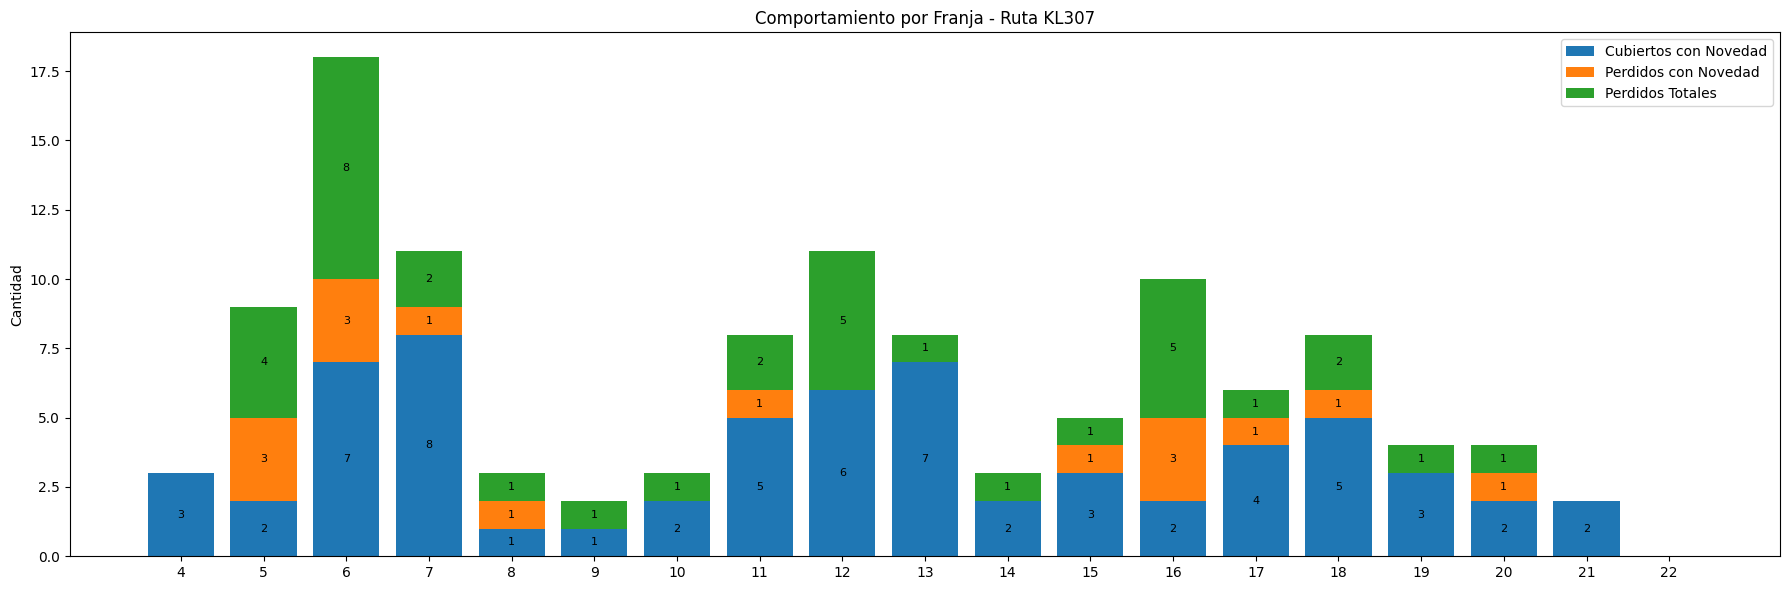

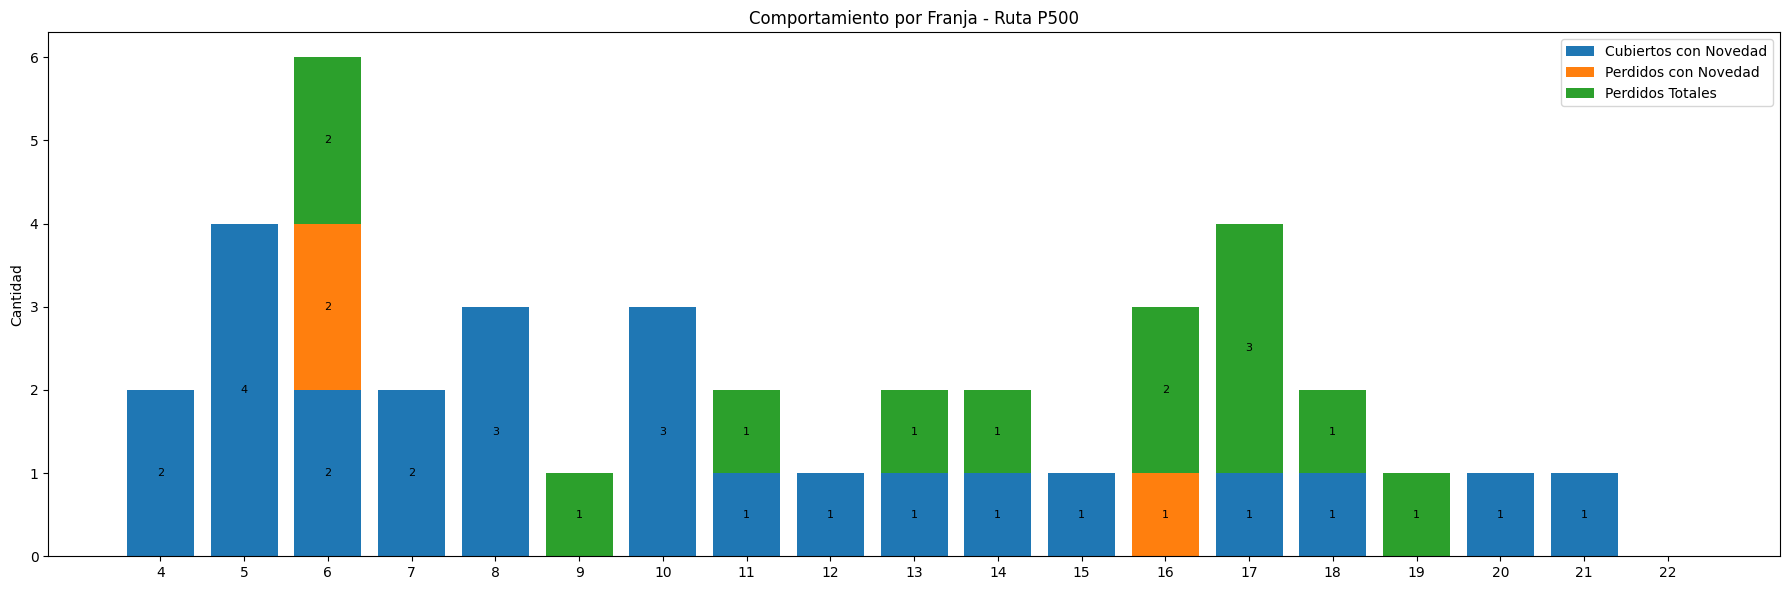

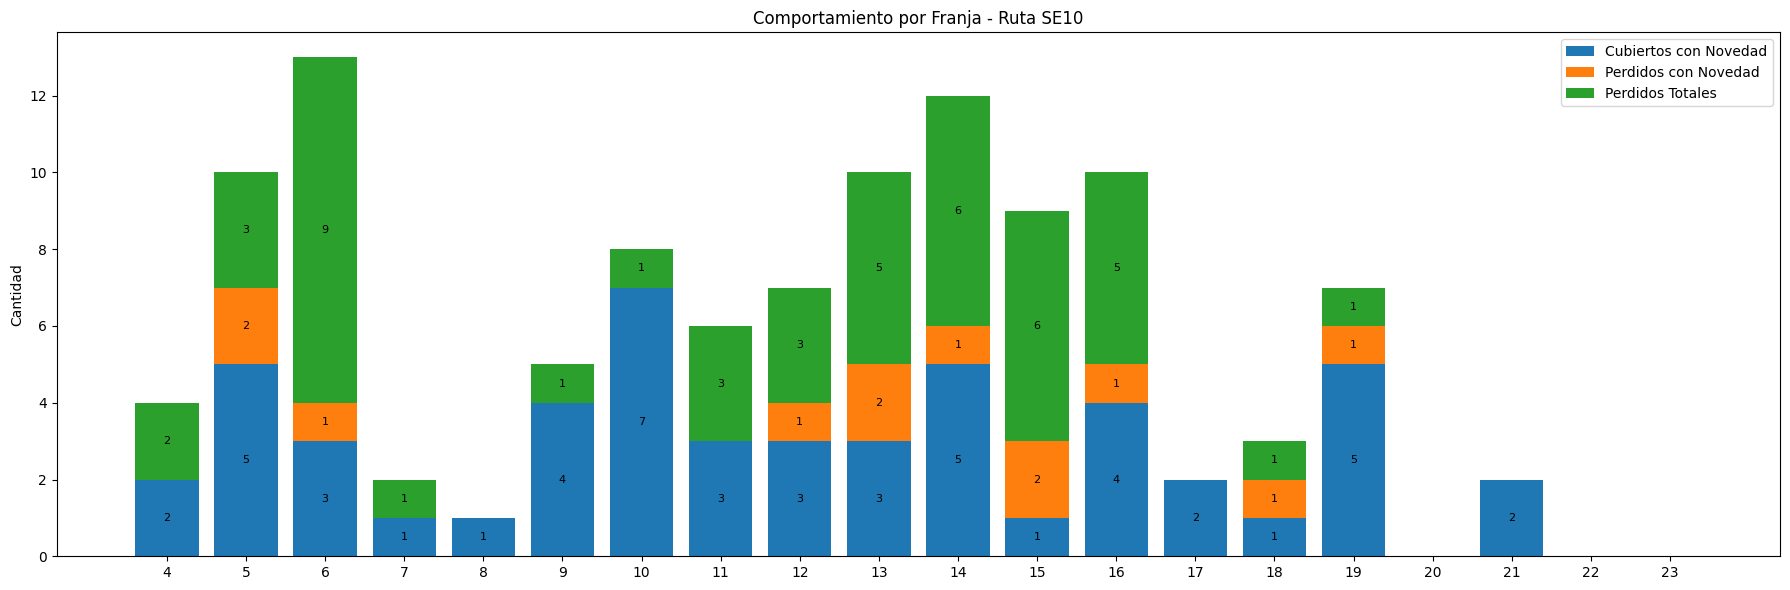

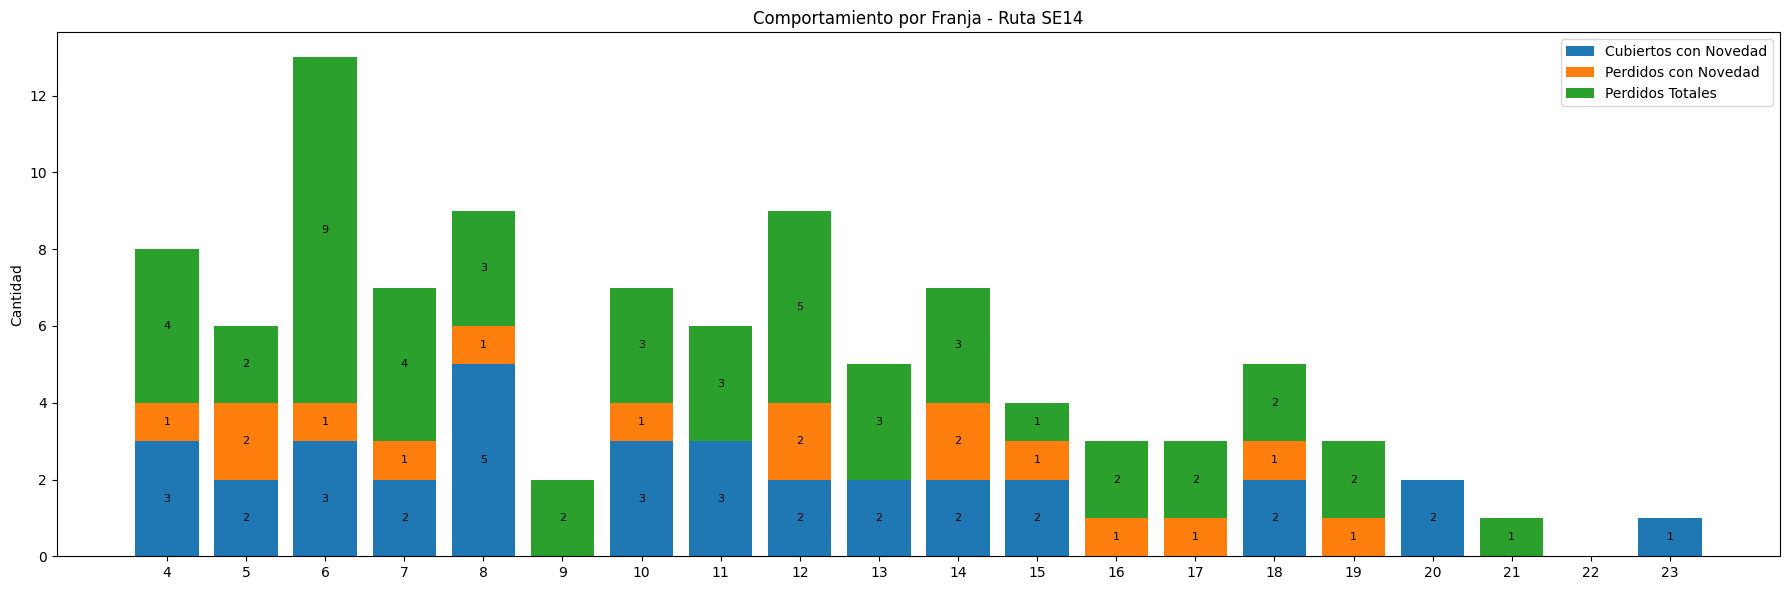

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar por Ruta y Franja (todas las fechas)
resumen_ruta_franja = (
    df_bitacora
    .groupby(["Ruta", "Franja"])
    .agg(
        cubiertos_con_novedad=("cubiertos_con_novedad", "sum"),
        perdidos_con_novedad=("perdidos_con_novedad", "sum"),
        perdidos_totales=("perdido_bin", "sum")
    )
    .reset_index()
)

# Obtener lista de rutas
rutas = resumen_ruta_franja["Ruta"].unique()

for ruta in rutas:
    
    df_plot = (
        resumen_ruta_franja[
            resumen_ruta_franja["Ruta"] == ruta
        ]
        .sort_values("Franja")
    )
    
    x = np.arange(len(df_plot))
    
    c1 = df_plot["cubiertos_con_novedad"].values
    c2 = df_plot["perdidos_con_novedad"].values
    c3 = df_plot["perdidos_totales"].values
    
    plt.figure(figsize=(18,6))
    
    # Columnas apiladas
    plt.bar(x, c1, label="Cubiertos con Novedad")
    plt.bar(x, c2, bottom=c1, label="Perdidos con Novedad")
    plt.bar(x, c3, bottom=c1+c2, label="Perdidos Totales")
    
    # Etiquetas
    for i in range(len(x)):
        if c1[i] > 0:
            plt.text(i, c1[i]/2, str(int(c1[i])), ha='center', va='center', fontsize=8)
        if c2[i] > 0:
            plt.text(i, c1[i] + c2[i]/2, str(int(c2[i])), ha='center', va='center', fontsize=8)
        if c3[i] > 0:
            plt.text(i, c1[i] + c2[i] + c3[i]/2, str(int(c3[i])), ha='center', va='center', fontsize=8)
    
    plt.xticks(x, df_plot["Franja"])
    plt.title(f"Comportamiento por Franja - Ruta {ruta}")
    plt.ylabel("Cantidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [94]:
bitacora.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/reporte_bitácora_perdidos_general.csv', sep=';', index=False)

In [95]:
analisis_base.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/reporte_perdidos_base_general.csv', sep=';', index=False)

In [96]:
analisis_final.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/reporte_perdidos_final.csv', sep=';', index=False)

In [97]:

patron_completo.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/reporte_perdidos_patrones.csv', sep=';', index=False)

In [98]:
resumen_fecha_ruta.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_perdidos/reporte_perdidos_patrones_rutas.csv', sep=';', index=False)